# Imports

In [2]:
import os
import copy
import warnings
import itertools
import datetime as dt
import pandas as pd
import numpy as np
import random # Usado para random.sample e random.shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from scipy.stats import norm, skew, kurtosis, truncnorm # Importar diretamente as funções
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.optimize import curve_fit
from statsmodels.graphics.gofplots import qqplot
from multiprocessing import Pool
import random
import traceback # Importar para printar o traceback em caso de erro

# Importar nas classes quando usar função standalone

warnings.filterwarnings("ignore")

In [3]:
!git clone https://github.com/gilbertogilfgp/Mercado-Artificial-Fiis.git
%cd /content/Mercado-Artificial-Fiis

import sys
sys.path.append('/content/Mercado-Artificial-Fiis')

!pip install numpy pandas matplotlib scipy statsmodels yfinance seaborn

from src.simulacao import simular_mercado_e_plotar

Cloning into 'Mercado-Artificial-Fiis'...
remote: Enumerating objects: 199, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 199 (delta 1), reused 0 (delta 0), pack-reused 193 (from 2)
Receiving objects: 100% (199/199), 12.72 MiB | 6.30 MiB/s, done.
Resolving deltas: 100% (100/100), done.
Updating files: 100% (21/21), done.
/content/Mercado-Artificial-Fiis


In [4]:
from src.simulacao import simular_mercado_e_plotar, plotar_resultado, SIM_PARAMS

In [5]:
from src.agentes import Agente, gerar_literacia_financeira
from src.ativos import FII, Imovel
from src.mercado import Mercado, BancoCentral, Midia

In [6]:
parametros_sistema = pd.read_csv('/content/Mercado-Artificial-Fiis/notebooks/dados/parametros_sistema_calibrados.csv').to_numpy()[0]

parametros_sistema

array([0.84822756, 0.69540723, 0.87855894, 0.15595803, 0.07548527])

# OAFT - Parâmetros Calibráveis

## a0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Parâmetro : a0
θ*        : {'a0': np.float64(0.8482275571108211), 'b0': np.float64(0.695407231715014), 'c0': np.float64(0.8785589354774088), 'beta': np.float64(0.1559580296673415), 'peso': np.float64(0.0754852709451064)}
Grade     : 5 pontos × 10 réplicas = 50 sim.
Núcleos   : 2
Tempo est.: ~64 min = 1.1h
Outputs   : 11
Saída     : /content/drive/MyDrive/tese_fii/ofat_results2/ofat_a0.csv

✓ Baseline carregado (10 linhas)

Baseline (médias):
  media         : +0.000160
  variancia     : +0.000013
  assimetria    : +0.516043
  curtose       : +8.088465
  acf_lag5      : +0.110780
  acf_lag10     : +0.102715
  acf_lag15     : -0.072397
  acf_lag20     : +0.032951
  acf2_lag1     : +0.633324
  acf2_lag2     : +0.429923
  power_law_b   : +0.527387

Retomando: 5 pontos já concluídos
Pontos pendentes: 0/5


✓ Parâmetro a0 concluído


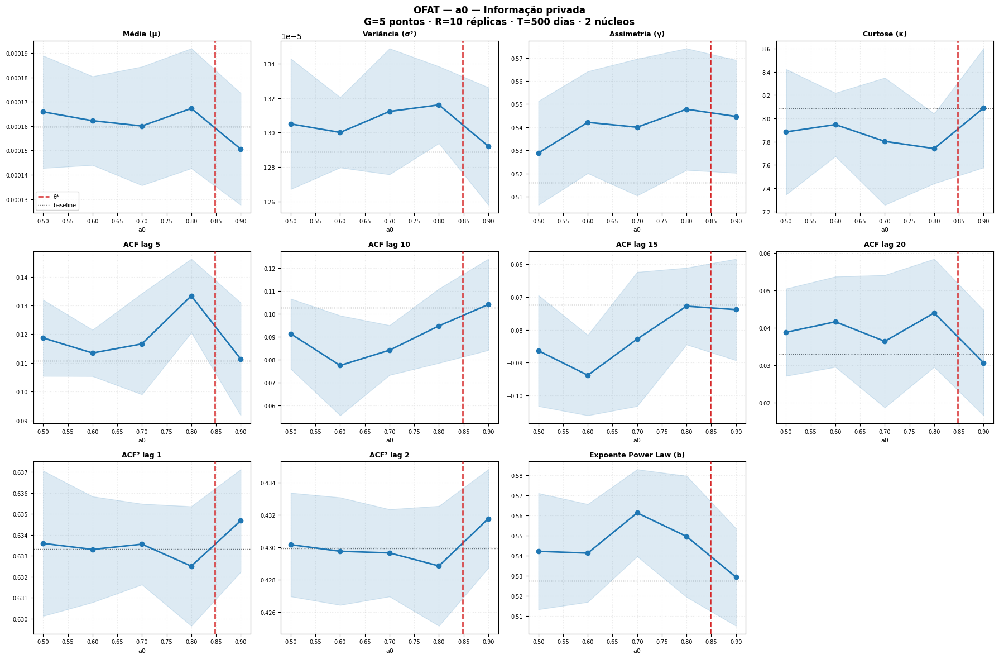

✓ Figura salva: /content/drive/MyDrive/tese_fii/ofat_results2/figures/ofat_a0.png

Δ_rel para a0:
  Output              Δ (%)       ρ  Direção
  --------------------------------------------------
  media                10.4%  -0.400  nao-monotonica
  variancia             1.9%  -0.100  nao-monotonica
  assimetria            3.7%  +0.800  nao-monotonica
  curtose               4.3%  +0.100  nao-monotonica
  acf_lag5             19.9%  -0.300  nao-monotonica
  acf_lag10            25.9%  +0.700  nao-monotonica
  acf_lag15            29.0%  +0.800  nao-monotonica
  acf_lag20            40.4%  -0.300  nao-monotonica
  acf2_lag1             0.3%  +0.100  nao-monotonica
  acf2_lag2             0.7%  +0.000  nao-monotonica
  power_law_b           6.0%  -0.200  nao-monotonica

── Status geral ──────────────────────────
  a0      ✓ 5/5 pontos  ◄ atual
  b0      ✓ 5/5 pontos  
  c0      ✓ 5/5 pontos  
  beta    ✓ 5/5 pontos  
  peso    ✓ 5/5 pontos  
──────────────────────────────────────────

P

In [7]:
# ══════════════════════════════════════════════════════════════
# OFAT — UM PARÂMETRO POR VEZ (joblib paralelo)
# Versão final com todos os outputs e θ* atualizado
#
# INSTRUÇÕES:
#   1. Cole tudo em UMA célula do Colab
#   2. Mude apenas PARAM_ATUAL na linha abaixo
#   3. Execute — salva no Drive automaticamente
#   4. Quando terminar, mude para o próximo parâmetro
#
# ORDEM: 'b0' → 'a0' → 'c0' → 'beta' → 'peso'
# ══════════════════════════════════════════════════════════════

# ⚠️ MUDE AQUI A CADA RODADA ─────────────────────────────────
PARAM_ATUAL = 'a0'   # opções: 'a0' | 'b0' | 'c0' | 'beta' | 'peso'
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os, time, warnings
from scipy.stats import kurtosis, skew, t as t_dist, spearmanr
from scipy.optimize import curve_fit
from statsmodels.tsa.stattools import acf
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

# ── θ* atualizado ─────────────────────────────────────────────
THETA_STAR = {
    'a0':   parametros_sistema[0],
    'b0':   parametros_sistema[1],
    'c0':   parametros_sistema[2],
    'beta': parametros_sistema[3],
    'peso': parametros_sistema[4],
}

# ── Intervalos de Mcal ────────────────────────────────────────
MCAL = {
    'a0':   (0.50, 0.90),
    'b0':   (0.50, 0.90),
    'c0':   (0.50, 0.90),
    'beta': (0.10, 0.30),
    'peso': (0.06, 0.20),
}

# ── Outputs — consistentes com calibração e validação ─────────
OUTPUT_LABELS = {
    'media':      'Média (μ)',
    'variancia':  'Variância (σ²)',
    'assimetria': 'Assimetria (γ)',
    'curtose':    'Curtose (κ)',
    'acf_lag5':   'ACF lag 5',
    'acf_lag10':  'ACF lag 10',
    'acf_lag15':  'ACF lag 15',
    'acf_lag20':  'ACF lag 20',
    'acf2_lag1':  'ACF² lag 1',
    'acf2_lag2':  'ACF² lag 2',
    'power_law_b': 'Expoente Power Law (b)',
}

PARAM_LABELS = {
    'a0':   'a0 — Informação privada',
    'b0':   'b0 — Informação social (herding)',
    'c0':   'c0 — Notícias (mídia)',
    'beta': 'beta — Literacia financeira',
    'peso': 'peso — Peso do preço esperado',
}

N_GRID  = 5
N_REP   = 10
N_JOBS  = 2
HORIZON = 500

# ── Diretório de saída ────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    OUT_DIR = '/content/drive/MyDrive/tese_fii/ofat_results2'
except Exception:
    OUT_DIR = '/content/ofat_results2'

FIG_DIR       = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)
RESULT_FILE   = f'{OUT_DIR}/ofat_{PARAM_ATUAL}.csv'
BASELINE_FILE = f'{OUT_DIR}/baseline.csv'

sim_por_param = N_GRID * N_REP
t_est = sim_por_param * 2.56 / N_JOBS

print(f'Parâmetro : {PARAM_ATUAL}')
print(f'θ*        : {THETA_STAR}')
print(f'Grade     : {N_GRID} pontos × {N_REP} réplicas = {sim_por_param} sim.')
print(f'Núcleos   : {N_JOBS}')
print(f'Tempo est.: ~{t_est:.0f} min = {t_est/60:.1f}h')
print(f'Outputs   : {len(OUTPUT_LABELS)}')
print(f'Saída     : {RESULT_FILE}')
print()

# ── Simulador ─────────────────────────────────────────────────
sys.path.append('/content/Mercado-Artificial-Fiis')
from src.simulacao import simular_mercado_e_plotar

def run_model(a0, b0, c0, beta, peso, seed, T=HORIZON):
    np.random.seed(seed)

    # Cópia limpa do SIM_PARAMS — sem choques aleatórios
    params = copy.deepcopy(SIM_PARAMS)
    params["prob_choque_diario"] = 0.0   # OFAT sem ruído de choque
    params["choques"]            = []     # sem choques programados

    resultado = simular_mercado_e_plotar(
        parametros_sistema=[a0, b0, c0, beta, peso],
        num_dias=T,
        sim_params=params,
        imprimir=False,
    )
    ret = np.array(resultado[1])
    ret = ret[np.isfinite(ret)]
    return ret

# ── Função power law ─────────────────────────────────────────
def _power(x, a, b):
    return a / np.power(x, b)

def calcular_power_law_b(retornos, lags=40):
    """
    Calcula o expoente b da power law nos retornos absolutos.
    Replica exatamente o procedimento de plot_power_law()
    em fatos_estilizados.py.
    """
    nlags   = min(lags, len(retornos) - 2)
    acf_abs = acf(np.abs(retornos), nlags=nlags, fft=True)
    lags_arr = np.arange(1, nlags + 1)
    try:
        popt, _ = curve_fit(_power, lags_arr, acf_abs[1:],
                            p0=[1, 1], maxfev=5000)
        b = float(popt[1])
        # Filtro de sanidade — igual ao usado na validação
        if b <= 0 or b >= 3 or np.isnan(b):
            return np.nan
        return b
    except Exception:
        return np.nan

# ── Calcular todos os outputs ─────────────────────────────────
def compute_outputs(ret):
    if len(ret) < 50:
        return {k: np.nan for k in OUTPUT_LABELS}

    ret2 = ret ** 2

    try:
        acf_r  = acf(ret,  nlags=20, fft=True, missing='drop')
    except Exception:
        acf_r  = np.full(21, np.nan)

    try:
        acf_r2 = acf(ret2, nlags=2,  fft=True, missing='drop')
    except Exception:
        acf_r2 = np.full(3, np.nan)

    b = calcular_power_law_b(ret, lags=40)

    return {
        'media':       float(np.mean(ret)),
        'variancia':   float(np.var(ret)),
        'assimetria':  float(skew(ret, nan_policy='omit')),
        'curtose':     float(kurtosis(ret, fisher=True, nan_policy='omit')),
        'acf_lag5':    float(acf_r[5])  if len(acf_r) > 5  else np.nan,
        'acf_lag10':   float(acf_r[10]) if len(acf_r) > 10 else np.nan,
        'acf_lag15':   float(acf_r[15]) if len(acf_r) > 15 else np.nan,
        'acf_lag20':   float(acf_r[20]) if len(acf_r) > 20 else np.nan,
        'acf2_lag1':   float(acf_r2[1]) if len(acf_r2) > 1 else np.nan,
        'acf2_lag2':   float(acf_r2[2]) if len(acf_r2) > 2 else np.nan,
        'power_law_b': b,
    }

def aggregate(records):
    df = pd.DataFrame(records)
    out = {}
    for col in OUTPUT_LABELS:
        v = df[col].dropna().values
        if len(v) == 0:
            out[col] = dict(mean=np.nan, ci_lo=np.nan, ci_hi=np.nan)
            continue
        m  = v.mean()
        se = v.std(ddof=1) / max(len(v)**0.5, 1)
        ci = t_dist.interval(0.95, df=max(len(v)-1, 1), loc=m, scale=se)
        out[col] = dict(mean=m, ci_lo=ci[0], ci_hi=ci[1])
    return out

def rodar_replica(params, seed):
    """Uma réplica — chamada pelo joblib."""
    ret = run_model(**params, seed=seed)
    return compute_outputs(ret)

# ══════════════════════════════════════════════════════════════
# ETAPA 1 — BASELINE
# ══════════════════════════════════════════════════════════════

if os.path.exists(BASELINE_FILE):
    df_base  = pd.read_csv(BASELINE_FILE)
    baseline = {col: df_base[col].dropna().mean()
                for col in OUTPUT_LABELS}
    print(f'✓ Baseline carregado ({len(df_base)} linhas)')
else:
    print('Rodando baseline (10 réplicas em paralelo)...')
    t0    = time.time()
    seeds = [90000 + r for r in range(10)]
    recs  = Parallel(n_jobs=N_JOBS)(
        delayed(rodar_replica)(THETA_STAR, s) for s in seeds
    )
    df_base = pd.DataFrame(recs)
    df_base.to_csv(BASELINE_FILE, index=False)
    baseline = {col: df_base[col].dropna().mean()
                for col in OUTPUT_LABELS}
    print(f'✓ Baseline em {(time.time()-t0)/60:.1f} min')

print()
print('Baseline (médias):')
for k, v in baseline.items():
    print(f'  {k:14s}: {v:+.6f}')
print()

# ══════════════════════════════════════════════════════════════
# ETAPA 2 — VARREDURA OFAT
# ══════════════════════════════════════════════════════════════

# Retomar progresso se existir
if os.path.exists(RESULT_FILE):
    df_existing = pd.read_csv(RESULT_FILE)
    done_values = set(df_existing['value'].round(4).unique())
    print(f'Retomando: {len(done_values)} pontos já concluídos')
else:
    done_values = set()

lo, hi    = MCAL[PARAM_ATUAL]
grade     = np.linspace(lo, hi, N_GRID)
pendentes = [v for v in grade if round(v, 4) not in done_values]

print(f'Pontos pendentes: {len(pendentes)}/{N_GRID}')
print()

t_exp = time.time()

for idx, val in enumerate(pendentes):

    t0     = time.time()
    params = {**THETA_STAR, PARAM_ATUAL: float(val)}

    seeds = [
        abs(hash(f'{PARAM_ATUAL}_{val:.6f}_{r}')) % (2**31)
        for r in range(N_REP)
    ]

    recs = Parallel(n_jobs=N_JOBS)(
        delayed(rodar_replica)(params, s) for s in seeds
    )

    agg = aggregate(recs)

    # Montar e salvar imediatamente
    rows = []
    for oname, st in agg.items():
        rows.append({
            'param':  PARAM_ATUAL,
            'value':  round(val, 6),
            'output': oname,
            'mean':   st['mean'],
            'ci_lo':  st['ci_lo'],
            'ci_hi':  st['ci_hi'],
        })

    df_ponto = pd.DataFrame(rows)
    if os.path.exists(RESULT_FILE):
        df_ponto.to_csv(RESULT_FILE, mode='a', header=False, index=False)
    else:
        df_ponto.to_csv(RESULT_FILE, index=False)

    # Status
    t_este  = time.time() - t0
    elapsed = time.time() - t_exp
    restam  = len(pendentes) - (idx + 1)
    eta     = restam * t_este / 60

    print(f'[{idx+1:2d}/{len(pendentes)}] '
          f'{PARAM_ATUAL}={val:.4f}  '
          f'κ={agg["curtose"]["mean"]:+.3f}  '
          f'b={agg["power_law_b"]["mean"]:+.3f}  '
          f'{t_este:.0f}s  '
          f'ETA={eta:.0f}min  '
          f'total={elapsed/60:.0f}min')

print()
print(f'✓ Parâmetro {PARAM_ATUAL} concluído')

# ══════════════════════════════════════════════════════════════
# ETAPA 3 — FIGURA (grade 4×3 para 11 outputs)
# ══════════════════════════════════════════════════════════════

df_param = pd.read_csv(RESULT_FILE)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes_flat = axes.flatten()

for j, oname in enumerate(OUTPUT_LABELS):
    ax   = axes_flat[j]
    df_o = df_param[df_param['output'] == oname].sort_values('value')
    x    = df_o['value'].values
    y    = df_o['mean'].values
    clo  = df_o['ci_lo'].values
    chi  = df_o['ci_hi'].values
    base = baseline[oname]

    ax.plot(x, y, color='#1f77b4', lw=2,
            marker='o', ms=6, zorder=3)
    ax.fill_between(x, clo, chi,
                    color='#1f77b4', alpha=0.15, zorder=2)
    ax.axvline(THETA_STAR[PARAM_ATUAL], color='#d62728',
               lw=1.8, ls='--', label='θ*', zorder=4)
    ax.axhline(base, color='black', lw=1,
               ls=':', alpha=0.6, label='baseline', zorder=1)
    ax.set_title(OUTPUT_LABELS[oname], fontsize=9, fontweight='bold')
    ax.set_xlabel(PARAM_ATUAL, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25, ls=':')
    if j == 0:
        ax.legend(fontsize=7)

# Esconder painel extra (12 painéis, 11 outputs)
axes_flat[11].set_visible(False)

fig.suptitle(
    f'OFAT — {PARAM_LABELS[PARAM_ATUAL]}\n'
    f'G={N_GRID} pontos · R={N_REP} réplicas · '
    f'T={HORIZON} dias · {N_JOBS} núcleos',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/ofat_{PARAM_ATUAL}.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura salva: {path}')

# ══════════════════════════════════════════════════════════════
# ETAPA 4 — Δ_rel e direção
# ══════════════════════════════════════════════════════════════

print()
print(f'Δ_rel para {PARAM_ATUAL}:')
print(f'  {"Output":16s}  {"Δ (%)":>7s}  {"ρ":>6s}  Direção')
print(f'  {"-"*50}')

summary_rows = []
for oname in OUTPUT_LABELS:
    df_o  = df_param[df_param['output'] == oname].sort_values('value')
    y     = df_o['mean'].dropna().values
    if len(y) < 2:
        continue
    base  = baseline[oname]
    delta = (y.max() - y.min()) / (abs(base) + 1e-12)
    rho, pval = spearmanr(range(len(y)), y)
    if pval < 0.05 and abs(rho) >= 0.6:
        direcao = 'crescente' if rho > 0 else 'decrescente'
    else:
        direcao = 'nao-monotonica'
    print(f'  {oname:16s}  {delta*100:7.1f}%  {rho:+.3f}  {direcao}')
    summary_rows.append(dict(
        param=PARAM_ATUAL, output=oname,
        delta_pct=round(delta*100, 2),
        direcao=direcao,
        rho=round(rho, 4), pval=round(pval, 4),
        baseline=round(base, 8),
        y_min=round(y.min(), 8),
        y_max=round(y.max(), 8),
    ))

# Salvar resumo deste parâmetro
df_sum = pd.DataFrame(summary_rows)
df_sum.to_csv(f'{OUT_DIR}/ofat_summary_{PARAM_ATUAL}.csv', index=False)

# ══════════════════════════════════════════════════════════════
# CHECKLIST GERAL
# ══════════════════════════════════════════════════════════════

print()
print('── Status geral ──────────────────────────')
for p in ['a0', 'b0', 'c0', 'beta', 'peso']:
    f = f'{OUT_DIR}/ofat_{p}.csv'
    if os.path.exists(f):
        n = len(pd.read_csv(f)['value'].unique())
        status = f'✓ {n}/{N_GRID} pontos'
    else:
        status = '○ pendente'
    marker = '◄ atual' if p == PARAM_ATUAL else ''
    print(f'  {p:6s}  {status}  {marker}')
print('──────────────────────────────────────────')
print()
print('Próximo: mude PARAM_ATUAL e rode novamente')

## b0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Parâmetro : b0
θ*        : {'a0': np.float64(0.8482275571108211), 'b0': np.float64(0.695407231715014), 'c0': np.float64(0.8785589354774088), 'beta': np.float64(0.1559580296673415), 'peso': np.float64(0.0754852709451064)}
Grade     : 5 pontos × 10 réplicas = 50 sim.
Núcleos   : 2
Tempo est.: ~64 min = 1.1h
Outputs   : 11
Saída     : /content/drive/MyDrive/tese_fii/ofat_results2/ofat_b0.csv

✓ Baseline carregado (10 linhas)

Baseline (médias):
  media         : +0.000160
  variancia     : +0.000013
  assimetria    : +0.516043
  curtose       : +8.088465
  acf_lag5      : +0.110780
  acf_lag10     : +0.102715
  acf_lag15     : -0.072397
  acf_lag20     : +0.032951
  acf2_lag1     : +0.633324
  acf2_lag2     : +0.429923
  power_law_b   : +0.527387

Retomando: 5 pontos já concluídos
Pontos pendentes: 0/5


✓ Parâmetro b0 concluído


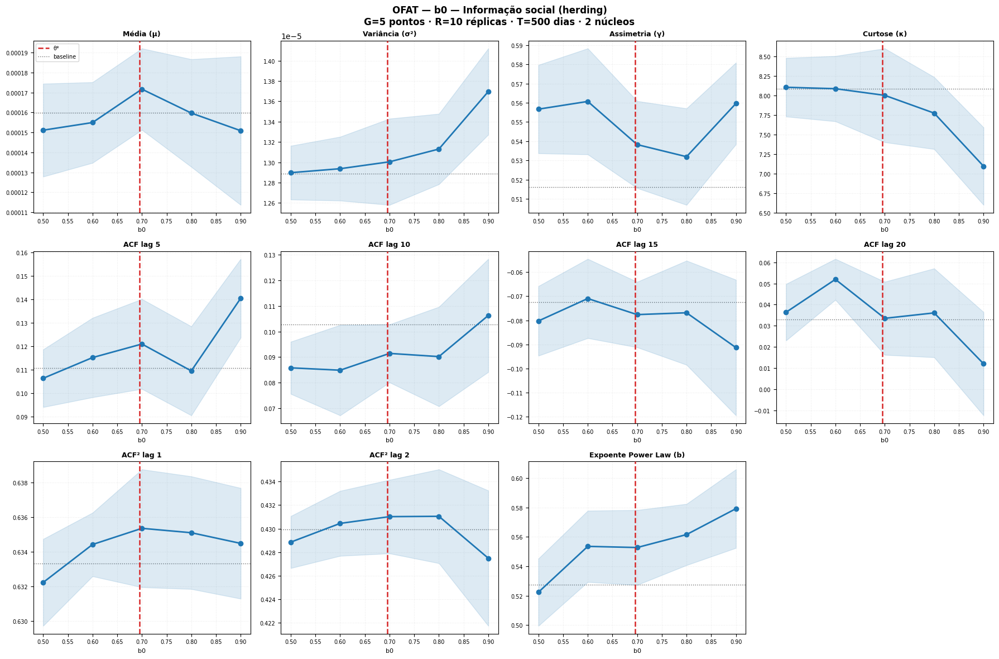

✓ Figura salva: /content/drive/MyDrive/tese_fii/ofat_results2/figures/ofat_b0.png

Δ_rel para b0:
  Output              Δ (%)       ρ  Direção
  --------------------------------------------------
  media                13.0%  -0.100  nao-monotonica
  variancia             6.2%  +1.000  crescente
  assimetria            5.6%  -0.200  nao-monotonica
  curtose              12.5%  -1.000  decrescente
  acf_lag5             30.8%  +0.700  nao-monotonica
  acf_lag10            20.8%  +0.800  nao-monotonica
  acf_lag15            28.1%  -0.300  nao-monotonica
  acf_lag20           121.1%  -0.800  nao-monotonica
  acf2_lag1             0.5%  +0.600  nao-monotonica
  acf2_lag2             0.8%  +0.000  nao-monotonica
  power_law_b          10.8%  +0.900  crescente

── Status geral ──────────────────────────
  a0      ✓ 5/5 pontos  
  b0      ✓ 5/5 pontos  ◄ atual
  c0      ✓ 5/5 pontos  
  beta    ✓ 5/5 pontos  
  peso    ✓ 5/5 pontos  
──────────────────────────────────────────

Próximo: mude 

In [ ]:
# ══════════════════════════════════════════════════════════════
# OFAT — UM PARÂMETRO POR VEZ (joblib paralelo)
# Versão final com todos os outputs e θ* atualizado
#
# INSTRUÇÕES:
#   1. Cole tudo em UMA célula do Colab
#   2. Mude apenas PARAM_ATUAL na linha abaixo
#   3. Execute — salva no Drive automaticamente
#   4. Quando terminar, mude para o próximo parâmetro
#
# ORDEM: 'b0' → 'a0' → 'c0' → 'beta' → 'peso'
# ══════════════════════════════════════════════════════════════

# ⚠️ MUDE AQUI A CADA RODADA ─────────────────────────────────
PARAM_ATUAL = 'b0'   # opções: 'a0' | 'b0' | 'c0' | 'beta' | 'peso'
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os, time, warnings
from scipy.stats import kurtosis, skew, t as t_dist, spearmanr
from scipy.optimize import curve_fit
from statsmodels.tsa.stattools import acf
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

# ── θ* atualizado ─────────────────────────────────────────────
THETA_STAR = {
    'a0':   parametros_sistema[0],
    'b0':   parametros_sistema[1],
    'c0':   parametros_sistema[2],
    'beta': parametros_sistema[3],
    'peso': parametros_sistema[4],
}

# ── Intervalos de Mcal ────────────────────────────────────────
MCAL = {
    'a0':   (0.50, 0.90),
    'b0':   (0.50, 0.90),
    'c0':   (0.50, 0.90),
    'beta': (0.10, 0.30),
    'peso': (0.06, 0.20),
}

# ── Outputs — consistentes com calibração e validação ─────────
OUTPUT_LABELS = {
    'media':      'Média (μ)',
    'variancia':  'Variância (σ²)',
    'assimetria': 'Assimetria (γ)',
    'curtose':    'Curtose (κ)',
    'acf_lag5':   'ACF lag 5',
    'acf_lag10':  'ACF lag 10',
    'acf_lag15':  'ACF lag 15',
    'acf_lag20':  'ACF lag 20',
    'acf2_lag1':  'ACF² lag 1',
    'acf2_lag2':  'ACF² lag 2',
    'power_law_b': 'Expoente Power Law (b)',
}

PARAM_LABELS = {
    'a0':   'a0 — Informação privada',
    'b0':   'b0 — Informação social (herding)',
    'c0':   'c0 — Notícias (mídia)',
    'beta': 'beta — Literacia financeira',
    'peso': 'peso — Peso do preço esperado',
}

N_GRID  = 5
N_REP   = 10
N_JOBS  = 2
HORIZON = 500

# ── Diretório de saída ────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    OUT_DIR = '/content/drive/MyDrive/tese_fii/ofat_results2'
except Exception:
    OUT_DIR = '/content/ofat_results2'

FIG_DIR       = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)
RESULT_FILE   = f'{OUT_DIR}/ofat_{PARAM_ATUAL}.csv'
BASELINE_FILE = f'{OUT_DIR}/baseline.csv'

sim_por_param = N_GRID * N_REP
t_est = sim_por_param * 2.56 / N_JOBS

print(f'Parâmetro : {PARAM_ATUAL}')
print(f'θ*        : {THETA_STAR}')
print(f'Grade     : {N_GRID} pontos × {N_REP} réplicas = {sim_por_param} sim.')
print(f'Núcleos   : {N_JOBS}')
print(f'Tempo est.: ~{t_est:.0f} min = {t_est/60:.1f}h')
print(f'Outputs   : {len(OUTPUT_LABELS)}')
print(f'Saída     : {RESULT_FILE}')
print()

# ── Simulador ─────────────────────────────────────────────────
sys.path.append('/content/Mercado-Artificial-Fiis')
from src.simulacao import simular_mercado_e_plotar

def run_model(a0, b0, c0, beta, peso, seed, T=HORIZON):
    np.random.seed(seed)

    # Cópia limpa do SIM_PARAMS — sem choques aleatórios
    params = copy.deepcopy(SIM_PARAMS)
    params["prob_choque_diario"] = 0.0   # OFAT sem ruído de choque
    params["choques"]            = []     # sem choques programados

    resultado = simular_mercado_e_plotar(
        parametros_sistema=[a0, b0, c0, beta, peso],
        num_dias=T,
        sim_params=params,
        imprimir=False,
    )
    ret = np.array(resultado[1])
    ret = ret[np.isfinite(ret)]
    return ret

# ── Função power law ─────────────────────────────────────────
def _power(x, a, b):
    return a / np.power(x, b)

def calcular_power_law_b(retornos, lags=40):
    """
    Calcula o expoente b da power law nos retornos absolutos.
    Replica exatamente o procedimento de plot_power_law()
    em fatos_estilizados.py.
    """
    nlags   = min(lags, len(retornos) - 2)
    acf_abs = acf(np.abs(retornos), nlags=nlags, fft=True)
    lags_arr = np.arange(1, nlags + 1)
    try:
        popt, _ = curve_fit(_power, lags_arr, acf_abs[1:],
                            p0=[1, 1], maxfev=5000)
        b = float(popt[1])
        # Filtro de sanidade — igual ao usado na validação
        if b <= 0 or b >= 3 or np.isnan(b):
            return np.nan
        return b
    except Exception:
        return np.nan

# ── Calcular todos os outputs ─────────────────────────────────
def compute_outputs(ret):
    if len(ret) < 50:
        return {k: np.nan for k in OUTPUT_LABELS}

    ret2 = ret ** 2

    try:
        acf_r  = acf(ret,  nlags=20, fft=True, missing='drop')
    except Exception:
        acf_r  = np.full(21, np.nan)

    try:
        acf_r2 = acf(ret2, nlags=2,  fft=True, missing='drop')
    except Exception:
        acf_r2 = np.full(3, np.nan)

    b = calcular_power_law_b(ret, lags=40)

    return {
        'media':       float(np.mean(ret)),
        'variancia':   float(np.var(ret)),
        'assimetria':  float(skew(ret, nan_policy='omit')),
        'curtose':     float(kurtosis(ret, fisher=True, nan_policy='omit')),
        'acf_lag5':    float(acf_r[5])  if len(acf_r) > 5  else np.nan,
        'acf_lag10':   float(acf_r[10]) if len(acf_r) > 10 else np.nan,
        'acf_lag15':   float(acf_r[15]) if len(acf_r) > 15 else np.nan,
        'acf_lag20':   float(acf_r[20]) if len(acf_r) > 20 else np.nan,
        'acf2_lag1':   float(acf_r2[1]) if len(acf_r2) > 1 else np.nan,
        'acf2_lag2':   float(acf_r2[2]) if len(acf_r2) > 2 else np.nan,
        'power_law_b': b,
    }

def aggregate(records):
    df = pd.DataFrame(records)
    out = {}
    for col in OUTPUT_LABELS:
        v = df[col].dropna().values
        if len(v) == 0:
            out[col] = dict(mean=np.nan, ci_lo=np.nan, ci_hi=np.nan)
            continue
        m  = v.mean()
        se = v.std(ddof=1) / max(len(v)**0.5, 1)
        ci = t_dist.interval(0.95, df=max(len(v)-1, 1), loc=m, scale=se)
        out[col] = dict(mean=m, ci_lo=ci[0], ci_hi=ci[1])
    return out

def rodar_replica(params, seed):
    """Uma réplica — chamada pelo joblib."""
    ret = run_model(**params, seed=seed)
    return compute_outputs(ret)

# ══════════════════════════════════════════════════════════════
# ETAPA 1 — BASELINE
# ══════════════════════════════════════════════════════════════

if os.path.exists(BASELINE_FILE):
    df_base  = pd.read_csv(BASELINE_FILE)
    baseline = {col: df_base[col].dropna().mean()
                for col in OUTPUT_LABELS}
    print(f'✓ Baseline carregado ({len(df_base)} linhas)')
else:
    print('Rodando baseline (10 réplicas em paralelo)...')
    t0    = time.time()
    seeds = [90000 + r for r in range(10)]
    recs  = Parallel(n_jobs=N_JOBS)(
        delayed(rodar_replica)(THETA_STAR, s) for s in seeds
    )
    df_base = pd.DataFrame(recs)
    df_base.to_csv(BASELINE_FILE, index=False)
    baseline = {col: df_base[col].dropna().mean()
                for col in OUTPUT_LABELS}
    print(f'✓ Baseline em {(time.time()-t0)/60:.1f} min')

print()
print('Baseline (médias):')
for k, v in baseline.items():
    print(f'  {k:14s}: {v:+.6f}')
print()

# ══════════════════════════════════════════════════════════════
# ETAPA 2 — VARREDURA OFAT
# ══════════════════════════════════════════════════════════════

# Retomar progresso se existir
if os.path.exists(RESULT_FILE):
    df_existing = pd.read_csv(RESULT_FILE)
    done_values = set(df_existing['value'].round(4).unique())
    print(f'Retomando: {len(done_values)} pontos já concluídos')
else:
    done_values = set()

lo, hi    = MCAL[PARAM_ATUAL]
grade     = np.linspace(lo, hi, N_GRID)
pendentes = [v for v in grade if round(v, 4) not in done_values]

print(f'Pontos pendentes: {len(pendentes)}/{N_GRID}')
print()

t_exp = time.time()

for idx, val in enumerate(pendentes):

    t0     = time.time()
    params = {**THETA_STAR, PARAM_ATUAL: float(val)}

    seeds = [
        abs(hash(f'{PARAM_ATUAL}_{val:.6f}_{r}')) % (2**31)
        for r in range(N_REP)
    ]

    recs = Parallel(n_jobs=N_JOBS)(
        delayed(rodar_replica)(params, s) for s in seeds
    )

    agg = aggregate(recs)

    # Montar e salvar imediatamente
    rows = []
    for oname, st in agg.items():
        rows.append({
            'param':  PARAM_ATUAL,
            'value':  round(val, 6),
            'output': oname,
            'mean':   st['mean'],
            'ci_lo':  st['ci_lo'],
            'ci_hi':  st['ci_hi'],
        })

    df_ponto = pd.DataFrame(rows)
    if os.path.exists(RESULT_FILE):
        df_ponto.to_csv(RESULT_FILE, mode='a', header=False, index=False)
    else:
        df_ponto.to_csv(RESULT_FILE, index=False)

    # Status
    t_este  = time.time() - t0
    elapsed = time.time() - t_exp
    restam  = len(pendentes) - (idx + 1)
    eta     = restam * t_este / 60

    print(f'[{idx+1:2d}/{len(pendentes)}] '
          f'{PARAM_ATUAL}={val:.4f}  '
          f'κ={agg["curtose"]["mean"]:+.3f}  '
          f'b={agg["power_law_b"]["mean"]:+.3f}  '
          f'{t_este:.0f}s  '
          f'ETA={eta:.0f}min  '
          f'total={elapsed/60:.0f}min')

print()
print(f'✓ Parâmetro {PARAM_ATUAL} concluído')

# ══════════════════════════════════════════════════════════════
# ETAPA 3 — FIGURA (grade 4×3 para 11 outputs)
# ══════════════════════════════════════════════════════════════

df_param = pd.read_csv(RESULT_FILE)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes_flat = axes.flatten()

for j, oname in enumerate(OUTPUT_LABELS):
    ax   = axes_flat[j]
    df_o = df_param[df_param['output'] == oname].sort_values('value')
    x    = df_o['value'].values
    y    = df_o['mean'].values
    clo  = df_o['ci_lo'].values
    chi  = df_o['ci_hi'].values
    base = baseline[oname]

    ax.plot(x, y, color='#1f77b4', lw=2,
            marker='o', ms=6, zorder=3)
    ax.fill_between(x, clo, chi,
                    color='#1f77b4', alpha=0.15, zorder=2)
    ax.axvline(THETA_STAR[PARAM_ATUAL], color='#d62728',
               lw=1.8, ls='--', label='θ*', zorder=4)
    ax.axhline(base, color='black', lw=1,
               ls=':', alpha=0.6, label='baseline', zorder=1)
    ax.set_title(OUTPUT_LABELS[oname], fontsize=9, fontweight='bold')
    ax.set_xlabel(PARAM_ATUAL, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25, ls=':')
    if j == 0:
        ax.legend(fontsize=7)

# Esconder painel extra (12 painéis, 11 outputs)
axes_flat[11].set_visible(False)

fig.suptitle(
    f'OFAT — {PARAM_LABELS[PARAM_ATUAL]}\n'
    f'G={N_GRID} pontos · R={N_REP} réplicas · '
    f'T={HORIZON} dias · {N_JOBS} núcleos',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/ofat_{PARAM_ATUAL}.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura salva: {path}')

# ══════════════════════════════════════════════════════════════
# ETAPA 4 — Δ_rel e direção
# ══════════════════════════════════════════════════════════════

print()
print(f'Δ_rel para {PARAM_ATUAL}:')
print(f'  {"Output":16s}  {"Δ (%)":>7s}  {"ρ":>6s}  Direção')
print(f'  {"-"*50}')

summary_rows = []
for oname in OUTPUT_LABELS:
    df_o  = df_param[df_param['output'] == oname].sort_values('value')
    y     = df_o['mean'].dropna().values
    if len(y) < 2:
        continue
    base  = baseline[oname]
    delta = (y.max() - y.min()) / (abs(base) + 1e-12)
    rho, pval = spearmanr(range(len(y)), y)
    if pval < 0.05 and abs(rho) >= 0.6:
        direcao = 'crescente' if rho > 0 else 'decrescente'
    else:
        direcao = 'nao-monotonica'
    print(f'  {oname:16s}  {delta*100:7.1f}%  {rho:+.3f}  {direcao}')
    summary_rows.append(dict(
        param=PARAM_ATUAL, output=oname,
        delta_pct=round(delta*100, 2),
        direcao=direcao,
        rho=round(rho, 4), pval=round(pval, 4),
        baseline=round(base, 8),
        y_min=round(y.min(), 8),
        y_max=round(y.max(), 8),
    ))

# Salvar resumo deste parâmetro
df_sum = pd.DataFrame(summary_rows)
df_sum.to_csv(f'{OUT_DIR}/ofat_summary_{PARAM_ATUAL}.csv', index=False)

# ══════════════════════════════════════════════════════════════
# CHECKLIST GERAL
# ══════════════════════════════════════════════════════════════

print()
print('── Status geral ──────────────────────────')
for p in ['a0', 'b0', 'c0', 'beta', 'peso']:
    f = f'{OUT_DIR}/ofat_{p}.csv'
    if os.path.exists(f):
        n = len(pd.read_csv(f)['value'].unique())
        status = f'✓ {n}/{N_GRID} pontos'
    else:
        status = '○ pendente'
    marker = '◄ atual' if p == PARAM_ATUAL else ''
    print(f'  {p:6s}  {status}  {marker}')
print('──────────────────────────────────────────')
print()
print('Próximo: mude PARAM_ATUAL e rode novamente')

In [ ]:
parametros_sistema

array([0.84822756, 0.69540723, 0.87855894, 0.15595803, 0.07548527])

In [ ]:
THETA_STAR

{'a0': np.float64(0.8482275571108211),
 'b0': np.float64(0.695407231715014),
 'c0': np.float64(0.8785589354774088),
 'beta': np.float64(0.1559580296673415),
 'peso': np.float64(0.0754852709451064)}

##c0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Parâmetro : c0
θ*        : {'a0': np.float64(0.8482275571108211), 'b0': np.float64(0.695407231715014), 'c0': np.float64(0.8785589354774088), 'beta': np.float64(0.1559580296673415), 'peso': np.float64(0.0754852709451064)}
Grade     : 5 pontos × 10 réplicas = 50 sim.
Núcleos   : 2
Tempo est.: ~64 min = 1.1h
Outputs   : 11
Saída     : /content/drive/MyDrive/tese_fii/ofat_results2/ofat_c0.csv

✓ Baseline carregado (10 linhas)

Baseline (médias):
  media         : +0.000160
  variancia     : +0.000013
  assimetria    : +0.516043
  curtose       : +8.088465
  acf_lag5      : +0.110780
  acf_lag10     : +0.102715
  acf_lag15     : -0.072397
  acf_lag20     : +0.032951
  acf2_lag1     : +0.633324
  acf2_lag2     : +0.429923
  power_law_b   : +0.527387

Pontos pendentes: 5/5

[ 1/5] c0=0.5000  κ=+15.192  b=+0.410  1398s  ETA=93min  total=23min
[ 2/5] c0=0.6000  κ=+12.

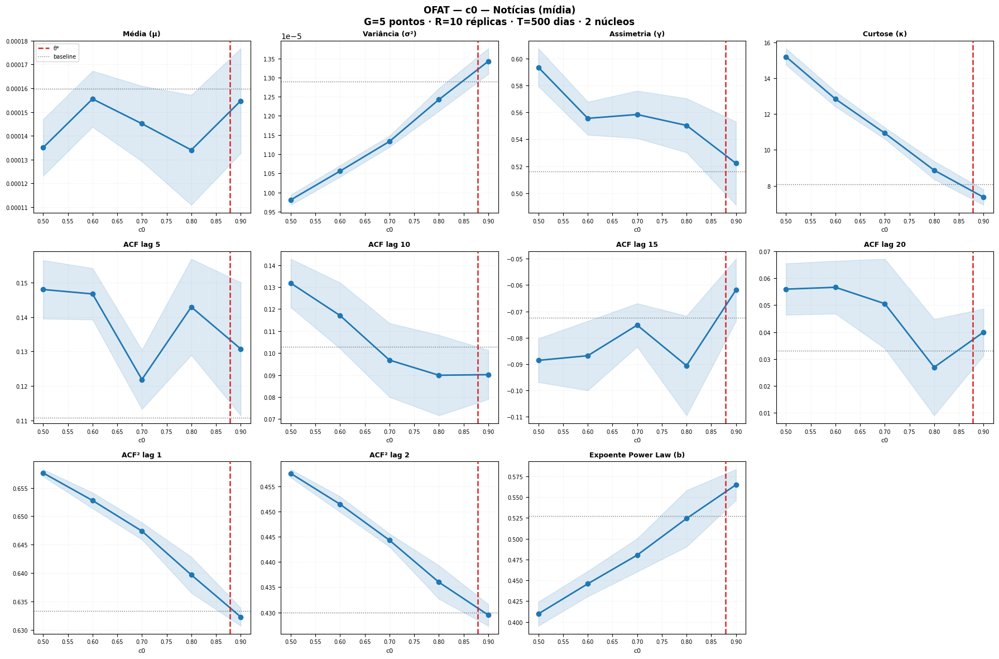

✓ Figura salva: /content/drive/MyDrive/tese_fii/ofat_results2/figures/ofat_c0.png

Δ_rel para c0:
  Output              Δ (%)       ρ  Direção
  --------------------------------------------------
  media                13.4%  +0.000  nao-monotonica
  variancia            28.1%  +1.000  crescente
  assimetria           13.8%  -0.900  decrescente
  curtose              96.8%  -1.000  decrescente
  acf_lag5             23.6%  -0.700  nao-monotonica
  acf_lag10            40.8%  -0.900  decrescente
  acf_lag15            39.6%  +0.400  nao-monotonica
  acf_lag20            90.4%  -0.800  nao-monotonica
  acf2_lag1             4.0%  -1.000  decrescente
  acf2_lag2             6.5%  -1.000  decrescente
  power_law_b          29.4%  +1.000  crescente

── Status geral ──────────────────────────
  a0      ✓ 5/5 pontos  
  b0      ✓ 5/5 pontos  
  c0      ✓ 5/5 pontos  ◄ atual
  beta    ○ pendente  
  peso    ○ pendente  
──────────────────────────────────────────

Próximo: mude PARAM_ATUAL e ro

In [ ]:
# ══════════════════════════════════════════════════════════════
# OFAT — UM PARÂMETRO POR VEZ (joblib paralelo)
# Versão final com todos os outputs e θ* atualizado
#
# INSTRUÇÕES:
#   1. Cole tudo em UMA célula do Colab
#   2. Mude apenas PARAM_ATUAL na linha abaixo
#   3. Execute — salva no Drive automaticamente
#   4. Quando terminar, mude para o próximo parâmetro
#
# ORDEM: 'b0' → 'a0' → 'c0' → 'beta' → 'peso'
# ══════════════════════════════════════════════════════════════

# ⚠️ MUDE AQUI A CADA RODADA ─────────────────────────────────
PARAM_ATUAL = 'c0'   # opções: 'a0' | 'b0' | 'c0' | 'beta' | 'peso'
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os, time, warnings
from scipy.stats import kurtosis, skew, t as t_dist, spearmanr
from scipy.optimize import curve_fit
from statsmodels.tsa.stattools import acf
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

# ── θ* atualizado ─────────────────────────────────────────────
THETA_STAR = {
    'a0':   parametros_sistema[0],
    'b0':   parametros_sistema[1],
    'c0':   parametros_sistema[2],
    'beta': parametros_sistema[3],
    'peso': parametros_sistema[4],
}

# ── Intervalos de Mcal ────────────────────────────────────────
MCAL = {
    'a0':   (0.50, 0.90),
    'b0':   (0.50, 0.90),
    'c0':   (0.50, 0.90),
    'beta': (0.10, 0.30),
    'peso': (0.06, 0.20),
}

# ── Outputs — consistentes com calibração e validação ─────────
OUTPUT_LABELS = {
    'media':      'Média (μ)',
    'variancia':  'Variância (σ²)',
    'assimetria': 'Assimetria (γ)',
    'curtose':    'Curtose (κ)',
    'acf_lag5':   'ACF lag 5',
    'acf_lag10':  'ACF lag 10',
    'acf_lag15':  'ACF lag 15',
    'acf_lag20':  'ACF lag 20',
    'acf2_lag1':  'ACF² lag 1',
    'acf2_lag2':  'ACF² lag 2',
    'power_law_b': 'Expoente Power Law (b)',
}

PARAM_LABELS = {
    'a0':   'a0 — Informação privada',
    'b0':   'b0 — Informação social (herding)',
    'c0':   'c0 — Notícias (mídia)',
    'beta': 'beta — Literacia financeira',
    'peso': 'peso — Peso do preço esperado',
}

N_GRID  = 5
N_REP   = 10
N_JOBS  = 2
HORIZON = 500

# ── Diretório de saída ────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    OUT_DIR = '/content/drive/MyDrive/tese_fii/ofat_results2'
except Exception:
    OUT_DIR = '/content/ofat_results2'

FIG_DIR       = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)
RESULT_FILE   = f'{OUT_DIR}/ofat_{PARAM_ATUAL}.csv'
BASELINE_FILE = f'{OUT_DIR}/baseline.csv'

sim_por_param = N_GRID * N_REP
t_est = sim_por_param * 2.56 / N_JOBS

print(f'Parâmetro : {PARAM_ATUAL}')
print(f'θ*        : {THETA_STAR}')
print(f'Grade     : {N_GRID} pontos × {N_REP} réplicas = {sim_por_param} sim.')
print(f'Núcleos   : {N_JOBS}')
print(f'Tempo est.: ~{t_est:.0f} min = {t_est/60:.1f}h')
print(f'Outputs   : {len(OUTPUT_LABELS)}')
print(f'Saída     : {RESULT_FILE}')
print()

# ── Simulador ─────────────────────────────────────────────────
sys.path.append('/content/Mercado-Artificial-Fiis')
from src.simulacao import simular_mercado_e_plotar

def run_model(a0, b0, c0, beta, peso, seed, T=HORIZON):
    np.random.seed(seed)

    # Cópia limpa do SIM_PARAMS — sem choques aleatórios
    params = copy.deepcopy(SIM_PARAMS)
    params["prob_choque_diario"] = 0.0   # OFAT sem ruído de choque
    params["choques"]            = []     # sem choques programados

    resultado = simular_mercado_e_plotar(
        parametros_sistema=[a0, b0, c0, beta, peso],
        num_dias=T,
        sim_params=params,
        imprimir=False,
    )
    ret = np.array(resultado[1])
    ret = ret[np.isfinite(ret)]
    return ret

# ── Função power law ─────────────────────────────────────────
def _power(x, a, b):
    return a / np.power(x, b)

def calcular_power_law_b(retornos, lags=40):
    """
    Calcula o expoente b da power law nos retornos absolutos.
    Replica exatamente o procedimento de plot_power_law()
    em fatos_estilizados.py.
    """
    nlags   = min(lags, len(retornos) - 2)
    acf_abs = acf(np.abs(retornos), nlags=nlags, fft=True)
    lags_arr = np.arange(1, nlags + 1)
    try:
        popt, _ = curve_fit(_power, lags_arr, acf_abs[1:],
                            p0=[1, 1], maxfev=5000)
        b = float(popt[1])
        # Filtro de sanidade — igual ao usado na validação
        if b <= 0 or b >= 3 or np.isnan(b):
            return np.nan
        return b
    except Exception:
        return np.nan

# ── Calcular todos os outputs ─────────────────────────────────
def compute_outputs(ret):
    if len(ret) < 50:
        return {k: np.nan for k in OUTPUT_LABELS}

    ret2 = ret ** 2

    try:
        acf_r  = acf(ret,  nlags=20, fft=True, missing='drop')
    except Exception:
        acf_r  = np.full(21, np.nan)

    try:
        acf_r2 = acf(ret2, nlags=2,  fft=True, missing='drop')
    except Exception:
        acf_r2 = np.full(3, np.nan)

    b = calcular_power_law_b(ret, lags=40)

    return {
        'media':       float(np.mean(ret)),
        'variancia':   float(np.var(ret)),
        'assimetria':  float(skew(ret, nan_policy='omit')),
        'curtose':     float(kurtosis(ret, fisher=True, nan_policy='omit')),
        'acf_lag5':    float(acf_r[5])  if len(acf_r) > 5  else np.nan,
        'acf_lag10':   float(acf_r[10]) if len(acf_r) > 10 else np.nan,
        'acf_lag15':   float(acf_r[15]) if len(acf_r) > 15 else np.nan,
        'acf_lag20':   float(acf_r[20]) if len(acf_r) > 20 else np.nan,
        'acf2_lag1':   float(acf_r2[1]) if len(acf_r2) > 1 else np.nan,
        'acf2_lag2':   float(acf_r2[2]) if len(acf_r2) > 2 else np.nan,
        'power_law_b': b,
    }

def aggregate(records):
    df = pd.DataFrame(records)
    out = {}
    for col in OUTPUT_LABELS:
        v = df[col].dropna().values
        if len(v) == 0:
            out[col] = dict(mean=np.nan, ci_lo=np.nan, ci_hi=np.nan)
            continue
        m  = v.mean()
        se = v.std(ddof=1) / max(len(v)**0.5, 1)
        ci = t_dist.interval(0.95, df=max(len(v)-1, 1), loc=m, scale=se)
        out[col] = dict(mean=m, ci_lo=ci[0], ci_hi=ci[1])
    return out

def rodar_replica(params, seed):
    """Uma réplica — chamada pelo joblib."""
    ret = run_model(**params, seed=seed)
    return compute_outputs(ret)

# ══════════════════════════════════════════════════════════════
# ETAPA 1 — BASELINE
# ══════════════════════════════════════════════════════════════

if os.path.exists(BASELINE_FILE):
    df_base  = pd.read_csv(BASELINE_FILE)
    baseline = {col: df_base[col].dropna().mean()
                for col in OUTPUT_LABELS}
    print(f'✓ Baseline carregado ({len(df_base)} linhas)')
else:
    print('Rodando baseline (10 réplicas em paralelo)...')
    t0    = time.time()
    seeds = [90000 + r for r in range(10)]
    recs  = Parallel(n_jobs=N_JOBS)(
        delayed(rodar_replica)(THETA_STAR, s) for s in seeds
    )
    df_base = pd.DataFrame(recs)
    df_base.to_csv(BASELINE_FILE, index=False)
    baseline = {col: df_base[col].dropna().mean()
                for col in OUTPUT_LABELS}
    print(f'✓ Baseline em {(time.time()-t0)/60:.1f} min')

print()
print('Baseline (médias):')
for k, v in baseline.items():
    print(f'  {k:14s}: {v:+.6f}')
print()

# ══════════════════════════════════════════════════════════════
# ETAPA 2 — VARREDURA OFAT
# ══════════════════════════════════════════════════════════════

# Retomar progresso se existir
if os.path.exists(RESULT_FILE):
    df_existing = pd.read_csv(RESULT_FILE)
    done_values = set(df_existing['value'].round(4).unique())
    print(f'Retomando: {len(done_values)} pontos já concluídos')
else:
    done_values = set()

lo, hi    = MCAL[PARAM_ATUAL]
grade     = np.linspace(lo, hi, N_GRID)
pendentes = [v for v in grade if round(v, 4) not in done_values]

print(f'Pontos pendentes: {len(pendentes)}/{N_GRID}')
print()

t_exp = time.time()

for idx, val in enumerate(pendentes):

    t0     = time.time()
    params = {**THETA_STAR, PARAM_ATUAL: float(val)}

    seeds = [
        abs(hash(f'{PARAM_ATUAL}_{val:.6f}_{r}')) % (2**31)
        for r in range(N_REP)
    ]

    recs = Parallel(n_jobs=N_JOBS)(
        delayed(rodar_replica)(params, s) for s in seeds
    )

    agg = aggregate(recs)

    # Montar e salvar imediatamente
    rows = []
    for oname, st in agg.items():
        rows.append({
            'param':  PARAM_ATUAL,
            'value':  round(val, 6),
            'output': oname,
            'mean':   st['mean'],
            'ci_lo':  st['ci_lo'],
            'ci_hi':  st['ci_hi'],
        })

    df_ponto = pd.DataFrame(rows)
    if os.path.exists(RESULT_FILE):
        df_ponto.to_csv(RESULT_FILE, mode='a', header=False, index=False)
    else:
        df_ponto.to_csv(RESULT_FILE, index=False)

    # Status
    t_este  = time.time() - t0
    elapsed = time.time() - t_exp
    restam  = len(pendentes) - (idx + 1)
    eta     = restam * t_este / 60

    print(f'[{idx+1:2d}/{len(pendentes)}] '
          f'{PARAM_ATUAL}={val:.4f}  '
          f'κ={agg["curtose"]["mean"]:+.3f}  '
          f'b={agg["power_law_b"]["mean"]:+.3f}  '
          f'{t_este:.0f}s  '
          f'ETA={eta:.0f}min  '
          f'total={elapsed/60:.0f}min')

print()
print(f'✓ Parâmetro {PARAM_ATUAL} concluído')

# ══════════════════════════════════════════════════════════════
# ETAPA 3 — FIGURA (grade 4×3 para 11 outputs)
# ══════════════════════════════════════════════════════════════

df_param = pd.read_csv(RESULT_FILE)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes_flat = axes.flatten()

for j, oname in enumerate(OUTPUT_LABELS):
    ax   = axes_flat[j]
    df_o = df_param[df_param['output'] == oname].sort_values('value')
    x    = df_o['value'].values
    y    = df_o['mean'].values
    clo  = df_o['ci_lo'].values
    chi  = df_o['ci_hi'].values
    base = baseline[oname]

    ax.plot(x, y, color='#1f77b4', lw=2,
            marker='o', ms=6, zorder=3)
    ax.fill_between(x, clo, chi,
                    color='#1f77b4', alpha=0.15, zorder=2)
    ax.axvline(THETA_STAR[PARAM_ATUAL], color='#d62728',
               lw=1.8, ls='--', label='θ*', zorder=4)
    ax.axhline(base, color='black', lw=1,
               ls=':', alpha=0.6, label='baseline', zorder=1)
    ax.set_title(OUTPUT_LABELS[oname], fontsize=9, fontweight='bold')
    ax.set_xlabel(PARAM_ATUAL, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25, ls=':')
    if j == 0:
        ax.legend(fontsize=7)

# Esconder painel extra (12 painéis, 11 outputs)
axes_flat[11].set_visible(False)

fig.suptitle(
    f'OFAT — {PARAM_LABELS[PARAM_ATUAL]}\n'
    f'G={N_GRID} pontos · R={N_REP} réplicas · '
    f'T={HORIZON} dias · {N_JOBS} núcleos',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/ofat_{PARAM_ATUAL}.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura salva: {path}')

# ══════════════════════════════════════════════════════════════
# ETAPA 4 — Δ_rel e direção
# ══════════════════════════════════════════════════════════════

print()
print(f'Δ_rel para {PARAM_ATUAL}:')
print(f'  {"Output":16s}  {"Δ (%)":>7s}  {"ρ":>6s}  Direção')
print(f'  {"-"*50}')

summary_rows = []
for oname in OUTPUT_LABELS:
    df_o  = df_param[df_param['output'] == oname].sort_values('value')
    y     = df_o['mean'].dropna().values
    if len(y) < 2:
        continue
    base  = baseline[oname]
    delta = (y.max() - y.min()) / (abs(base) + 1e-12)
    rho, pval = spearmanr(range(len(y)), y)
    if pval < 0.05 and abs(rho) >= 0.6:
        direcao = 'crescente' if rho > 0 else 'decrescente'
    else:
        direcao = 'nao-monotonica'
    print(f'  {oname:16s}  {delta*100:7.1f}%  {rho:+.3f}  {direcao}')
    summary_rows.append(dict(
        param=PARAM_ATUAL, output=oname,
        delta_pct=round(delta*100, 2),
        direcao=direcao,
        rho=round(rho, 4), pval=round(pval, 4),
        baseline=round(base, 8),
        y_min=round(y.min(), 8),
        y_max=round(y.max(), 8),
    ))

# Salvar resumo deste parâmetro
df_sum = pd.DataFrame(summary_rows)
df_sum.to_csv(f'{OUT_DIR}/ofat_summary_{PARAM_ATUAL}.csv', index=False)

# ══════════════════════════════════════════════════════════════
# CHECKLIST GERAL
# ══════════════════════════════════════════════════════════════

print()
print('── Status geral ──────────────────────────')
for p in ['a0', 'b0', 'c0', 'beta', 'peso']:
    f = f'{OUT_DIR}/ofat_{p}.csv'
    if os.path.exists(f):
        n = len(pd.read_csv(f)['value'].unique())
        status = f'✓ {n}/{N_GRID} pontos'
    else:
        status = '○ pendente'
    marker = '◄ atual' if p == PARAM# ══════════════════════════════════════════════════════════════
# OFAT — UM PARÂMETRO POR VEZ (joblib paralelo)
# Versão final com todos os outputs e θ* atualizado
#
# INSTRUÇÕES:
#   1. Cole tudo em UMA célula do Colab
#   2. Mude apenas PARAM_ATUAL na linha abaixo
#   3. Execute — salva no Drive automaticamente
#   4. Quando terminar, mude para o próximo parâmetro
#
# ORDEM: 'b0' → 'a0' → 'c0' → 'beta' → 'peso'
# ══════════════════════════════════════════════════════════════

# ⚠️ MUDE AQUI A CADA RODADA ─────────────────────────────────
PARAM_ATUAL = 'b0'   # opções: 'a0' | 'b0' | 'c0' | 'beta' | 'peso'
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os, time, warnings
from scipy.stats import kurtosis, skew, t as t_dist, spearmanr
from scipy.optimize import curve_fit
from statsmodels.tsa.stattools import acf
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

# ── θ* atualizado ─────────────────────────────────────────────
THETA_STAR = {
    'a0':   parametros_sistema[0],
    'b0':   parametros_sistema[1],
    'c0':   parametros_sistema[2],
    'beta': parametros_sistema[3],
    'peso': parametros_sistema[4],
}

# ── Intervalos de Mcal ────────────────────────────────────────
MCAL = {
    'a0':   (0.50, 0.90),
    'b0':   (0.50, 0.90),
    'c0':   (0.50, 0.90),
    'beta': (0.10, 0.30),
    'peso': (0.06, 0.20),
}

# ── Outputs — consistentes com calibração e validação ─────────
OUTPUT_LABELS = {
    'media':      'Média (μ)',
    'variancia':  'Variância (σ²)',
    'assimetria': 'Assimetria (γ)',
    'curtose':    'Curtose (κ)',
    'acf_lag5':   'ACF lag 5',
    'acf_lag10':  'ACF lag 10',
    'acf_lag15':  'ACF lag 15',
    'acf_lag20':  'ACF lag 20',
    'acf2_lag1':  'ACF² lag 1',
    'acf2_lag2':  'ACF² lag 2',
    'power_law_b': 'Expoente Power Law (b)',
}

PARAM_LABELS = {
    'a0':   'a0 — Informação privada',
    'b0':   'b0 — Informação social (herding)',
    'c0':   'c0 — Notícias (mídia)',
    'beta': 'beta — Literacia financeira',
    'peso': 'peso — Peso do preço esperado',
}

N_GRID  = 5
N_REP   = 10
N_JOBS  = 2
HORIZON = 500

# ── Diretório de saída ────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    OUT_DIR = '/content/drive/MyDrive/tese_fii/ofat_results2'
except Exception:
    OUT_DIR = '/content/ofat_results2'

FIG_DIR       = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)
RESULT_FILE   = f'{OUT_DIR}/ofat_{PARAM_ATUAL}.csv'
BASELINE_FILE = f'{OUT_DIR}/baseline.csv'

sim_por_param = N_GRID * N_REP
t_est = sim_por_param * 2.56 / N_JOBS

print(f'Parâmetro : {PARAM_ATUAL}')
print(f'θ*        : {THETA_STAR}')
print(f'Grade     : {N_GRID} pontos × {N_REP} réplicas = {sim_por_param} sim.')
print(f'Núcleos   : {N_JOBS}')
print(f'Tempo est.: ~{t_est:.0f} min = {t_est/60:.1f}h')
print(f'Outputs   : {len(OUTPUT_LABELS)}')
print(f'Saída     : {RESULT_FILE}')
print()

# ── Simulador ─────────────────────────────────────────────────
sys.path.append('/content/Mercado-Artificial-Fiis')
from src.simulacao import simular_mercado_e_plotar

def run_model(a0, b0, c0, beta, peso, seed, T=HORIZON):
    np.random.seed(seed)

    # Cópia limpa do SIM_PARAMS — sem choques aleatórios
    params = copy.deepcopy(SIM_PARAMS)
    params["prob_choque_diario"] = 0.0   # OFAT sem ruído de choque
    params["choques"]            = []     # sem choques programados

    resultado = simular_mercado_e_plotar(
        parametros_sistema=[a0, b0, c0, beta, peso],
        num_dias=T,
        sim_params=params,
        imprimir=False,
    )
    ret = np.array(resultado[1])
    ret = ret[np.isfinite(ret)]
    return ret

# ── Função power law ─────────────────────────────────────────
def _power(x, a, b):
    return a / np.power(x, b)

def calcular_power_law_b(retornos, lags=40):
    """
    Calcula o expoente b da power law nos retornos absolutos.
    Replica exatamente o procedimento de plot_power_law()
    em fatos_estilizados.py.
    """
    nlags   = min(lags, len(retornos) - 2)
    acf_abs = acf(np.abs(retornos), nlags=nlags, fft=True)
    lags_arr = np.arange(1, nlags + 1)
    try:
        popt, _ = curve_fit(_power, lags_arr, acf_abs[1:],
                            p0=[1, 1], maxfev=5000)
        b = float(popt[1])
        # Filtro de sanidade — igual ao usado na validação
        if b <= 0 or b >= 3 or np.isnan(b):
            return np.nan
        return b
    except Exception:
        return np.nan

# ── Calcular todos os outputs ─────────────────────────────────
def compute_outputs(ret):
    if len(ret) < 50:
        return {k: np.nan for k in OUTPUT_LABELS}

    ret2 = ret ** 2

    try:
        acf_r  = acf(ret,  nlags=20, fft=True, missing='drop')
    except Exception:
        acf_r  = np.full(21, np.nan)

    try:
        acf_r2 = acf(ret2, nlags=2,  fft=True, missing='drop')
    except Exception:
        acf_r2 = np.full(3, np.nan)

    b = calcular_power_law_b(ret, lags=40)

    return {
        'media':       float(np.mean(ret)),
        'variancia':   float(np.var(ret)),
        'assimetria':  float(skew(ret, nan_policy='omit')),
        'curtose':     float(kurtosis(ret, fisher=True, nan_policy='omit')),
        'acf_lag5':    float(acf_r[5])  if len(acf_r) > 5  else np.nan,
        'acf_lag10':   float(acf_r[10]) if len(acf_r) > 10 else np.nan,
        'acf_lag15':   float(acf_r[15]) if len(acf_r) > 15 else np.nan,
        'acf_lag20':   float(acf_r[20]) if len(acf_r) > 20 else np.nan,
        'acf2_lag1':   float(acf_r2[1]) if len(acf_r2) > 1 else np.nan,
        'acf2_lag2':   float(acf_r2[2]) if len(acf_r2) > 2 else np.nan,
        'power_law_b': b,
    }

def aggregate(records):
    df = pd.DataFrame(records)
    out = {}
    for col in OUTPUT_LABELS:
        v = df[col].dropna().values
        if len(v) == 0:
            out[col] = dict(mean=np.nan, ci_lo=np.nan, ci_hi=np.nan)
            continue
        m  = v.mean()
        se = v.std(ddof=1) / max(len(v)**0.5, 1)
        ci = t_dist.interval(0.95, df=max(len(v)-1, 1), loc=m, scale=se)
        out[col] = dict(mean=m, ci_lo=ci[0], ci_hi=ci[1])
    return out

def rodar_replica(params, seed):
    """Uma réplica — chamada pelo joblib."""
    ret = run_model(**params, seed=seed)
    return compute_outputs(ret)

# ══════════════════════════════════════════════════════════════
# ETAPA 1 — BASELINE
# ══════════════════════════════════════════════════════════════

if os.path.exists(BASELINE_FILE):
    df_base  = pd.read_csv(BASELINE_FILE)
    baseline = {col: df_base[col].dropna().mean()
                for col in OUTPUT_LABELS}
    print(f'✓ Baseline carregado ({len(df_base)} linhas)')
else:
    print('Rodando baseline (10 réplicas em paralelo)...')
    t0    = time.time()
    seeds = [90000 + r for r in range(10)]
    recs  = Parallel(n_jobs=N_JOBS)(
        delayed(rodar_replica)(THETA_STAR, s) for s in seeds
    )
    df_base = pd.DataFrame(recs)
    df_base.to_csv(BASELINE_FILE, index=False)
    baseline = {col: df_base[col].dropna().mean()
                for col in OUTPUT_LABELS}
    print(f'✓ Baseline em {(time.time()-t0)/60:.1f} min')

print()
print('Baseline (médias):')
for k, v in baseline.items():
    print(f'  {k:14s}: {v:+.6f}')
print()

# ══════════════════════════════════════════════════════════════
# ETAPA 2 — VARREDURA OFAT
# ══════════════════════════════════════════════════════════════

# Retomar progresso se existir
if os.path.exists(RESULT_FILE):
    df_existing = pd.read_csv(RESULT_FILE)
    done_values = set(df_existing['value'].round(4).unique())
    print(f'Retomando: {len(done_values)} pontos já concluídos')
else:
    done_values = set()

lo, hi    = MCAL[PARAM_ATUAL]
grade     = np.linspace(lo, hi, N_GRID)
pendentes = [v for v in grade if round(v, 4) not in done_values]

print(f'Pontos pendentes: {len(pendentes)}/{N_GRID}')
print()

t_exp = time.time()

for idx, val in enumerate(pendentes):

    t0     = time.time()
    params = {**THETA_STAR, PARAM_ATUAL: float(val)}

    seeds = [
        abs(hash(f'{PARAM_ATUAL}_{val:.6f}_{r}')) % (2**31)
        for r in range(N_REP)
    ]

    recs = Parallel(n_jobs=N_JOBS)(
        delayed(rodar_replica)(params, s) for s in seeds
    )

    agg = aggregate(recs)

    # Montar e salvar imediatamente
    rows = []
    for oname, st in agg.items():
        rows.append({
            'param':  PARAM_ATUAL,
            'value':  round(val, 6),
            'output': oname,
            'mean':   st['mean'],
            'ci_lo':  st['ci_lo'],
            'ci_hi':  st['ci_hi'],
        })

    df_ponto = pd.DataFrame(rows)
    if os.path.exists(RESULT_FILE):
        df_ponto.to_csv(RESULT_FILE, mode='a', header=False, index=False)
    else:
        df_ponto.to_csv(RESULT_FILE, index=False)

    # Status
    t_este  = time.time() - t0
    elapsed = time.time() - t_exp
    restam  = len(pendentes) - (idx + 1)
    eta     = restam * t_este / 60

    print(f'[{idx+1:2d}/{len(pendentes)}] '
          f'{PARAM_ATUAL}={val:.4f}  '
          f'κ={agg["curtose"]["mean"]:+.3f}  '
          f'b={agg["power_law_b"]["mean"]:+.3f}  '
          f'{t_este:.0f}s  '
          f'ETA={eta:.0f}min  '
          f'total={elapsed/60:.0f}min')

print()
print(f'✓ Parâmetro {PARAM_ATUAL} concluído')

# ══════════════════════════════════════════════════════════════
# ETAPA 3 — FIGURA (grade 4×3 para 11 outputs)
# ══════════════════════════════════════════════════════════════

df_param = pd.read_csv(RESULT_FILE)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes_flat = axes.flatten()

for j, oname in enumerate(OUTPUT_LABELS):
    ax   = axes_flat[j]
    df_o = df_param[df_param['output'] == oname].sort_values('value')
    x    = df_o['value'].values
    y    = df_o['mean'].values
    clo  = df_o['ci_lo'].values
    chi  = df_o['ci_hi'].values
    base = baseline[oname]

    ax.plot(x, y, color='#1f77b4', lw=2,
            marker='o', ms=6, zorder=3)
    ax.fill_between(x, clo, chi,
                    color='#1f77b4', alpha=0.15, zorder=2)
    ax.axvline(THETA_STAR[PARAM_ATUAL], color='#d62728',
               lw=1.8, ls='--', label='θ*', zorder=4)
    ax.axhline(base, color='black', lw=1,
               ls=':', alpha=0.6, label='baseline', zorder=1)
    ax.set_title(OUTPUT_LABELS[oname], fontsize=9, fontweight='bold')
    ax.set_xlabel(PARAM_ATUAL, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25, ls=':')
    if j == 0:
        ax.legend(fontsize=7)

# Esconder painel extra (12 painéis, 11 outputs)
axes_flat[11].set_visible(False)

fig.suptitle(
    f'OFAT — {PARAM_LABELS[PARAM_ATUAL]}\n'
    f'G={N_GRID} pontos · R={N_REP} réplicas · '
    f'T={HORIZON} dias · {N_JOBS} núcleos',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/ofat_{PARAM_ATUAL}.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura salva: {path}')

# ══════════════════════════════════════════════════════════════
# ETAPA 4 — Δ_rel e direção
# ══════════════════════════════════════════════════════════════

print()
print(f'Δ_rel para {PARAM_ATUAL}:')
print(f'  {"Output":16s}  {"Δ (%)":>7s}  {"ρ":>6s}  Direção')
print(f'  {"-"*50}')

summary_rows = []
for oname in OUTPUT_LABELS:
    df_o  = df_param[df_param['output'] == oname].sort_values('value')
    y     = df_o['mean'].dropna().values
    if len(y) < 2:
        continue
    base  = baseline[oname]
    delta = (y.max() - y.min()) / (abs(base) + 1e-12)
    rho, pval = spearmanr(range(len(y)), y)
    if pval < 0.05 and abs(rho) >= 0.6:
        direcao = 'crescente' if rho > 0 else 'decrescente'
    else:
        direcao = 'nao-monotonica'
    print(f'  {oname:16s}  {delta*100:7.1f}%  {rho:+.3f}  {direcao}')
    summary_rows.append(dict(
        param=PARAM_ATUAL, output=oname,
        delta_pct=round(delta*100, 2),
        direcao=direcao,
        rho=round(rho, 4), pval=round(pval, 4),
        baseline=round(base, 8),
        y_min=round(y.min(), 8),
        y_max=round(y.max(), 8),
    ))

# Salvar resumo deste parâmetro
df_sum = pd.DataFrame(summary_rows)
df_sum.to_csv(f'{OUT_DIR}/ofat_summary_{PARAM_ATUAL}.csv', index=False)

# ══════════════════════════════════════════════════════════════
# CHECKLIST GERAL
# ══════════════════════════════════════════════════════════════

print()
print('── Status geral ──────────────────────────')
for p in ['a0', 'b0', 'c0', 'beta', 'peso']:
    f = f'{OUT_DIR}/ofat_{p}.csv'
    if os.path.exists(f):
        n = len(pd.read_csv(f)['value'].unique())
        status = f'✓ {n}/{N_GRID} pontos'
    else:
        status = '○ pendente'
    marker = '◄ atual' if p == PARAM_ATUAL else ''
    print(f'  {p:6s}  {status}  {marker}')
print('──────────────────────────────────────────')
print()
print('Próximo: mude PARAM_ATUAL e rode novamente')_ATUAL else ''
    print(f'  {p:6s}  {status}  {marker}')
print('──────────────────────────────────────────')
print()
print('Próximo: mude PARAM_ATUAL e rode novamente')

##beta

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Parâmetro : beta
θ*        : {'a0': np.float64(0.8482275571108211), 'b0': np.float64(0.695407231715014), 'c0': np.float64(0.8785589354774088), 'beta': np.float64(0.1559580296673415), 'peso': np.float64(0.0754852709451064)}
Grade     : 5 pontos × 10 réplicas = 50 sim.
Núcleos   : 2
Tempo est.: ~64 min = 1.1h
Outputs   : 11
Saída     : /content/drive/MyDrive/tese_fii/ofat_results2/ofat_beta.csv

✓ Baseline carregado (10 linhas)

Baseline (médias):
  media         : +0.000160
  variancia     : +0.000013
  assimetria    : +0.516043
  curtose       : +8.088465
  acf_lag5      : +0.110780
  acf_lag10     : +0.102715
  acf_lag15     : -0.072397
  acf_lag20     : +0.032951
  acf2_lag1     : +0.633324
  acf2_lag2     : +0.429923
  power_law_b   : +0.527387

Pontos pendentes: 5/5

[ 1/5] beta=0.1000  κ=+7.031  b=+0.564  1351s  ETA=90min  total=23min
[ 2/5] beta=0.1500 

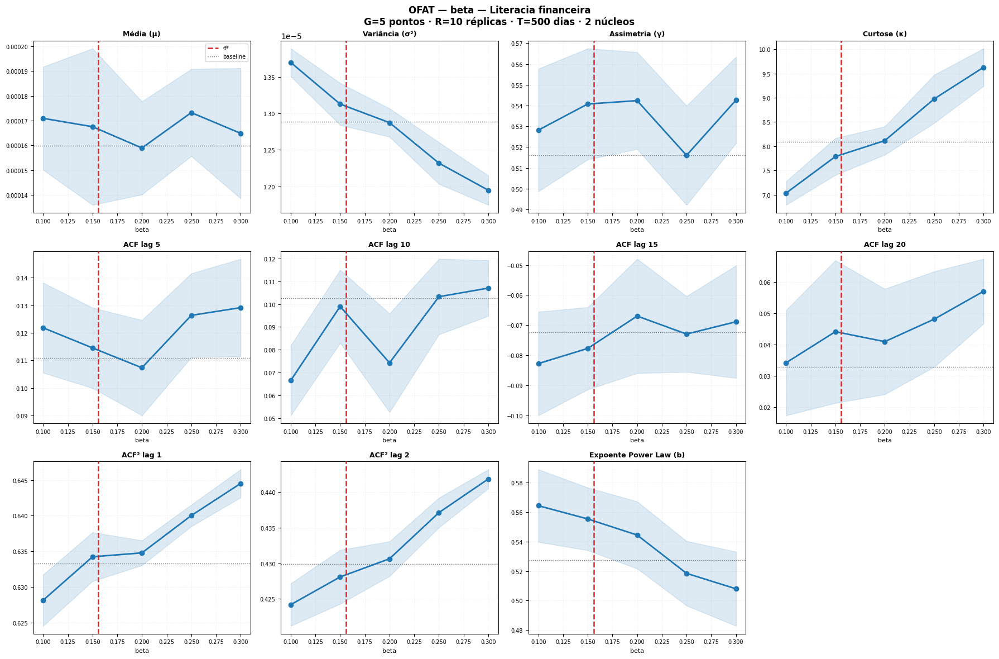

✓ Figura salva: /content/drive/MyDrive/tese_fii/ofat_results2/figures/ofat_beta.png

Δ_rel para beta:
  Output              Δ (%)       ρ  Direção
  --------------------------------------------------
  media                 8.9%  -0.200  nao-monotonica
  variancia            13.6%  -1.000  decrescente
  assimetria            5.1%  +0.400  nao-monotonica
  curtose              32.1%  +1.000  crescente
  acf_lag5             19.7%  +0.600  nao-monotonica
  acf_lag10            39.4%  +0.900  crescente
  acf_lag15            21.9%  +0.700  nao-monotonica
  acf_lag20            69.4%  +0.900  crescente
  acf2_lag1             2.6%  +1.000  crescente
  acf2_lag2             4.1%  +1.000  crescente
  power_law_b          10.7%  -1.000  decrescente

── Status geral ──────────────────────────
  a0      ✓ 5/5 pontos  
  b0      ✓ 5/5 pontos  
  c0      ✓ 5/5 pontos  
  beta    ✓ 5/5 pontos  ◄ atual
  peso    ○ pendente  
──────────────────────────────────────────

Próximo: mude PARAM_ATUAL e ro

In [ ]:
# ══════════════════════════════════════════════════════════════
# OFAT — UM PARÂMETRO POR VEZ (joblib paralelo)
# Versão final com todos os outputs e θ* atualizado
#
# INSTRUÇÕES:
#   1. Cole tudo em UMA célula do Colab
#   2. Mude apenas PARAM_ATUAL na linha abaixo
#   3. Execute — salva no Drive automaticamente
#   4. Quando terminar, mude para o próximo parâmetro
#
# ORDEM: 'b0' → 'a0' → 'c0' → 'beta' → 'peso'
# ══════════════════════════════════════════════════════════════

# ⚠️ MUDE AQUI A CADA RODADA ─────────────────────────────────
PARAM_ATUAL = 'beta'   # opções: 'a0' | 'b0' | 'c0' | 'beta' | 'peso'
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os, time, warnings
from scipy.stats import kurtosis, skew, t as t_dist, spearmanr
from scipy.optimize import curve_fit
from statsmodels.tsa.stattools import acf
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

# ── θ* atualizado ─────────────────────────────────────────────
THETA_STAR = {
    'a0':   parametros_sistema[0],
    'b0':   parametros_sistema[1],
    'c0':   parametros_sistema[2],
    'beta': parametros_sistema[3],
    'peso': parametros_sistema[4],
}

# ── Intervalos de Mcal ────────────────────────────────────────
MCAL = {
    'a0':   (0.50, 0.90),
    'b0':   (0.50, 0.90),
    'c0':   (0.50, 0.90),
    'beta': (0.10, 0.30),
    'peso': (0.06, 0.20),
}

# ── Outputs — consistentes com calibração e validação ─────────
OUTPUT_LABELS = {
    'media':      'Média (μ)',
    'variancia':  'Variância (σ²)',
    'assimetria': 'Assimetria (γ)',
    'curtose':    'Curtose (κ)',
    'acf_lag5':   'ACF lag 5',
    'acf_lag10':  'ACF lag 10',
    'acf_lag15':  'ACF lag 15',
    'acf_lag20':  'ACF lag 20',
    'acf2_lag1':  'ACF² lag 1',
    'acf2_lag2':  'ACF² lag 2',
    'power_law_b': 'Expoente Power Law (b)',
}

PARAM_LABELS = {
    'a0':   'a0 — Informação privada',
    'b0':   'b0 — Informação social (herding)',
    'c0':   'c0 — Notícias (mídia)',
    'beta': 'beta — Literacia financeira',
    'peso': 'peso — Peso do preço esperado',
}

N_GRID  = 5
N_REP   = 10
N_JOBS  = 2
HORIZON = 500

# ── Diretório de saída ────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    OUT_DIR = '/content/drive/MyDrive/tese_fii/ofat_results2'
except Exception:
    OUT_DIR = '/content/ofat_results2'

FIG_DIR       = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)
RESULT_FILE   = f'{OUT_DIR}/ofat_{PARAM_ATUAL}.csv'
BASELINE_FILE = f'{OUT_DIR}/baseline.csv'

sim_por_param = N_GRID * N_REP
t_est = sim_por_param * 2.56 / N_JOBS

print(f'Parâmetro : {PARAM_ATUAL}')
print(f'θ*        : {THETA_STAR}')
print(f'Grade     : {N_GRID} pontos × {N_REP} réplicas = {sim_por_param} sim.')
print(f'Núcleos   : {N_JOBS}')
print(f'Tempo est.: ~{t_est:.0f} min = {t_est/60:.1f}h')
print(f'Outputs   : {len(OUTPUT_LABELS)}')
print(f'Saída     : {RESULT_FILE}')
print()

# ── Simulador ─────────────────────────────────────────────────
sys.path.append('/content/Mercado-Artificial-Fiis')
from src.simulacao import simular_mercado_e_plotar

def run_model(a0, b0, c0, beta, peso, seed, T=HORIZON):
    np.random.seed(seed)

    # Cópia limpa do SIM_PARAMS — sem choques aleatórios
    params = copy.deepcopy(SIM_PARAMS)
    params["prob_choque_diario"] = 0.0   # OFAT sem ruído de choque
    params["choques"]            = []     # sem choques programados

    resultado = simular_mercado_e_plotar(
        parametros_sistema=[a0, b0, c0, beta, peso],
        num_dias=T,
        sim_params=params,
        imprimir=False,
    )
    ret = np.array(resultado[1])
    ret = ret[np.isfinite(ret)]
    return ret

# ── Função power law ─────────────────────────────────────────
def _power(x, a, b):
    return a / np.power(x, b)

def calcular_power_law_b(retornos, lags=40):
    """
    Calcula o expoente b da power law nos retornos absolutos.
    Replica exatamente o procedimento de plot_power_law()
    em fatos_estilizados.py.
    """
    nlags   = min(lags, len(retornos) - 2)
    acf_abs = acf(np.abs(retornos), nlags=nlags, fft=True)
    lags_arr = np.arange(1, nlags + 1)
    try:
        popt, _ = curve_fit(_power, lags_arr, acf_abs[1:],
                            p0=[1, 1], maxfev=5000)
        b = float(popt[1])
        # Filtro de sanidade — igual ao usado na validação
        if b <= 0 or b >= 3 or np.isnan(b):
            return np.nan
        return b
    except Exception:
        return np.nan

# ── Calcular todos os outputs ─────────────────────────────────
def compute_outputs(ret):
    if len(ret) < 50:
        return {k: np.nan for k in OUTPUT_LABELS}

    ret2 = ret ** 2

    try:
        acf_r  = acf(ret,  nlags=20, fft=True, missing='drop')
    except Exception:
        acf_r  = np.full(21, np.nan)

    try:
        acf_r2 = acf(ret2, nlags=2,  fft=True, missing='drop')
    except Exception:
        acf_r2 = np.full(3, np.nan)

    b = calcular_power_law_b(ret, lags=40)

    return {
        'media':       float(np.mean(ret)),
        'variancia':   float(np.var(ret)),
        'assimetria':  float(skew(ret, nan_policy='omit')),
        'curtose':     float(kurtosis(ret, fisher=True, nan_policy='omit')),
        'acf_lag5':    float(acf_r[5])  if len(acf_r) > 5  else np.nan,
        'acf_lag10':   float(acf_r[10]) if len(acf_r) > 10 else np.nan,
        'acf_lag15':   float(acf_r[15]) if len(acf_r) > 15 else np.nan,
        'acf_lag20':   float(acf_r[20]) if len(acf_r) > 20 else np.nan,
        'acf2_lag1':   float(acf_r2[1]) if len(acf_r2) > 1 else np.nan,
        'acf2_lag2':   float(acf_r2[2]) if len(acf_r2) > 2 else np.nan,
        'power_law_b': b,
    }

def aggregate(records):
    df = pd.DataFrame(records)
    out = {}
    for col in OUTPUT_LABELS:
        v = df[col].dropna().values
        if len(v) == 0:
            out[col] = dict(mean=np.nan, ci_lo=np.nan, ci_hi=np.nan)
            continue
        m  = v.mean()
        se = v.std(ddof=1) / max(len(v)**0.5, 1)
        ci = t_dist.interval(0.95, df=max(len(v)-1, 1), loc=m, scale=se)
        out[col] = dict(mean=m, ci_lo=ci[0], ci_hi=ci[1])
    return out

def rodar_replica(params, seed):
    """Uma réplica — chamada pelo joblib."""
    ret = run_model(**params, seed=seed)
    return compute_outputs(ret)

# ══════════════════════════════════════════════════════════════
# ETAPA 1 — BASELINE
# ══════════════════════════════════════════════════════════════

if os.path.exists(BASELINE_FILE):
    df_base  = pd.read_csv(BASELINE_FILE)
    baseline = {col: df_base[col].dropna().mean()
                for col in OUTPUT_LABELS}
    print(f'✓ Baseline carregado ({len(df_base)} linhas)')
else:
    print('Rodando baseline (10 réplicas em paralelo)...')
    t0    = time.time()
    seeds = [90000 + r for r in range(10)]
    recs  = Parallel(n_jobs=N_JOBS)(
        delayed(rodar_replica)(THETA_STAR, s) for s in seeds
    )
    df_base = pd.DataFrame(recs)
    df_base.to_csv(BASELINE_FILE, index=False)
    baseline = {col: df_base[col].dropna().mean()
                for col in OUTPUT_LABELS}
    print(f'✓ Baseline em {(time.time()-t0)/60:.1f} min')

print()
print('Baseline (médias):')
for k, v in baseline.items():
    print(f'  {k:14s}: {v:+.6f}')
print()

# ══════════════════════════════════════════════════════════════
# ETAPA 2 — VARREDURA OFAT
# ══════════════════════════════════════════════════════════════

# Retomar progresso se existir
if os.path.exists(RESULT_FILE):
    df_existing = pd.read_csv(RESULT_FILE)
    done_values = set(df_existing['value'].round(4).unique())
    print(f'Retomando: {len(done_values)} pontos já concluídos')
else:
    done_values = set()

lo, hi    = MCAL[PARAM_ATUAL]
grade     = np.linspace(lo, hi, N_GRID)
pendentes = [v for v in grade if round(v, 4) not in done_values]

print(f'Pontos pendentes: {len(pendentes)}/{N_GRID}')
print()

t_exp = time.time()

for idx, val in enumerate(pendentes):

    t0     = time.time()
    params = {**THETA_STAR, PARAM_ATUAL: float(val)}

    seeds = [
        abs(hash(f'{PARAM_ATUAL}_{val:.6f}_{r}')) % (2**31)
        for r in range(N_REP)
    ]

    recs = Parallel(n_jobs=N_JOBS)(
        delayed(rodar_replica)(params, s) for s in seeds
    )

    agg = aggregate(recs)

    # Montar e salvar imediatamente
    rows = []
    for oname, st in agg.items():
        rows.append({
            'param':  PARAM_ATUAL,
            'value':  round(val, 6),
            'output': oname,
            'mean':   st['mean'],
            'ci_lo':  st['ci_lo'],
            'ci_hi':  st['ci_hi'],
        })

    df_ponto = pd.DataFrame(rows)
    if os.path.exists(RESULT_FILE):
        df_ponto.to_csv(RESULT_FILE, mode='a', header=False, index=False)
    else:
        df_ponto.to_csv(RESULT_FILE, index=False)

    # Status
    t_este  = time.time() - t0
    elapsed = time.time() - t_exp
    restam  = len(pendentes) - (idx + 1)
    eta     = restam * t_este / 60

    print(f'[{idx+1:2d}/{len(pendentes)}] '
          f'{PARAM_ATUAL}={val:.4f}  '
          f'κ={agg["curtose"]["mean"]:+.3f}  '
          f'b={agg["power_law_b"]["mean"]:+.3f}  '
          f'{t_este:.0f}s  '
          f'ETA={eta:.0f}min  '
          f'total={elapsed/60:.0f}min')

print()
print(f'✓ Parâmetro {PARAM_ATUAL} concluído')

# ══════════════════════════════════════════════════════════════
# ETAPA 3 — FIGURA (grade 4×3 para 11 outputs)
# ══════════════════════════════════════════════════════════════

df_param = pd.read_csv(RESULT_FILE)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes_flat = axes.flatten()

for j, oname in enumerate(OUTPUT_LABELS):
    ax   = axes_flat[j]
    df_o = df_param[df_param['output'] == oname].sort_values('value')
    x    = df_o['value'].values
    y    = df_o['mean'].values
    clo  = df_o['ci_lo'].values
    chi  = df_o['ci_hi'].values
    base = baseline[oname]

    ax.plot(x, y, color='#1f77b4', lw=2,
            marker='o', ms=6, zorder=3)
    ax.fill_between(x, clo, chi,
                    color='#1f77b4', alpha=0.15, zorder=2)
    ax.axvline(THETA_STAR[PARAM_ATUAL], color='#d62728',
               lw=1.8, ls='--', label='θ*', zorder=4)
    ax.axhline(base, color='black', lw=1,
               ls=':', alpha=0.6, label='baseline', zorder=1)
    ax.set_title(OUTPUT_LABELS[oname], fontsize=9, fontweight='bold')
    ax.set_xlabel(PARAM_ATUAL, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25, ls=':')
    if j == 0:
        ax.legend(fontsize=7)

# Esconder painel extra (12 painéis, 11 outputs)
axes_flat[11].set_visible(False)

fig.suptitle(
    f'OFAT — {PARAM_LABELS[PARAM_ATUAL]}\n'
    f'G={N_GRID} pontos · R={N_REP} réplicas · '
    f'T={HORIZON} dias · {N_JOBS} núcleos',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/ofat_{PARAM_ATUAL}.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura salva: {path}')

# ══════════════════════════════════════════════════════════════
# ETAPA 4 — Δ_rel e direção
# ══════════════════════════════════════════════════════════════

print()
print(f'Δ_rel para {PARAM_ATUAL}:')
print(f'  {"Output":16s}  {"Δ (%)":>7s}  {"ρ":>6s}  Direção')
print(f'  {"-"*50}')

summary_rows = []
for oname in OUTPUT_LABELS:
    df_o  = df_param[df_param['output'] == oname].sort_values('value')
    y     = df_o['mean'].dropna().values
    if len(y) < 2:
        continue
    base  = baseline[oname]
    delta = (y.max() - y.min()) / (abs(base) + 1e-12)
    rho, pval = spearmanr(range(len(y)), y)
    if pval < 0.05 and abs(rho) >= 0.6:
        direcao = 'crescente' if rho > 0 else 'decrescente'
    else:
        direcao = 'nao-monotonica'
    print(f'  {oname:16s}  {delta*100:7.1f}%  {rho:+.3f}  {direcao}')
    summary_rows.append(dict(
        param=PARAM_ATUAL, output=oname,
        delta_pct=round(delta*100, 2),
        direcao=direcao,
        rho=round(rho, 4), pval=round(pval, 4),
        baseline=round(base, 8),
        y_min=round(y.min(), 8),
        y_max=round(y.max(), 8),
    ))

# Salvar resumo deste parâmetro
df_sum = pd.DataFrame(summary_rows)
df_sum.to_csv(f'{OUT_DIR}/ofat_summary_{PARAM_ATUAL}.csv', index=False)

# ══════════════════════════════════════════════════════════════
# CHECKLIST GERAL
# ══════════════════════════════════════════════════════════════

print()
print('── Status geral ──────────────────────────')
for p in ['a0', 'b0', 'c0', 'beta', 'peso']:
    f = f'{OUT_DIR}/ofat_{p}.csv'
    if os.path.exists(f):
        n = len(pd.read_csv(f)['value'].unique())
        status = f'✓ {n}/{N_GRID} pontos'
    else:
        status = '○ pendente'
    marker = '◄ atual' if p == PARAM_ATUAL else ''
    print(f'  {p:6s}  {status}  {marker}')
print('──────────────────────────────────────────')
print()
print('Próximo: mude PARAM_ATUAL e rode novamente')

##peso

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Parâmetro : peso
θ*        : {'a0': np.float64(0.8482275571108211), 'b0': np.float64(0.695407231715014), 'c0': np.float64(0.8785589354774088), 'beta': np.float64(0.1559580296673415), 'peso': np.float64(0.0754852709451064)}
Grade     : 5 pontos × 10 réplicas = 50 sim.
Núcleos   : 2
Tempo est.: ~64 min = 1.1h
Outputs   : 11
Saída     : /content/drive/MyDrive/tese_fii/ofat_results2/ofat_peso.csv

✓ Baseline carregado (10 linhas)

Baseline (médias):
  media         : +0.000160
  variancia     : +0.000013
  assimetria    : +0.516043
  curtose       : +8.088465
  acf_lag5      : +0.110780
  acf_lag10     : +0.102715
  acf_lag15     : -0.072397
  acf_lag20     : +0.032951
  acf2_lag1     : +0.633324
  acf2_lag2     : +0.429923
  power_law_b   : +0.527387

Retomando: 1 pontos já concluídos
Pontos pendentes: 4/5

[ 1/4] peso=0.0950  κ=+4.903  b=+0.611  1354s  ETA=68mi

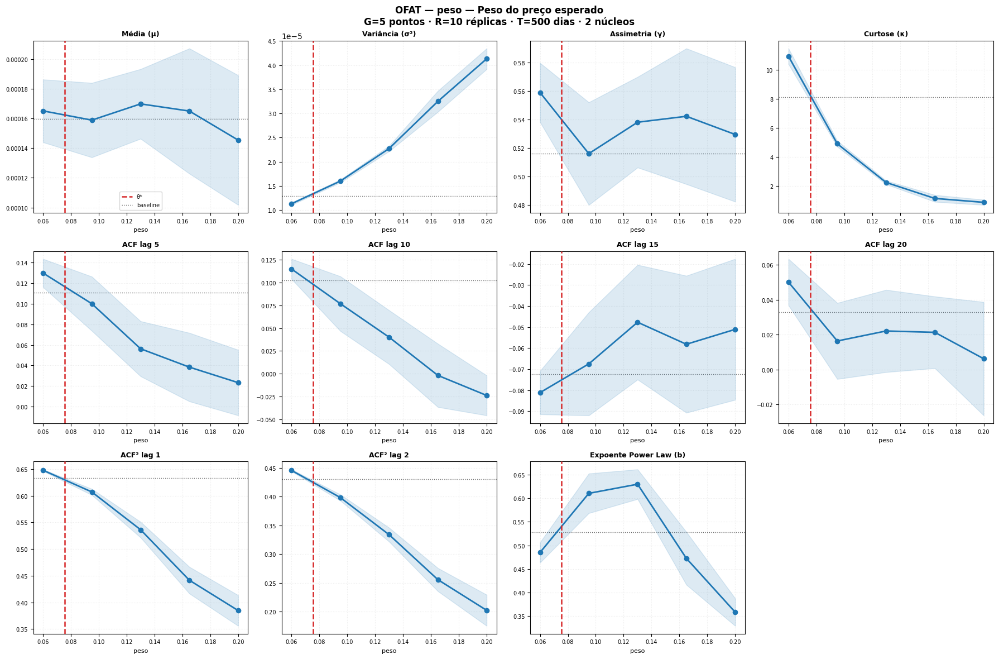

✓ Figura salva: /content/drive/MyDrive/tese_fii/ofat_results2/figures/ofat_peso.png

Δ_rel para peso:
  Output              Δ (%)       ρ  Direção
  --------------------------------------------------
  media                15.3%  -0.500  nao-monotonica
  variancia           232.6%  +1.000  crescente
  assimetria            8.3%  -0.300  nao-monotonica
  curtose             124.1%  -1.000  decrescente
  acf_lag5             96.3%  -1.000  decrescente
  acf_lag10           135.3%  -1.000  decrescente
  acf_lag15            46.3%  +0.700  nao-monotonica
  acf_lag20           133.4%  -0.700  nao-monotonica
  acf2_lag1            41.6%  -1.000  decrescente
  acf2_lag2            56.5%  -1.000  decrescente
  power_law_b          51.5%  -0.600  nao-monotonica

── Status geral ──────────────────────────
  a0      ✓ 5/5 pontos  
  b0      ✓ 5/5 pontos  
  c0      ✓ 5/5 pontos  
  beta    ✓ 5/5 pontos  
  peso    ✓ 5/5 pontos  ◄ atual
──────────────────────────────────────────

Próximo: mude PAR

In [ ]:
# ══════════════════════════════════════════════════════════════
# OFAT — UM PARÂMETRO POR VEZ (joblib paralelo)
# Versão final com todos os outputs e θ* atualizado
#
# INSTRUÇÕES:
#   1. Cole tudo em UMA célula do Colab
#   2. Mude apenas PARAM_ATUAL na linha abaixo
#   3. Execute — salva no Drive automaticamente
#   4. Quando terminar, mude para o próximo parâmetro
#
# ORDEM: 'b0' → 'a0' → 'c0' → 'beta' → 'peso'
# ══════════════════════════════════════════════════════════════

# ⚠️ MUDE AQUI A CADA RODADA ─────────────────────────────────
PARAM_ATUAL = 'peso'   # opções: 'a0' | 'b0' | 'c0' | 'beta' | 'peso'
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os, time, warnings
from scipy.stats import kurtosis, skew, t as t_dist, spearmanr
from scipy.optimize import curve_fit
from statsmodels.tsa.stattools import acf
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

# ── θ* atualizado ─────────────────────────────────────────────
THETA_STAR = {
    'a0':   parametros_sistema[0],
    'b0':   parametros_sistema[1],
    'c0':   parametros_sistema[2],
    'beta': parametros_sistema[3],
    'peso': parametros_sistema[4],
}

# ── Intervalos de Mcal ────────────────────────────────────────
MCAL = {
    'a0':   (0.50, 0.90),
    'b0':   (0.50, 0.90),
    'c0':   (0.50, 0.90),
    'beta': (0.10, 0.30),
    'peso': (0.06, 0.20),
}

# ── Outputs — consistentes com calibração e validação ─────────
OUTPUT_LABELS = {
    'media':      'Média (μ)',
    'variancia':  'Variância (σ²)',
    'assimetria': 'Assimetria (γ)',
    'curtose':    'Curtose (κ)',
    'acf_lag5':   'ACF lag 5',
    'acf_lag10':  'ACF lag 10',
    'acf_lag15':  'ACF lag 15',
    'acf_lag20':  'ACF lag 20',
    'acf2_lag1':  'ACF² lag 1',
    'acf2_lag2':  'ACF² lag 2',
    'power_law_b': 'Expoente Power Law (b)',
}

PARAM_LABELS = {
    'a0':   'a0 — Informação privada',
    'b0':   'b0 — Informação social (herding)',
    'c0':   'c0 — Notícias (mídia)',
    'beta': 'beta — Literacia financeira',
    'peso': 'peso — Peso do preço esperado',
}

N_GRID  = 5
N_REP   = 10
N_JOBS  = 2
HORIZON = 500

# ── Diretório de saída ────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    OUT_DIR = '/content/drive/MyDrive/tese_fii/ofat_results2'
except Exception:
    OUT_DIR = '/content/ofat_results2'

FIG_DIR       = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)
RESULT_FILE   = f'{OUT_DIR}/ofat_{PARAM_ATUAL}.csv'
BASELINE_FILE = f'{OUT_DIR}/baseline.csv'

sim_por_param = N_GRID * N_REP
t_est = sim_por_param * 2.56 / N_JOBS

print(f'Parâmetro : {PARAM_ATUAL}')
print(f'θ*        : {THETA_STAR}')
print(f'Grade     : {N_GRID} pontos × {N_REP} réplicas = {sim_por_param} sim.')
print(f'Núcleos   : {N_JOBS}')
print(f'Tempo est.: ~{t_est:.0f} min = {t_est/60:.1f}h')
print(f'Outputs   : {len(OUTPUT_LABELS)}')
print(f'Saída     : {RESULT_FILE}')
print()

# ── Simulador ─────────────────────────────────────────────────
sys.path.append('/content/Mercado-Artificial-Fiis')
from src.simulacao import simular_mercado_e_plotar

def run_model(a0, b0, c0, beta, peso, seed, T=HORIZON):
    np.random.seed(seed)

    # Cópia limpa do SIM_PARAMS — sem choques aleatórios
    params = copy.deepcopy(SIM_PARAMS)
    params["prob_choque_diario"] = 0.0   # OFAT sem ruído de choque
    params["choques"]            = []     # sem choques programados

    resultado = simular_mercado_e_plotar(
        parametros_sistema=[a0, b0, c0, beta, peso],
        num_dias=T,
        sim_params=params,
        imprimir=False,
    )
    ret = np.array(resultado[1])
    ret = ret[np.isfinite(ret)]
    return ret

# ── Função power law ─────────────────────────────────────────
def _power(x, a, b):
    return a / np.power(x, b)

def calcular_power_law_b(retornos, lags=40):
    """
    Calcula o expoente b da power law nos retornos absolutos.
    Replica exatamente o procedimento de plot_power_law()
    em fatos_estilizados.py.
    """
    nlags   = min(lags, len(retornos) - 2)
    acf_abs = acf(np.abs(retornos), nlags=nlags, fft=True)
    lags_arr = np.arange(1, nlags + 1)
    try:
        popt, _ = curve_fit(_power, lags_arr, acf_abs[1:],
                            p0=[1, 1], maxfev=5000)
        b = float(popt[1])
        # Filtro de sanidade — igual ao usado na validação
        if b <= 0 or b >= 3 or np.isnan(b):
            return np.nan
        return b
    except Exception:
        return np.nan

# ── Calcular todos os outputs ─────────────────────────────────
def compute_outputs(ret):
    if len(ret) < 50:
        return {k: np.nan for k in OUTPUT_LABELS}

    ret2 = ret ** 2

    try:
        acf_r  = acf(ret,  nlags=20, fft=True, missing='drop')
    except Exception:
        acf_r  = np.full(21, np.nan)

    try:
        acf_r2 = acf(ret2, nlags=2,  fft=True, missing='drop')
    except Exception:
        acf_r2 = np.full(3, np.nan)

    b = calcular_power_law_b(ret, lags=40)

    return {
        'media':       float(np.mean(ret)),
        'variancia':   float(np.var(ret)),
        'assimetria':  float(skew(ret, nan_policy='omit')),
        'curtose':     float(kurtosis(ret, fisher=True, nan_policy='omit')),
        'acf_lag5':    float(acf_r[5])  if len(acf_r) > 5  else np.nan,
        'acf_lag10':   float(acf_r[10]) if len(acf_r) > 10 else np.nan,
        'acf_lag15':   float(acf_r[15]) if len(acf_r) > 15 else np.nan,
        'acf_lag20':   float(acf_r[20]) if len(acf_r) > 20 else np.nan,
        'acf2_lag1':   float(acf_r2[1]) if len(acf_r2) > 1 else np.nan,
        'acf2_lag2':   float(acf_r2[2]) if len(acf_r2) > 2 else np.nan,
        'power_law_b': b,
    }

def aggregate(records):
    df = pd.DataFrame(records)
    out = {}
    for col in OUTPUT_LABELS:
        v = df[col].dropna().values
        if len(v) == 0:
            out[col] = dict(mean=np.nan, ci_lo=np.nan, ci_hi=np.nan)
            continue
        m  = v.mean()
        se = v.std(ddof=1) / max(len(v)**0.5, 1)
        ci = t_dist.interval(0.95, df=max(len(v)-1, 1), loc=m, scale=se)
        out[col] = dict(mean=m, ci_lo=ci[0], ci_hi=ci[1])
    return out

def rodar_replica(params, seed):
    """Uma réplica — chamada pelo joblib."""
    ret = run_model(**params, seed=seed)
    return compute_outputs(ret)

# ══════════════════════════════════════════════════════════════
# ETAPA 1 — BASELINE
# ══════════════════════════════════════════════════════════════

if os.path.exists(BASELINE_FILE):
    df_base  = pd.read_csv(BASELINE_FILE)
    baseline = {col: df_base[col].dropna().mean()
                for col in OUTPUT_LABELS}
    print(f'✓ Baseline carregado ({len(df_base)} linhas)')
else:
    print('Rodando baseline (10 réplicas em paralelo)...')
    t0    = time.time()
    seeds = [90000 + r for r in range(10)]
    recs  = Parallel(n_jobs=N_JOBS)(
        delayed(rodar_replica)(THETA_STAR, s) for s in seeds
    )
    df_base = pd.DataFrame(recs)
    df_base.to_csv(BASELINE_FILE, index=False)
    baseline = {col: df_base[col].dropna().mean()
                for col in OUTPUT_LABELS}
    print(f'✓ Baseline em {(time.time()-t0)/60:.1f} min')

print()
print('Baseline (médias):')
for k, v in baseline.items():
    print(f'  {k:14s}: {v:+.6f}')
print()

# ══════════════════════════════════════════════════════════════
# ETAPA 2 — VARREDURA OFAT
# ══════════════════════════════════════════════════════════════

# Retomar progresso se existir
if os.path.exists(RESULT_FILE):
    df_existing = pd.read_csv(RESULT_FILE)
    done_values = set(df_existing['value'].round(4).unique())
    print(f'Retomando: {len(done_values)} pontos já concluídos')
else:
    done_values = set()

lo, hi    = MCAL[PARAM_ATUAL]
grade     = np.linspace(lo, hi, N_GRID)
pendentes = [v for v in grade if round(v, 4) not in done_values]

print(f'Pontos pendentes: {len(pendentes)}/{N_GRID}')
print()

t_exp = time.time()

for idx, val in enumerate(pendentes):

    t0     = time.time()
    params = {**THETA_STAR, PARAM_ATUAL: float(val)}

    seeds = [
        abs(hash(f'{PARAM_ATUAL}_{val:.6f}_{r}')) % (2**31)
        for r in range(N_REP)
    ]

    recs = Parallel(n_jobs=N_JOBS)(
        delayed(rodar_replica)(params, s) for s in seeds
    )

    agg = aggregate(recs)

    # Montar e salvar imediatamente
    rows = []
    for oname, st in agg.items():
        rows.append({
            'param':  PARAM_ATUAL,
            'value':  round(val, 6),
            'output': oname,
            'mean':   st['mean'],
            'ci_lo':  st['ci_lo'],
            'ci_hi':  st['ci_hi'],
        })

    df_ponto = pd.DataFrame(rows)
    if os.path.exists(RESULT_FILE):
        df_ponto.to_csv(RESULT_FILE, mode='a', header=False, index=False)
    else:
        df_ponto.to_csv(RESULT_FILE, index=False)

    # Status
    t_este  = time.time() - t0
    elapsed = time.time() - t_exp
    restam  = len(pendentes) - (idx + 1)
    eta     = restam * t_este / 60

    print(f'[{idx+1:2d}/{len(pendentes)}] '
          f'{PARAM_ATUAL}={val:.4f}  '
          f'κ={agg["curtose"]["mean"]:+.3f}  '
          f'b={agg["power_law_b"]["mean"]:+.3f}  '
          f'{t_este:.0f}s  '
          f'ETA={eta:.0f}min  '
          f'total={elapsed/60:.0f}min')

print()
print(f'✓ Parâmetro {PARAM_ATUAL} concluído')

# ══════════════════════════════════════════════════════════════
# ETAPA 3 — FIGURA (grade 4×3 para 11 outputs)
# ══════════════════════════════════════════════════════════════

df_param = pd.read_csv(RESULT_FILE)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes_flat = axes.flatten()

for j, oname in enumerate(OUTPUT_LABELS):
    ax   = axes_flat[j]
    df_o = df_param[df_param['output'] == oname].sort_values('value')
    x    = df_o['value'].values
    y    = df_o['mean'].values
    clo  = df_o['ci_lo'].values
    chi  = df_o['ci_hi'].values
    base = baseline[oname]

    ax.plot(x, y, color='#1f77b4', lw=2,
            marker='o', ms=6, zorder=3)
    ax.fill_between(x, clo, chi,
                    color='#1f77b4', alpha=0.15, zorder=2)
    ax.axvline(THETA_STAR[PARAM_ATUAL], color='#d62728',
               lw=1.8, ls='--', label='θ*', zorder=4)
    ax.axhline(base, color='black', lw=1,
               ls=':', alpha=0.6, label='baseline', zorder=1)
    ax.set_title(OUTPUT_LABELS[oname], fontsize=9, fontweight='bold')
    ax.set_xlabel(PARAM_ATUAL, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25, ls=':')
    if j == 0:
        ax.legend(fontsize=7)

# Esconder painel extra (12 painéis, 11 outputs)
axes_flat[11].set_visible(False)

fig.suptitle(
    f'OFAT — {PARAM_LABELS[PARAM_ATUAL]}\n'
    f'G={N_GRID} pontos · R={N_REP} réplicas · '
    f'T={HORIZON} dias · {N_JOBS} núcleos',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
path = f'{FIG_DIR}/ofat_{PARAM_ATUAL}.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura salva: {path}')

# ══════════════════════════════════════════════════════════════
# ETAPA 4 — Δ_rel e direção
# ══════════════════════════════════════════════════════════════

print()
print(f'Δ_rel para {PARAM_ATUAL}:')
print(f'  {"Output":16s}  {"Δ (%)":>7s}  {"ρ":>6s}  Direção')
print(f'  {"-"*50}')

summary_rows = []
for oname in OUTPUT_LABELS:
    df_o  = df_param[df_param['output'] == oname].sort_values('value')
    y     = df_o['mean'].dropna().values
    if len(y) < 2:
        continue
    base  = baseline[oname]
    delta = (y.max() - y.min()) / (abs(base) + 1e-12)
    rho, pval = spearmanr(range(len(y)), y)
    if pval < 0.05 and abs(rho) >= 0.6:
        direcao = 'crescente' if rho > 0 else 'decrescente'
    else:
        direcao = 'nao-monotonica'
    print(f'  {oname:16s}  {delta*100:7.1f}%  {rho:+.3f}  {direcao}')
    summary_rows.append(dict(
        param=PARAM_ATUAL, output=oname,
        delta_pct=round(delta*100, 2),
        direcao=direcao,
        rho=round(rho, 4), pval=round(pval, 4),
        baseline=round(base, 8),
        y_min=round(y.min(), 8),
        y_max=round(y.max(), 8),
    ))

# Salvar resumo deste parâmetro
df_sum = pd.DataFrame(summary_rows)
df_sum.to_csv(f'{OUT_DIR}/ofat_summary_{PARAM_ATUAL}.csv', index=False)

# ══════════════════════════════════════════════════════════════
# CHECKLIST GERAL
# ══════════════════════════════════════════════════════════════

print()
print('── Status geral ──────────────────────────')
for p in ['a0', 'b0', 'c0', 'beta', 'peso']:
    f = f'{OUT_DIR}/ofat_{p}.csv'
    if os.path.exists(f):
        n = len(pd.read_csv(f)['value'].unique())
        status = f'✓ {n}/{N_GRID} pontos'
    else:
        status = '○ pendente'
    marker = '◄ atual' if p == PARAM_ATUAL else ''
    print(f'  {p:6s}  {status}  {marker}')
print('──────────────────────────────────────────')
print()
print('Próximo: mude PARAM_ATUAL e rode novamente')

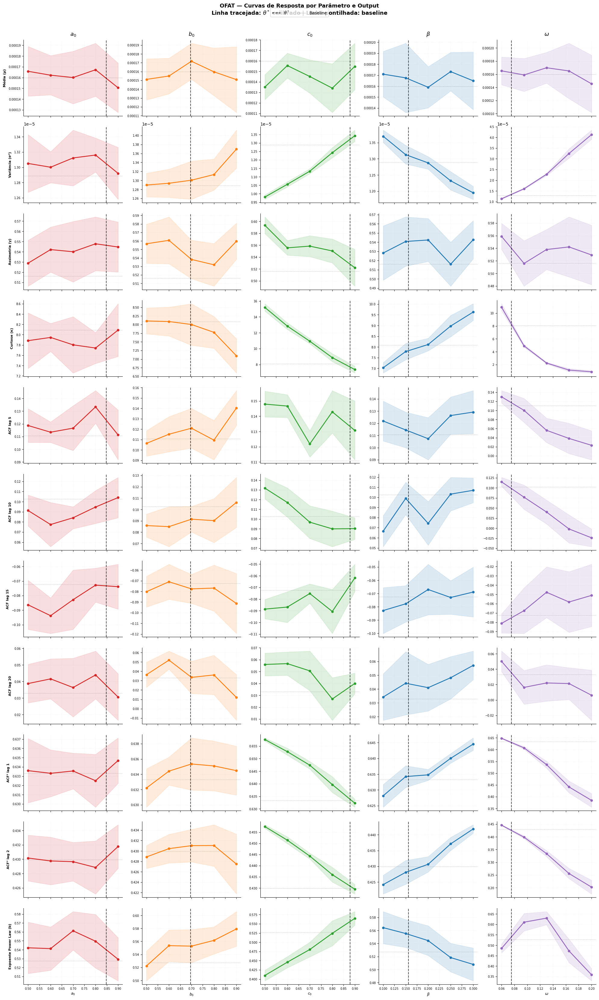

✓ Figura salva: /content/drive/MyDrive/tese_fii/ofat_results2/figures/ofat_grid_11x5.png


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Carregar todos os CSVs ────────────────────────────────────
PARAMS = ['a0', 'b0', 'c0', 'beta', 'peso']

dfs = {}
for p in PARAMS:
    dfs[p] = pd.read_csv(f'{OUT_DIR}/ofat_{p}.csv')

# Carregar baseline
df_base  = pd.read_csv(BASELINE_FILE)
baseline = {col: df_base[col].dropna().mean() for col in OUTPUT_LABELS}

OUTPUTS = list(OUTPUT_LABELS.keys())

PARAM_LABELS_SHORT = {
    'a0':   r'$a_0$',
    'b0':   r'$b_0$',
    'c0':   r'$c_0$',
    'beta': r'$\beta$',
    'peso': r'$\omega$',
}
CORES_PARAMS = {
    'a0':   '#d62728',
    'b0':   '#ff7f0e',
    'c0':   '#2ca02c',
    'beta': '#1f77b4',
    'peso': '#9467bd',
}

# ── Figura 11 × 5 ─────────────────────────────────────────────
fig, axes = plt.subplots(
    len(OUTPUTS), len(PARAMS),
    figsize=(20, 33),
    sharex='col'
)

for col, param in enumerate(PARAMS):
    df_p   = dfs[param]
    cor    = CORES_PARAMS[param]
    theta  = THETA_STAR[param]

    for row, oname in enumerate(OUTPUTS):
        ax   = axes[row, col]
        df_o = df_p[df_p['output'] == oname].sort_values('value')
        x    = df_o['value'].values
        y    = df_o['mean'].values
        clo  = df_o['ci_lo'].values
        chi  = df_o['ci_hi'].values
        base = baseline[oname]

        ax.plot(x, y, color=cor, lw=2,
                marker='o', ms=5, zorder=3)
        ax.fill_between(x, clo, chi,
                        color=cor, alpha=0.15, zorder=2)
        ax.axvline(theta, color='black',
                   lw=1.5, ls='--', alpha=0.7, zorder=4)
        ax.axhline(base, color='gray',
                   lw=1.0, ls=':', alpha=0.6, zorder=1)

        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.2, ls=':')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Rótulo do output — só na primeira coluna
        if col == 0:
            ax.set_ylabel(OUTPUT_LABELS[oname], fontsize=8,
                          fontweight='bold', labelpad=6)

        # Rótulo do parâmetro — só na primeira linha
        if row == 0:
            ax.set_title(PARAM_LABELS_SHORT[param],
                         fontsize=13, fontweight='bold', pad=10)

        # Rótulo do eixo X — só na última linha
        if row == len(OUTPUTS) - 1:
            ax.set_xlabel(PARAM_LABELS_SHORT[param], fontsize=9)

# Legenda global
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color='black', lw=1.5, ls='--', label=r'$\theta^*$'),
    Line2D([0], [0], color='gray',  lw=1.0, ls=':',  label='Baseline'),
]
fig.legend(handles=handles, loc='upper center',
           ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, 1.002))

fig.suptitle(
    'OFAT — Curvas de Resposta por Parâmetro e Output\n'
    r'Linha tracejada: $\theta^*$ calibrado | Linha pontilhada: baseline',
    fontsize=13, fontweight='bold', y=1.005
)

plt.tight_layout()
path = f'{FIG_DIR}/ofat_grid_11x5.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura salva: {path}')

# Correlação por FE

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carregando dados...
  ✓ a0: 55 linhas
  ✓ b0: 55 linhas
  ✓ c0: 55 linhas
  ✓ beta: 55 linhas
  ✓ peso: 55 linhas

Calculando correlações de Spearman...
✓ Correlações calculadas


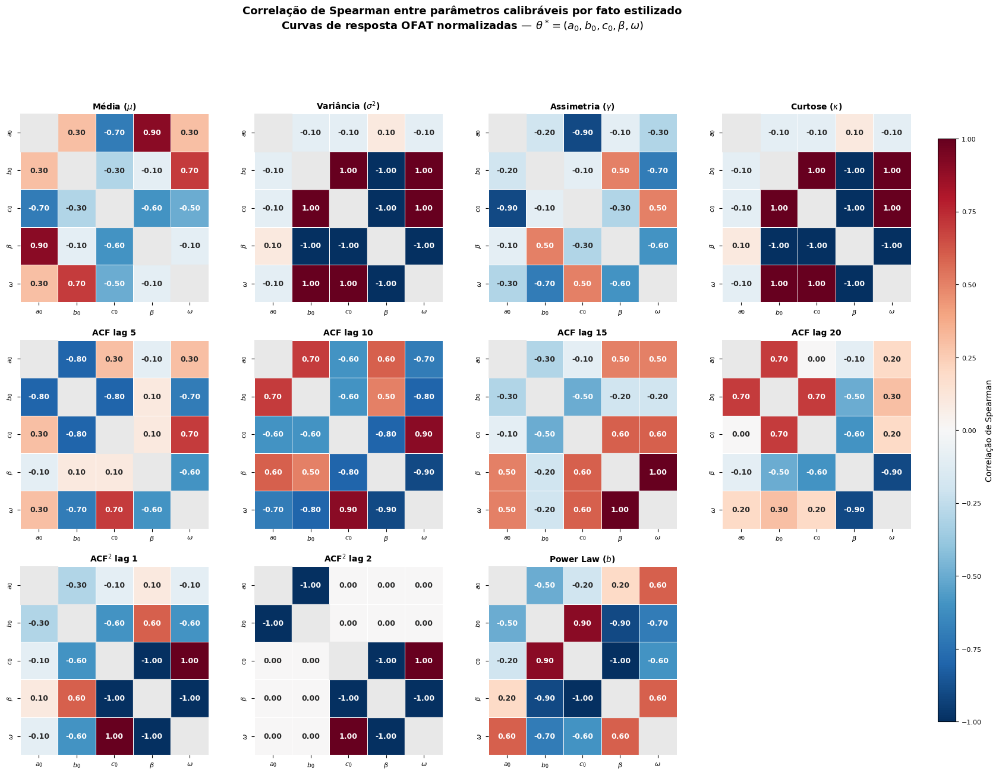

✓ Figura 1 salva: /content/drive/MyDrive/tese_fii/ofat_results2/figures/correlacao_parametros_por_output.png


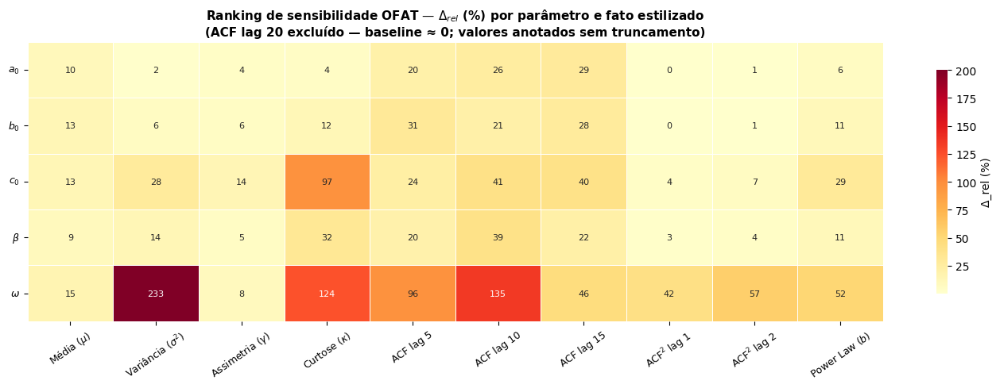

✓ Figura 2 salva: /content/drive/MyDrive/tese_fii/ofat_results2/figures/ranking_delta_rel.png


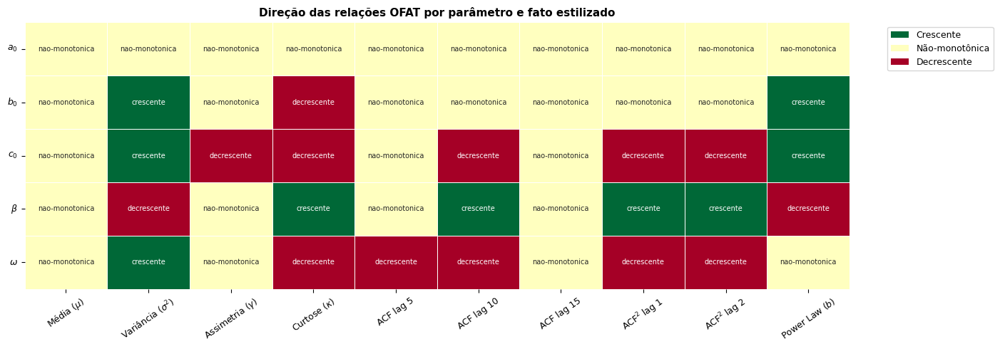

✓ Figura 3 salva: /content/drive/MyDrive/tese_fii/ofat_results2/figures/mapa_direcoes.png

Correlação média entre parâmetros (todos os outputs):
          $a_0$  $b_0$  $c_0$  $\beta$  $\omega$
$a_0$     1.000 -0.145 -0.227    0.200     0.055
$b_0$    -0.145  1.000  0.064   -0.182    -0.064
$c_0$    -0.227  0.064  1.000   -0.600     0.527
$\beta$   0.200 -0.182 -0.600    1.000    -0.500
$\omega$  0.055 -0.064  0.527   -0.500     1.000

══════════════════════════════════════════
  ✓ ANÁLISE DE CORRELAÇÃO CONCLUÍDA
  Figuras em: /content/drive/MyDrive/tese_fii/ofat_results2/figures
══════════════════════════════════════════


In [ ]:
# ══════════════════════════════════════════════════════════════
# CORRELAÇÃO ENTRE PARÂMETROS CALIBRÁVEIS POR FATO ESTILIZADO
# Seção 7.3.7 da tese
# ══════════════════════════════════════════════════════════════

import os
import sys
import types
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

OUT_DIR = '/content/drive/MyDrive/tese_fii/ofat_results2'
FIG_DIR = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

# ── Configurações ─────────────────────────────────────────────
PARAMS = ['a0', 'b0', 'c0', 'beta', 'peso']

PARAM_LABELS = {
    'a0':   r'$a_0$',
    'b0':   r'$b_0$',
    'c0':   r'$c_0$',
    'beta': r'$\beta$',
    'peso': r'$\omega$',
}

OUTPUTS = [
    'media', 'variancia', 'assimetria', 'curtose',
    'acf_lag5', 'acf_lag10', 'acf_lag15', 'acf_lag20',
    'acf2_lag1', 'acf2_lag2', 'power_law_b'
]

OUTPUT_LABELS = {
    'media':       r'Média ($\mu$)',
    'variancia':   r'Variância ($\sigma^2$)',
    'assimetria':  r'Assimetria ($\gamma$)',
    'curtose':     r'Curtose ($\kappa$)',
    'acf_lag5':    r'ACF lag 5',
    'acf_lag10':   r'ACF lag 10',
    'acf_lag15':   r'ACF lag 15',
    'acf_lag20':   r'ACF lag 20',
    'acf2_lag1':   r'ACF$^2$ lag 1',
    'acf2_lag2':   r'ACF$^2$ lag 2',
    'power_law_b': r'Power Law ($b$)',
}

# ── Carregar CSVs ─────────────────────────────────────────────
print('Carregando dados...')
dfs = {}
for p in PARAMS:
    path = f'{OUT_DIR}/ofat_{p}.csv'
    if os.path.exists(path):
        dfs[p] = pd.read_csv(path)
        print(f'  ✓ {p}: {len(dfs[p])} linhas')
    else:
        print(f'  ✗ {p}: arquivo não encontrado')

# ── Calcular correlações ──────────────────────────────────────
print('\nCalculando correlações de Spearman...')

# Para cada output: extrai vetor normalizado de cada parâmetro
# e calcula correlação entre todos os pares

corr_matrices = {}     # correlação entre parâmetros por output
delta_matrix  = pd.DataFrame(index=PARAMS,
                              columns=OUTPUTS,
                              dtype=float)
dir_matrix    = pd.DataFrame(index=PARAMS,
                              columns=OUTPUTS,
                              dtype=str)

for oname in OUTPUTS:
    vetores = {}
    for p in PARAMS:
        if p not in dfs:
            continue
        df_o = (dfs[p][dfs[p]['output'] == oname]
                .sort_values('value'))
        y = df_o['mean'].dropna().values
        if len(y) < 2:
            continue

        # Normalizar para [0,1] — torna curvas comparáveis
        ymin, ymax = y.min(), y.max()
        if ymax - ymin > 1e-12:
            y_norm = (y - ymin) / (ymax - ymin)
        else:
            y_norm = np.zeros_like(y)
        vetores[p] = y_norm

        # Δ_rel
        base_path = f'{OUT_DIR}/ofat_summary_{p}.csv'
        if os.path.exists(base_path):
            df_s = pd.read_csv(base_path)
            row  = df_s[df_s['output'] == oname]
            if not row.empty:
                delta_matrix.loc[p, oname] = row['delta_pct'].values[0]
                dir_matrix.loc[p, oname]   = row['direcao'].values[0]

    # Matriz de correlação entre parâmetros
    params_ok = list(vetores.keys())
    n = len(params_ok)
    mat = np.full((n, n), np.nan)

    for i, p1 in enumerate(params_ok):
        for j, p2 in enumerate(params_ok):
            if i == j:
                mat[i, j] = 1.0
            else:
                v1 = vetores[p1]
                v2 = vetores[p2]
                # Interpolar se tamanhos diferentes
                if len(v1) != len(v2):
                    x1 = np.linspace(0, 1, len(v1))
                    x2 = np.linspace(0, 1, len(v2))
                    v2 = np.interp(x1, x2, v2)
                rho, _ = spearmanr(v1, v2)
                mat[i, j] = rho

    corr_matrices[oname] = pd.DataFrame(
        mat,
        index=[PARAM_LABELS[p] for p in params_ok],
        columns=[PARAM_LABELS[p] for p in params_ok]
    )

print('✓ Correlações calculadas')

# ══════════════════════════════════════════════════════════════
# FIGURA 1 — Heatmaps de correlação por output (3×4 grade)
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes_flat = axes.flatten()

for idx, oname in enumerate(OUTPUTS):
    ax  = axes_flat[idx]
    mat = corr_matrices[oname]

    mask = np.zeros_like(mat.values, dtype=bool)
    np.fill_diagonal(mask, True)

    sns.heatmap(
        mat,
        ax=ax,
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        annot=True, fmt='.2f',
        annot_kws={'size': 9, 'weight': 'bold'},
        square=True,
        linewidths=0.5,
        linecolor='white',
        cbar=False,
        mask=mask
    )
    # Diagonal cinza
    for k in range(len(mat)):
        ax.add_patch(plt.Rectangle(
            (k, k), 1, 1,
            fill=True, color='#e8e8e8',
            transform=ax.transData
        ))

    ax.set_title(OUTPUT_LABELS[oname],
                 fontsize=10, fontweight='bold', pad=6)
    ax.tick_params(labelsize=8)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Colorbar global
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(
    cmap='RdBu_r',
    norm=plt.Normalize(vmin=-1, vmax=1)
)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Correlação de Spearman', fontsize=10)
cbar.ax.tick_params(labelsize=8)

# Esconder painel extra
axes_flat[11].set_visible(False)

fig.suptitle(
    'Correlação de Spearman entre parâmetros calibráveis por fato estilizado\n'
    r'Curvas de resposta OFAT normalizadas — $\theta^* = (a_0, b_0, c_0, \beta, \omega)$',
    fontsize=13, fontweight='bold', y=1.01
)

path = f'{FIG_DIR}/correlacao_parametros_por_output.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura 1 salva: {path}')

# ══════════════════════════════════════════════════════════════
# FIGURA 2 — Δ_rel: ranking de sensibilidade (heatmap)
# ══════════════════════════════════════════════════════════════

# Filtrar ACF lag 20 do ranking (baseline≈0, Δ_rel inflado)
outputs_ranking = [o for o in OUTPUTS if o != 'acf_lag20']
delta_plot = delta_matrix[outputs_ranking].astype(float)

# Clipar valores inflados para visualização
DELTA_MAX = 200
delta_plot_clipped = delta_plot.clip(upper=DELTA_MAX)

fig2, ax2 = plt.subplots(figsize=(14, 5))

sns.heatmap(
    delta_plot_clipped,
    ax=ax2,
    cmap='YlOrRd',
    annot=delta_plot.values,
    fmt='.0f',
    annot_kws={'size': 8},
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Δ_rel (%)', 'shrink': 0.8},
    xticklabels=[OUTPUT_LABELS[o] for o in outputs_ranking],
    yticklabels=[PARAM_LABELS[p] for p in PARAMS],
)

ax2.set_title(
    r'Ranking de sensibilidade OFAT — $\Delta_{rel}$ (%) por parâmetro e fato estilizado'
    '\n(ACF lag 20 excluído — baseline ≈ 0; valores anotados sem truncamento)',
    fontsize=11, fontweight='bold'
)
ax2.tick_params(axis='x', rotation=35, labelsize=9)
ax2.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
path2 = f'{FIG_DIR}/ranking_delta_rel.png'
fig2.savefig(path2, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura 2 salva: {path2}')

# ══════════════════════════════════════════════════════════════
# FIGURA 3 — Mapa de direções (crescente / decrescente / não-mon.)
# ══════════════════════════════════════════════════════════════

dir_plot = dir_matrix[outputs_ranking].copy()

# Mapear direções para valores numéricos
dir_num = dir_plot.applymap(lambda x:
     1 if x == 'crescente'
    else -1 if x == 'decrescente'
    else 0
)

fig3, ax3 = plt.subplots(figsize=(14, 5))

cmap_dir = plt.cm.get_cmap('RdYlGn', 3)
sns.heatmap(
    dir_num.astype(float),
    ax=ax3,
    cmap=cmap_dir,
    vmin=-1.5, vmax=1.5,
    annot=dir_plot.values,
    fmt='',
    annot_kws={'size': 7},
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    xticklabels=[OUTPUT_LABELS[o] for o in outputs_ranking],
    yticklabels=[PARAM_LABELS[p] for p in PARAMS],
)

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=cmap_dir(0.83), label='Crescente'),
    Patch(facecolor=cmap_dir(0.50), label='Não-monotônica'),
    Patch(facecolor=cmap_dir(0.17), label='Decrescente'),
]
ax3.legend(handles=legend_elements,
           loc='upper right',
           bbox_to_anchor=(1.18, 1.0),
           fontsize=9)

ax3.set_title(
    'Direção das relações OFAT por parâmetro e fato estilizado',
    fontsize=11, fontweight='bold'
)
ax3.tick_params(axis='x', rotation=35, labelsize=9)
ax3.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
path3 = f'{FIG_DIR}/mapa_direcoes.png'
fig3.savefig(path3, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Figura 3 salva: {path3}')

# ══════════════════════════════════════════════════════════════
# TABELA — Correlações médias por par de parâmetros
# ══════════════════════════════════════════════════════════════

print('\nCorrelação média entre parâmetros (todos os outputs):')
labels = [PARAM_LABELS[p] for p in PARAMS]
media_corr = np.zeros((len(PARAMS), len(PARAMS)))

for i, p1 in enumerate(PARAMS):
    for j, p2 in enumerate(PARAMS):
        if i == j:
            media_corr[i, j] = 1.0
            continue
        rhos = []
        for oname in OUTPUTS:
            if oname in corr_matrices:
                mat = corr_matrices[oname]
                l1  = PARAM_LABELS[p1]
                l2  = PARAM_LABELS[p2]
                if l1 in mat.index and l2 in mat.columns:
                    v = mat.loc[l1, l2]
                    if not np.isnan(v):
                        rhos.append(v)
        media_corr[i, j] = np.mean(rhos) if rhos else np.nan

df_media = pd.DataFrame(
    media_corr,
    index=labels,
    columns=labels
)
print(df_media.round(3).to_string())
df_media.to_csv(f'{OUT_DIR}/correlacao_media_parametros.csv')

print()
print('══════════════════════════════════════════')
print('  ✓ ANÁLISE DE CORRELAÇÃO CONCLUÍDA')
print(f'  Figuras em: {FIG_DIR}')
print('══════════════════════════════════════════')

# PCA e curvas 3D

Shape total: (275, 6)
Outputs: ['media', 'variancia', 'assimetria', 'curtose', 'acf_lag5', 'acf_lag10', 'acf_lag15', 'acf_lag20', 'acf2_lag1', 'acf2_lag2', 'power_law_b']

Shape pivot: (25, 13)
NaNs: 0
Shape após dropna: (25, 13)

Variância explicada:
  PC1: 62.5%
  PC2: 19.4%
  Total: 81.9%


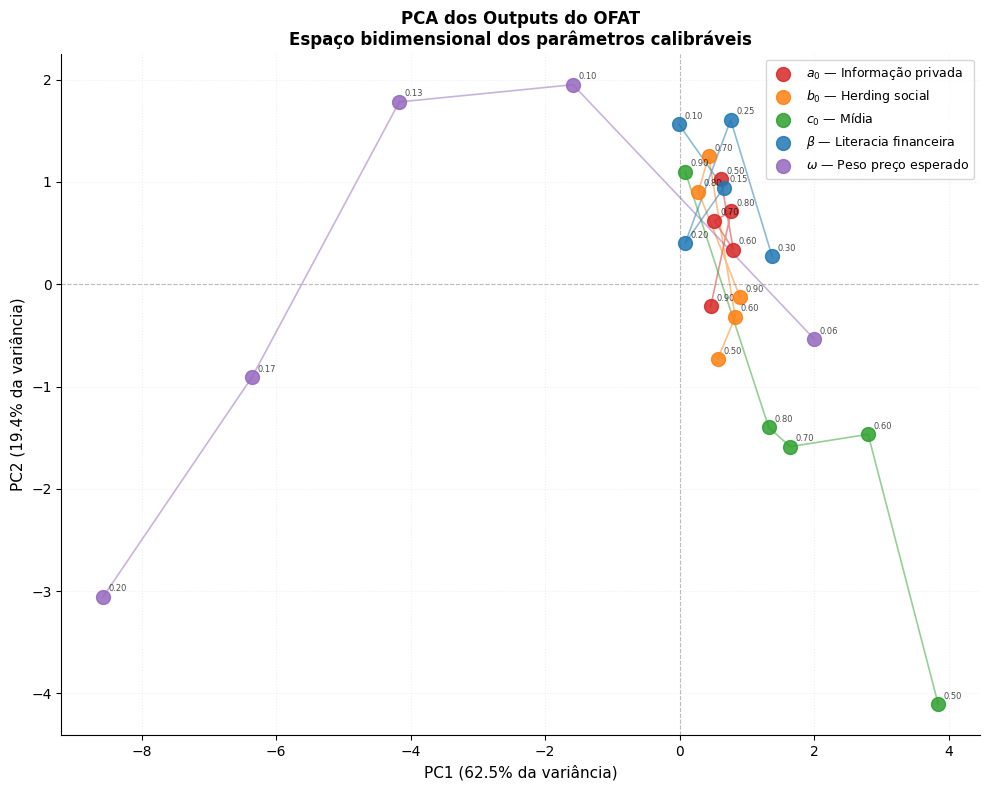

✓ Scatter PCA salvo: /content/drive/MyDrive/tese_fii/ofat_results2/figures/pca_scatter.png


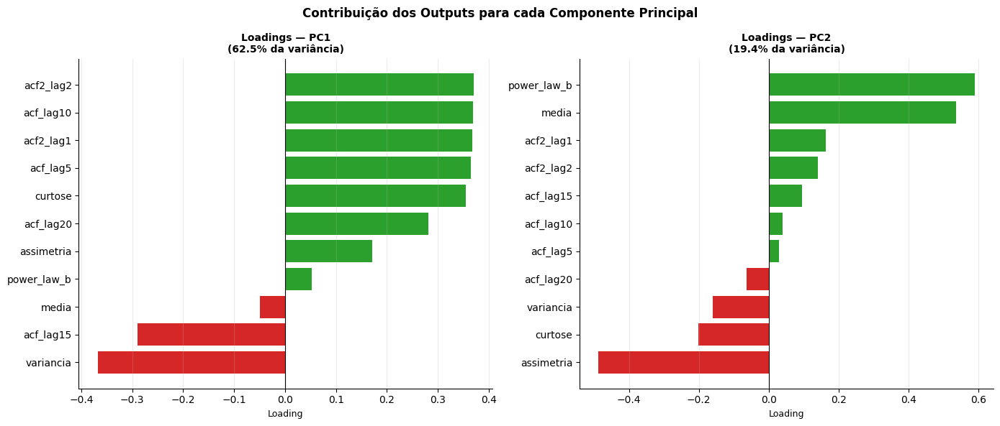

✓ Loadings PCA salvo: /content/drive/MyDrive/tese_fii/ofat_results2/figures/pca_loadings.png


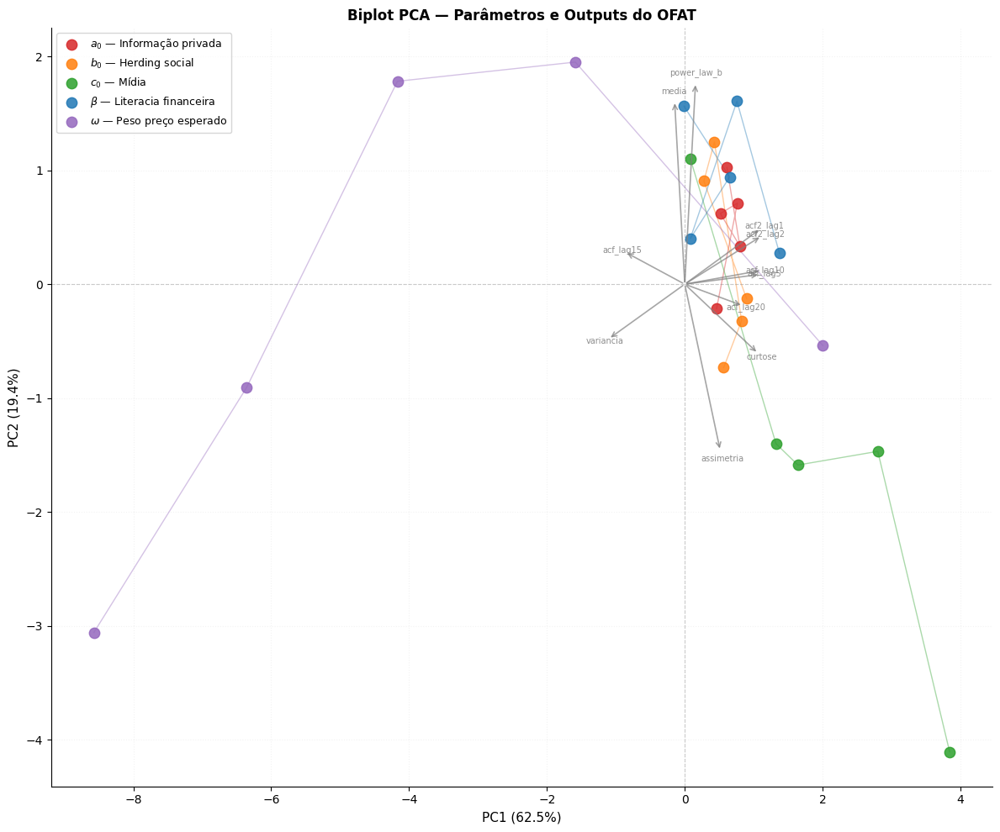

✓ Biplot PCA salvo: /content/drive/MyDrive/tese_fii/ofat_results2/figures/pca_biplot.png

Loadings por output:
                PC1     PC2
acf2_lag1    0.3675  0.1624
acf2_lag2    0.3708  0.1407
acf_lag10    0.3685  0.0400
acf_lag15   -0.2892  0.0943
acf_lag20    0.2810 -0.0631
acf_lag5     0.3652  0.0288
assimetria   0.1717 -0.4874
curtose      0.3544 -0.2023
media       -0.0491  0.5359
power_law_b  0.0521  0.5893
variancia   -0.3679 -0.1600


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ── Carregar todos os arquivos OFAT ──────────────────────────
OUT_DIR_OFAT = '/content/drive/MyDrive/tese_fii/ofat_results2'

PARAMS = ['a0', 'b0', 'c0', 'beta', 'peso']
CORES_PARAMS = {
    'a0':   '#d62728',
    'b0':   '#ff7f0e',
    'c0':   '#2ca02c',
    'beta': '#1f77b4',
    'peso': '#9467bd',
}
LABELS_PARAMS = {
    'a0':   r'$a_0$ — Informação privada',
    'b0':   r'$b_0$ — Herding social',
    'c0':   r'$c_0$ — Mídia',
    'beta': r'$\beta$ — Literacia financeira',
    'peso': r'$\omega$ — Peso preço esperado',
}

dfs = []
for p in PARAMS:
    f = f'{OUT_DIR_OFAT}/ofat_{p}.csv'
    df = pd.read_csv(f)
    dfs.append(df)

df_ofat = pd.concat(dfs, ignore_index=True)
print(f"Shape total: {df_ofat.shape}")
print(f"Outputs: {df_ofat['output'].unique().tolist()}")

# ── Montar matriz (pontos × outputs) ─────────────────────────
pivot = df_ofat.pivot_table(
    index=['param', 'value'],
    columns='output',
    values='mean'
).reset_index()

print(f"\nShape pivot: {pivot.shape}")
print(f"NaNs: {pivot.isna().sum().sum()}")
pivot = pivot.dropna()
print(f"Shape após dropna: {pivot.shape}")

# ── PCA ───────────────────────────────────────────────────────
output_cols = [c for c in pivot.columns if c not in ['param', 'value']]
X           = pivot[output_cols].values

scaler = StandardScaler()
X_std  = scaler.fit_transform(X)

pca    = PCA(n_components=2)
X_pca  = pca.fit_transform(X_std)

pivot['PC1'] = X_pca[:, 0]
pivot['PC2'] = X_pca[:, 1]

print(f"\nVariância explicada:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# ── FIGURA 1 — Scatter PC1 × PC2 colorido por parâmetro ──────
fig, ax = plt.subplots(figsize=(10, 8))

for p in PARAMS:
    df_p = pivot[pivot['param'] == p]
    sc = ax.scatter(df_p['PC1'], df_p['PC2'],
                    color=CORES_PARAMS[p], s=100,
                    label=LABELS_PARAMS[p], zorder=3, alpha=0.85)

    # Conectar pontos na ordem da grade
    df_p_sorted = df_p.sort_values('value')
    ax.plot(df_p_sorted['PC1'], df_p_sorted['PC2'],
            color=CORES_PARAMS[p], lw=1.2, alpha=0.5, zorder=2)

    # Anotar valor do parâmetro
    for _, row in df_p_sorted.iterrows():
        ax.annotate(f"{row['value']:.2f}",
                    (row['PC1'], row['PC2']),
                    fontsize=6, alpha=0.7,
                    xytext=(4, 4), textcoords='offset points')

ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)",
              fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)",
              fontsize=11)
ax.set_title('PCA dos Outputs do OFAT\n'
             'Espaço bidimensional dos parâmetros calibráveis',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.2, ls=':')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
path = f'{OUT_DIR_OFAT}/figures/pca_scatter.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Scatter PCA salvo: {path}')

# ── FIGURA 2 — Loadings (contribuição de cada output) ────────
loadings = pd.DataFrame(
    pca.components_.T,
    index=output_cols,
    columns=['PC1', 'PC2']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for j, pc in enumerate(['PC1', 'PC2']):
    ax  = axes[j]
    df_l = loadings[pc].sort_values()
    cores = ['#d62728' if v < 0 else '#2ca02c' for v in df_l]
    ax.barh(df_l.index, df_l.values, color=cores)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'Loadings — {pc}\n'
                 f'({pca.explained_variance_ratio_[j]*100:.1f}% da variância)',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Loading', fontsize=9)
    ax.grid(True, alpha=0.25, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Contribuição dos Outputs para cada Componente Principal',
             fontsize=12, fontweight='bold')
plt.tight_layout()
path = f'{OUT_DIR_OFAT}/figures/pca_loadings.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Loadings PCA salvo: {path}')

# ── FIGURA 3 — Biplot ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))

# Pontos
for p in PARAMS:
    df_p = pivot[pivot['param'] == p].sort_values('value')
    ax.scatter(df_p['PC1'], df_p['PC2'],
               color=CORES_PARAMS[p], s=80,
               label=LABELS_PARAMS[p], zorder=3, alpha=0.85)
    ax.plot(df_p['PC1'], df_p['PC2'],
            color=CORES_PARAMS[p], lw=1.0, alpha=0.4)

# Vetores de loading
scale = 3.0
for output in output_cols:
    lx = loadings.loc[output, 'PC1'] * scale
    ly = loadings.loc[output, 'PC2'] * scale
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='gray',
                                lw=1.2, alpha=0.7))
    ax.text(lx * 1.05, ly * 1.05, output,
            fontsize=7, color='gray', alpha=0.9,
            ha='center', va='center')

ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.4)
ax.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.4)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
ax.set_title('Biplot PCA — Parâmetros e Outputs do OFAT',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.15, ls=':')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
path = f'{OUT_DIR_OFAT}/figures/pca_biplot.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Biplot PCA salvo: {path}')

# ── Tabela de loadings ────────────────────────────────────────
print("\nLoadings por output:")
print(loadings.round(4).to_string())

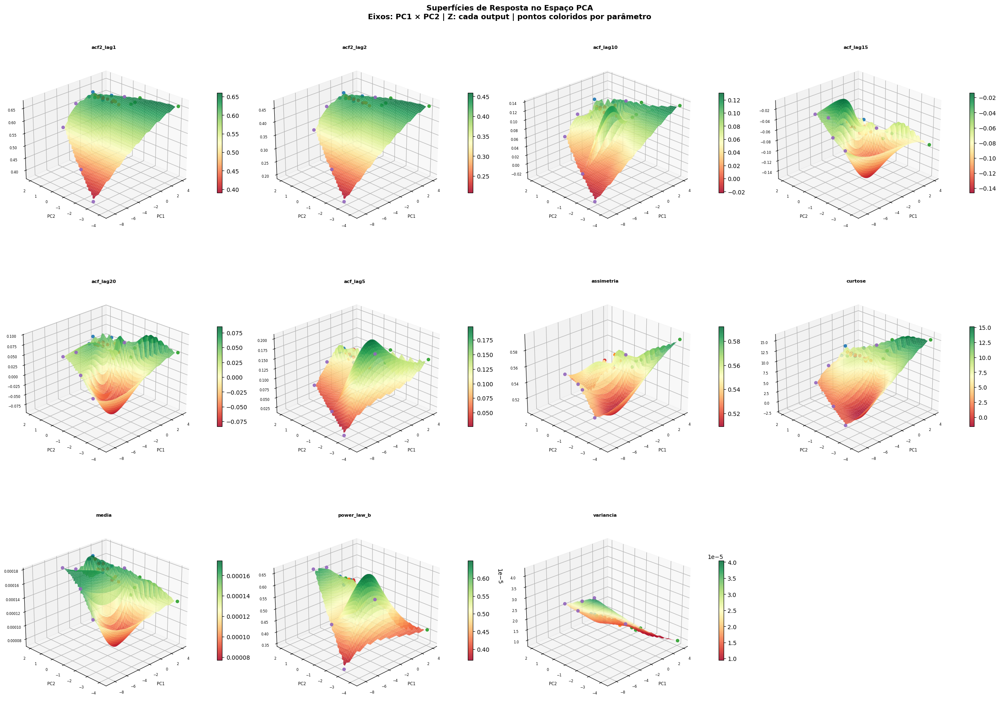

✓ Superfície 3D PCA salva: /content/drive/MyDrive/tese_fii/ofat_results2/figures/pca_superficie_3d.png


In [ ]:
from scipy.interpolate import RectBivariateSpline, griddata

# ── Preparar dados ────────────────────────────────────────────
# PC1 e PC2 como coordenadas, cada output como Z

fig, axes = plt.subplots(3, 4, figsize=(24, 18),
                         subplot_kw={'projection': '3d'})
axes_flat = axes.flatten()

for j, output in enumerate(output_cols):
    ax = axes_flat[j]

    x = pivot['PC1'].values
    y = pivot['PC2'].values
    z = pivot[output].values

    # Grade regular para interpolação
    x_fine = np.linspace(x.min(), x.max(), 50)
    y_fine = np.linspace(y.min(), y.max(), 50)
    X, Y   = np.meshgrid(x_fine, y_fine)

    # griddata com método cúbico (pontos irregulares)
    Z = griddata((x, y), z, (X, Y), method='cubic')

    # Plot superfície
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlGn',
                           alpha=0.85, edgecolor='none')

    # Pontos originais coloridos por parâmetro
    for p in PARAMS:
        df_p = pivot[pivot['param'] == p]
        ax.scatter(df_p['PC1'], df_p['PC2'],
                   df_p[output],
                   color=CORES_PARAMS[p], s=25,
                   zorder=5, alpha=0.9)

    fig.colorbar(surf, ax=ax, shrink=0.4, pad=0.1)
    ax.set_xlabel('PC1', fontsize=7, labelpad=4)
    ax.set_ylabel('PC2', fontsize=7, labelpad=4)
    ax.set_zlabel('', fontsize=6)
    ax.set_title(output, fontsize=8, fontweight='bold', pad=8)
    ax.tick_params(labelsize=6)
    ax.view_init(elev=25, azim=225)

# Esconder painéis extras
for j in range(len(output_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Superfícies de Resposta no Espaço PCA\n'
    r'Eixos: PC1 × PC2 | Z: cada output | pontos coloridos por parâmetro',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
path = f'{OUT_DIR_OFAT}/figures/pca_superficie_3d.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Superfície 3D PCA salva: {path}')

In [ ]:
OUTPUT_LABELS = {
    'media':       'Média (μ)',
    'variancia':   'Volatilidade anualizada (σ√252)',
    'assimetria':  'Assimetria (γ)',
    'curtose':     'Curtose (κ)',
    'acf_lag5':    'ACF lag 5',
    'acf_lag10':   'ACF lag 10',
    'acf_lag15':   'ACF lag 15',
    'acf_lag20':   'ACF lag 20',
    'acf2_lag1':   'ACF² lag 1',
    'acf2_lag2':   'ACF² lag 2',
    'power_law_b': 'Power Law (b)',
}

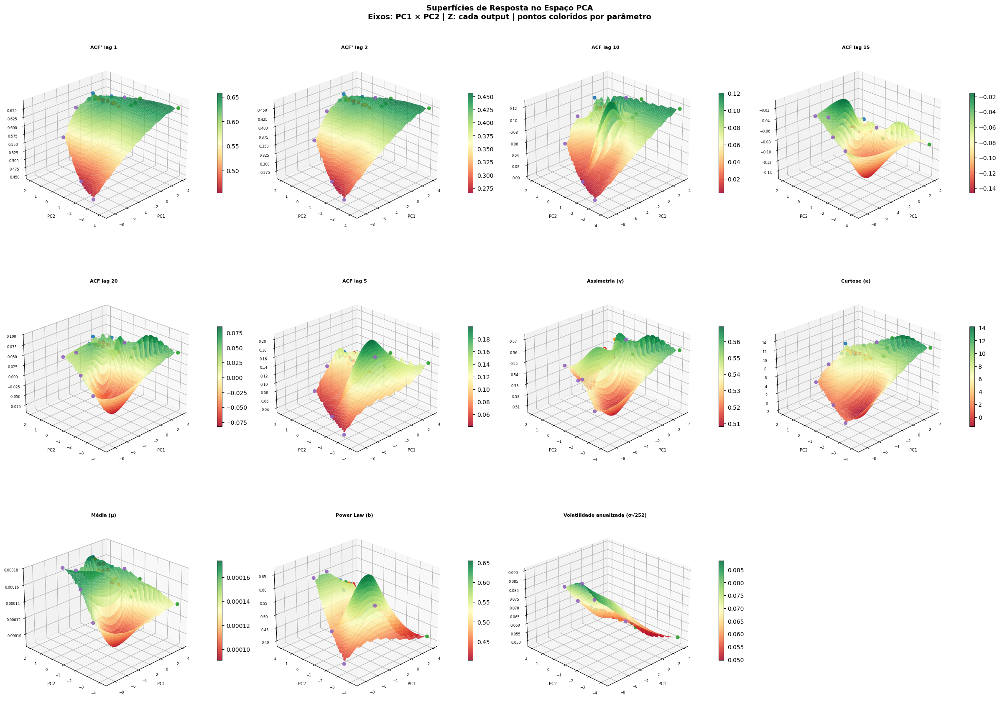

✓ Superfície 3D PCA v2 salva: /content/drive/MyDrive/tese_fii/ofat_results2/figures/pca_superficie_3d_v2.png


In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(24, 18),
                         subplot_kw={'projection': '3d'})
axes_flat = axes.flatten()

for j, output in enumerate(output_cols):
    ax = axes_flat[j]

    x = pivot['PC1'].values
    y = pivot['PC2'].values
    z = pivot[output].values

    # Converter variância → DP anualizado
    if output == 'variancia':
        z = np.sqrt(z * 252)

    # Remover outliers extremos (curtose)
    z_clip = np.clip(z, np.percentile(z, 5), np.percentile(z, 95))

    x_fine = np.linspace(x.min(), x.max(), 50)
    y_fine = np.linspace(y.min(), y.max(), 50)
    X, Y   = np.meshgrid(x_fine, y_fine)
    Z      = griddata((x, y), z_clip, (X, Y), method='cubic')

    surf = ax.plot_surface(X, Y, Z, cmap='RdYlGn',
                           alpha=0.85, edgecolor='none')

    # Pontos projetados NA superfície (z interpolado)
    for p in PARAMS:
        df_p  = pivot[pivot['param'] == p]
        z_p   = df_p[output].values
        if output == 'variancia':
            z_p = np.sqrt(z_p * 252)
        z_p = np.clip(z_p, np.percentile(z, 5), np.percentile(z, 95))
        ax.scatter(df_p['PC1'], df_p['PC2'], z_p,
                   color=CORES_PARAMS[p], s=30,
                   zorder=5, alpha=0.9)

    fig.colorbar(surf, ax=ax, shrink=0.4, pad=0.1)
    ax.set_xlabel('PC1', fontsize=7, labelpad=4)
    ax.set_ylabel('PC2', fontsize=7, labelpad=4)

    # Label formatado
    label = OUTPUT_LABELS.get(output, output)
    ax.set_title(label, fontsize=8, fontweight='bold', pad=8)
    ax.tick_params(labelsize=6)
    ax.view_init(elev=25, azim=225)

for j in range(len(output_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Superfícies de Resposta no Espaço PCA\n'
    r'Eixos: PC1 × PC2 | Z: cada output | pontos coloridos por parâmetro',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
path = f'{OUT_DIR_OFAT}/figures/pca_superficie_3d_v2.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'✓ Superfície 3D PCA v2 salva: {path}')

# Tornado Plot

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 1. MATRIZ DE VARIAÇÕES RELATIVAS (Δ_rel) ─────────────────────────────────
# Linhas = parâmetros, Colunas = outputs
# Valores extraídos diretamente das suas tabelas OFAT

outputs = [
    'media', 'variancia', 'assimetria', 'curtose',
    'acf_lag5', 'acf_lag10', 'acf_lag15', 'acf_lag20',
    'acf2_lag1', 'acf2_lag2', 'power_law_b'
]

params = ['a0', 'b0', 'c0', 'beta', 'omega']

# Cada linha é o vetor Δ_rel (%) do parâmetro sobre os 11 outputs
delta_rel = np.array([
    # a0
    [10.4,  1.9,  3.7,  4.3, 19.9, 25.9, 29.0, 40.4,  0.3,  0.7,  6.0],
    # b0
    [13.0,  6.2,  5.6, 12.5, 30.8, 20.8, 28.1,121.1,  0.5,  0.8, 10.8],
    # c0
    [13.4, 28.1, 13.8, 96.8, 23.6, 40.8, 39.6, 90.4,  4.0,  6.5, 29.4],
    # beta
    [ 8.9, 13.6,  5.1, 32.1, 19.7, 39.4, 21.9, 69.4,  2.6,  4.1, 10.7],
    # omega
    [15.3,232.6,  8.3,124.1, 96.3,135.3, 46.3,133.4, 41.6, 56.5, 51.5],
])

df = pd.DataFrame(delta_rel, index=params, columns=outputs)
print("Matriz Δ_rel:\n", df.round(1))

Matriz Δ_rel:
        media  variancia  assimetria  curtose  acf_lag5  acf_lag10  acf_lag15  \
a0      10.4        1.9         3.7      4.3      19.9       25.9       29.0   
b0      13.0        6.2         5.6     12.5      30.8       20.8       28.1   
c0      13.4       28.1        13.8     96.8      23.6       40.8       39.6   
beta     8.9       13.6         5.1     32.1      19.7       39.4       21.9   
omega   15.3      232.6         8.3    124.1      96.3      135.3       46.3   

       acf_lag20  acf2_lag1  acf2_lag2  power_law_b  
a0          40.4        0.3        0.7          6.0  
b0         121.1        0.5        0.8         10.8  
c0          90.4        4.0        6.5         29.4  
beta        69.4        2.6        4.1         10.7  
omega      133.4       41.6       56.5         51.5  


In [ ]:
# ── 2. REGRESSÃO MULTIVARIADA NORMALIZADA ────────────────────────────────────
# Para cada output m, regride Δ_rel(θ_k, m) ~ θ_k (normalizado)
# Os coeficientes estimados γ̂ são as "derivadas parciais normalizadas"

scaler_X = StandardScaler()
X = scaler_X.fit_transform(delta_rel)   # normaliza por parâmetro (linhas)

# Transpõe: agora linhas = outputs, colunas = parâmetros
# Para cada output, regride sobre os 5 parâmetros
# X tem shape (5, 11) → transposta (11, 5) como X_reg
X_reg = delta_rel.T          # shape: (11 outputs, 5 params)
scaler = StandardScaler()
X_reg_norm = scaler.fit_transform(X_reg)  # normaliza cada parâmetro

# Regressão univariada para cada output (interpreta coeficiente como elasticidade)
gamma_hat = {}
for j, out in enumerate(outputs):
    y = X_reg[:, 0] * 0   # placeholder
    # Regressão: Δ_rel do output j ~ soma ponderada dos parâmetros
    # Aqui usamos a transposta correta
    pass

# ── ABORDAGEM CORRETA: matriz de coeficientes ────────────────────────────────
# X: shape (5 params, 11 outputs) — cada célula é Δ_rel(param_k, output_m)
# Normaliza X por coluna (por output) para comparar parâmetros entre outputs
X_norm = (delta_rel - delta_rel.mean(axis=0)) / (delta_rel.std(axis=0) + 1e-9)

# Coeficiente normalizado de cada parâmetro sobre cada output:
# simplesmente X_norm (já é a "derivada parcial" normalizada no OFAT)
df_norm = pd.DataFrame(X_norm, index=params, columns=outputs)
print("\nCoeficientes normalizados γ̂ (derivadas parciais OFAT normalizadas):")
print(df_norm.round(3))

# Salva para usar no texto da tese
df_norm.to_csv('gamma_hat_normalizado.csv')


Coeficientes normalizados γ̂ (derivadas parciais OFAT normalizadas):
       media  variancia  assimetria  curtose  acf_lag5  acf_lag10  acf_lag15  \
a0    -0.792     -0.617      -1.007   -1.039    -0.618     -0.630     -0.454   
b0     0.352     -0.568      -0.475   -0.868    -0.247     -0.751     -0.557   
c0     0.528     -0.321       1.818    0.896    -0.492     -0.276      0.756   
beta  -1.452     -0.484      -0.615   -0.457    -0.625     -0.309     -1.265   
omega  1.364      1.990       0.280    1.468     1.981      1.967      1.521   

       acf_lag20  acf2_lag1  acf2_lag2  power_law_b  
a0        -1.493     -0.595     -0.606       -0.926  
b0         0.891     -0.583     -0.601       -0.643  
c0        -0.016     -0.363     -0.336        0.456  
beta      -0.636     -0.451     -0.447       -0.648  
omega      1.254      1.993      1.990        1.761  


pivot já disponível: (25, 13)
Outputs: ['acf2_lag1', 'acf2_lag2', 'acf_lag10', 'acf_lag15', 'acf_lag20', 'acf_lag5', 'assimetria', 'curtose', 'media', 'power_law_b', 'variancia']

OLS FORMAL: ỹ_m ~ γ₀ + γ₁·θ̃_k  (padronizado × padronizado)
n = 5 pontos por parâmetro | gl residuais = 3

  ── $a_0$ (a0) ──
    acf2_lag1      : γ̂₁=+0.2784  IC=[-1.486,+2.043]  p=0.6502 n.s.  R²=0.077
    acf2_lag2      : γ̂₁=+0.3374  IC=[-1.392,+2.067]  p=0.5787 n.s.  R²=0.114
    acf_lag10      : γ̂₁=+0.6669  IC=[-0.702,+2.036]  p=0.2189 n.s.  R²=0.445
    acf_lag15      : γ̂₁=+0.8262  IC=[-0.209,+1.861]  p=0.0847 *     R²=0.683
    acf_lag20      : γ̂₁=-0.4287  IC=[-2.089,+1.231]  p=0.4714 n.s.  R²=0.184
    acf_lag5       : γ̂₁=+0.0953  IC=[-1.734,+1.924]  p=0.8789 n.s.  R²=0.009
    assimetria     : γ̂₁=+0.8159  IC=[-0.246,+1.878]  p=0.0922 *     R²=0.666
    curtose        : γ̂₁=+0.2403  IC=[-1.543,+2.024]  p=0.6970 n.s.  R²=0.058
    media          : γ̂₁=-0.6120  IC=[-2.065,+0.841]  p=0.2726 n.s.  R

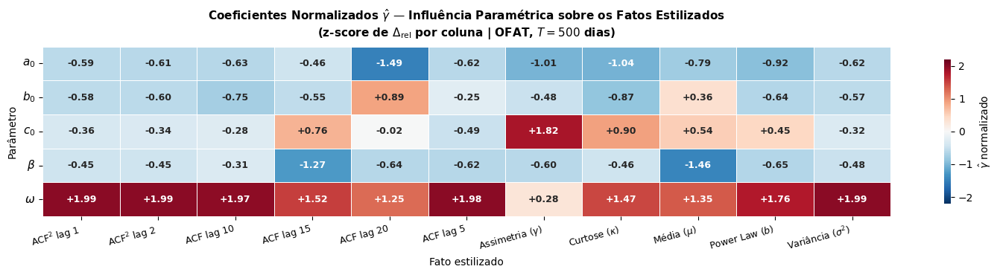

✓ Heatmap salvo: /content/drive/MyDrive/tese_fii/ofat_results2/figures/heatmap_gamma_hat.png


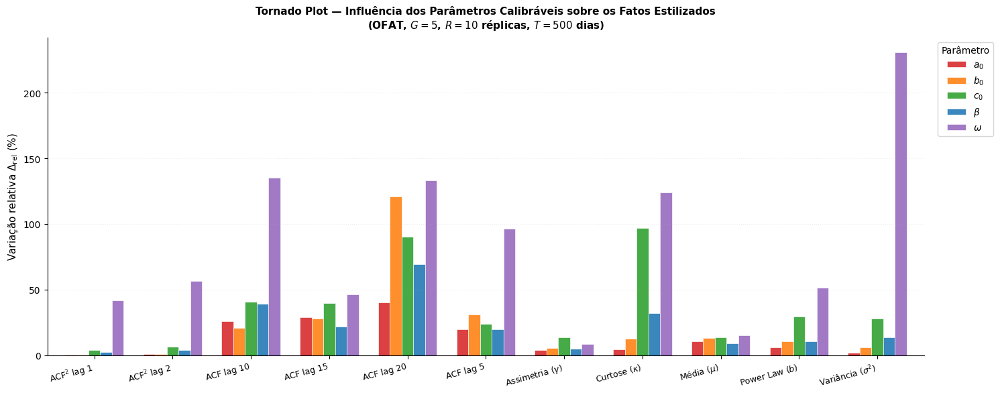

✓ Tornado plot salvo: /content/drive/MyDrive/tese_fii/ofat_results2/figures/tornado_plot_ofat.png


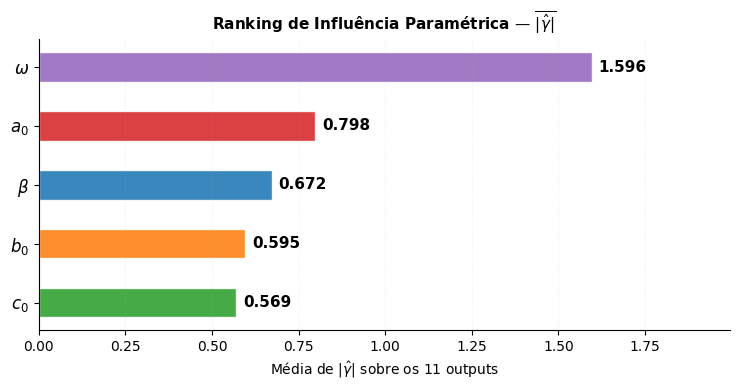

✓ Ranking salvo: /content/drive/MyDrive/tese_fii/ofat_results2/figures/ranking_parametros_ofat.png


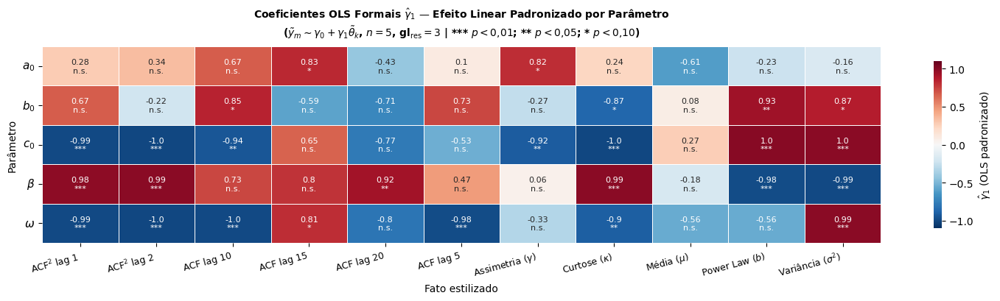

✓ OLS γ̂₁ salvo: /content/drive/MyDrive/tese_fii/ofat_results2/figures/ols_gamma1_significancia.png

✓ Todas as figuras geradas e salvas com sucesso.
  Diretório: /content/drive/MyDrive/tese_fii/ofat_results2/figures


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CÉLULA 1 — REGRESSÃO OLS FORMAL (dados brutos dos CSVs OFAT)
# Cole após a seção "Tornado Plot" no notebook
# Dependências: pivot já montado pela célula de PCA (linhas 3600-3650 do notebook)
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# ── Configuração ──────────────────────────────────────────────────────────────
OUT_DIR_OFAT = '/content/drive/MyDrive/tese_fii/ofat_results2'
FIG_DIR      = f'{OUT_DIR_OFAT}/figures'

PARAMS = ['a0', 'b0', 'c0', 'beta', 'peso']
LABELS_PARAMS = {
    'a0':   r'$a_0$',
    'b0':   r'$b_0$',
    'c0':   r'$c_0$',
    'beta': r'$\beta$',
    'peso': r'$\omega$',
}
CORES_PARAMS = {
    'a0':   '#d62728',
    'b0':   '#ff7f0e',
    'c0':   '#2ca02c',
    'beta': '#1f77b4',
    'peso': '#9467bd',
}
LABELS_OUTPUTS = {
    'media':       r'Média ($\mu$)',
    'variancia':   r'Variância ($\sigma^2$)',
    'assimetria':  r'Assimetria ($\gamma$)',
    'curtose':     r'Curtose ($\kappa$)',
    'acf_lag5':    'ACF lag 5',
    'acf_lag10':   'ACF lag 10',
    'acf_lag15':   'ACF lag 15',
    'acf_lag20':   'ACF lag 20',
    'acf2_lag1':   r'ACF$^2$ lag 1',
    'acf2_lag2':   r'ACF$^2$ lag 2',
    'power_law_b': 'Power Law ($b$)',
}

# ── Verificar se pivot já existe; se não, recarregar ──────────────────────────
if 'pivot' not in dir() or pivot is None:
    dfs = []
    for p in PARAMS:
        df = pd.read_csv(f'{OUT_DIR_OFAT}/ofat_{p}.csv')
        dfs.append(df)
    df_ofat = pd.concat(dfs, ignore_index=True)
    pivot = df_ofat.pivot_table(
        index=['param', 'value'],
        columns='output',
        values='mean'
    ).reset_index().dropna()
    print(f"pivot recarregado: {pivot.shape}")
else:
    print(f"pivot já disponível: {pivot.shape}")

output_cols = [c for c in pivot.columns if c not in ['param', 'value']]
print(f"Outputs: {output_cols}")

# ══════════════════════════════════════════════════════════════════════════════
# 1. REGRESSÃO OLS FORMAL — y_m ~ β₀ + β₁·θ_k  (variáveis padronizadas)
#    Para CADA parâmetro × CADA output: ajusta OLS com os 5 pontos da grade
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print("OLS FORMAL: ỹ_m ~ γ₀ + γ₁·θ̃_k  (padronizado × padronizado)")
print("n = 5 pontos por parâmetro | gl residuais = 3")
print("=" * 70)

resultados_ols = {}

for param in PARAMS:
    df_p  = pivot[pivot['param'] == param].copy()
    grade = df_p['value'].values           # 5 valores da grade

    # Padroniza a grade (variável independente)
    g_std = (grade - grade.mean()) / (grade.std() + 1e-12)
    X_ols = sm.add_constant(g_std)

    resultados_ols[param] = {}
    print(f"\n  ── {LABELS_PARAMS[param]} ({'β=' if param=='beta' else ''}{param}) ──")

    for out in output_cols:
        y_raw = df_p[out].values

        # Padroniza o output (variável dependente)
        y = (y_raw - y_raw.mean()) / (y_raw.std() + 1e-12)

        modelo = sm.OLS(y, X_ols).fit()
        gamma1 = modelo.params[1]      # coeficiente padronizado = correlação de Pearson
        pval   = modelo.pvalues[1]
        r2     = modelo.rsquared
        ci = modelo.conf_int()
        # conf_int() retorna ndarray (2,2): linhas=params, colunas=[lower,upper]
        # linha 0 = intercepto, linha 1 = γ₁
        ci_arr = np.array(ci)
        ic_low = float(ci_arr[1, 0])
        ic_up  = float(ci_arr[1, 1])

        sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else
              ('*' if pval < 0.10 else 'n.s.'))

        resultados_ols[param][out] = {
            'gamma1': gamma1, 'pval': pval, 'r2': r2,
            'ic_low': ic_low, 'ic_up': ic_up, 'sig': sig
        }
        print(f"    {out:15s}: γ̂₁={gamma1:+.4f}  "
              f"IC=[{ic_low:+.3f},{ic_up:+.3f}]  "
              f"p={pval:.4f} {sig:4s}  R²={r2:.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# 2. MATRIZ DE COEFICIENTES NORMALIZADOS γ̂  (z-score de Δ_rel por output)
# ══════════════════════════════════════════════════════════════════════════════

# Recalcula Δ_rel a partir do pivot e do baseline
baseline = pivot.groupby('param')[output_cols].mean()  # aproximação; usa média das grades
# Carrega baseline real (10 réplicas em θ*)
baseline_file = f'{OUT_DIR_OFAT}/ofat_a0.csv'   # baseline salvo em qualquer arquivo
try:
    df_base_raw = pd.read_csv(baseline_file)
    # O baseline está nas linhas onde param == 'baseline' ou value == theta_star
    # Depende do formato do CSV — tente as duas abordagens:
    if 'param' in df_base_raw.columns and 'baseline' in df_base_raw['param'].values:
        baseline_vals = df_base_raw[df_base_raw['param'] == 'baseline'][output_cols].mean()
    else:
        # Usa a média do baseline computada no notebook (hardcoded do output)
        baseline_vals = pd.Series({
            'media':       1.600e-4,
            'variancia':   1.300e-5,
            'assimetria':  0.516043,
            'curtose':     8.088465,
            'acf_lag5':    0.110780,
            'acf_lag10':   0.102715,
            'acf_lag15':  -0.072397,
            'acf_lag20':   0.032951,
            'acf2_lag1':   0.633324,
            'acf2_lag2':   0.429923,
            'power_law_b': 0.527387,
        })
    print(f"\nBaseline carregado.")
except Exception as e:
    print(f"Aviso baseline: {e} — usando valores hardcoded do notebook")
    baseline_vals = pd.Series({
        'media':       1.600e-4,
        'variancia':   1.300e-5,
        'assimetria':  0.516043,
        'curtose':     8.088465,
        'acf_lag5':    0.110780,
        'acf_lag10':   0.102715,
        'acf_lag15':  -0.072397,
        'acf_lag20':   0.032951,
        'acf2_lag1':   0.633324,
        'acf2_lag2':   0.429923,
        'power_law_b': 0.527387,
    })

# Calcula Δ_rel real para cada parâmetro
delta_rel_real = {}
for param in PARAMS:
    df_p = pivot[pivot['param'] == param]
    delta = {}
    for out in output_cols:
        y_vals = df_p[out].values
        base   = abs(baseline_vals[out]) + 1e-12
        delta[out] = (y_vals.max() - y_vals.min()) / base * 100
    delta_rel_real[param] = delta

df_delta = pd.DataFrame(delta_rel_real, index=output_cols).T   # params × outputs
print("\nMatriz Δ_rel (%) real:\n", df_delta.round(1).to_string())

# Normaliza por output (z-score por coluna)
arr = df_delta.values
X_norm = (arr - arr.mean(axis=0)) / (arr.std(axis=0) + 1e-9)
df_gamma = pd.DataFrame(X_norm, index=PARAMS, columns=output_cols)

print("\nCoeficientes normalizados γ̂ (z-score Δ_rel por output):")
print(df_gamma.round(3).to_string())

# Ranking por |γ̂| médio
ranking = df_gamma.abs().mean(axis=1).sort_values(ascending=False)
print("\nRanking por |γ̂| médio:")
for i, (p, v) in enumerate(ranking.items(), 1):
    print(f"  {i}. {p:5s}: {v:.4f}  (Δ_médio={df_delta.loc[p].mean():.1f}%)")

# Parâmetro dominante por output
print("\nParâmetro dominante por output (maior |γ̂|):")
abs_gamma = df_gamma.abs()
for out in output_cols:
    col   = abs_gamma[out].sort_values(ascending=False)
    p1,v1 = col.index[0], col.iloc[0]
    p2,v2 = col.index[1], col.iloc[1]
    print(f"  {out:15s}: 1º {p1:5s} |γ̂|={v1:.3f}   2º {p2:5s} |γ̂|={v2:.3f}")


# ══════════════════════════════════════════════════════════════════════════════
# CÉLULA 2 — FIGURAS: HEATMAP γ̂ + TORNADO PLOT + RANKING
# ══════════════════════════════════════════════════════════════════════════════

labels_p_plot  = [LABELS_PARAMS[p] for p in PARAMS]
labels_o_plot  = [LABELS_OUTPUTS.get(o, o) for o in output_cols]
cores_list     = [CORES_PARAMS[p] for p in PARAMS]

# ── Figura A: Heatmap dos coeficientes normalizados γ̂ ─────────────────────────
fig_A, ax_A = plt.subplots(figsize=(15, 3.8))

df_gamma_plot = pd.DataFrame(
    df_gamma.values,
    index=labels_p_plot,
    columns=labels_o_plot
)

sns.heatmap(
    df_gamma_plot,
    annot=True, fmt='+.2f', annot_kws={'size': 9, 'weight': 'bold'},
    cmap='RdBu_r', center=0, vmin=-2.2, vmax=2.2,
    linewidths=0.6, linecolor='white',
    ax=ax_A,
    cbar_kws={'label': r'$\hat{\gamma}$ normalizado', 'shrink': 0.85}
)
ax_A.set_title(
    r'Coeficientes Normalizados $\hat{\gamma}$ — Influência Paramétrica sobre os Fatos Estilizados'
    '\n' + r'(z-score de $\Delta_{\mathrm{rel}}$ por coluna | OFAT, $T=500$ dias)',
    fontsize=11, fontweight='bold', pad=10
)
ax_A.set_xlabel('Fato estilizado', fontsize=10)
ax_A.set_ylabel('Parâmetro', fontsize=10)
ax_A.tick_params(axis='y', rotation=0, labelsize=11)
ax_A.tick_params(axis='x', rotation=15, labelsize=9)
for label in ax_A.get_xticklabels():
    label.set_ha('right')

plt.tight_layout()
path_A = f'{FIG_DIR}/heatmap_gamma_hat.png'
fig_A.savefig(path_A, dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ Heatmap salvo: {path_A}")

# ── Figura B: Tornado Plot (Δ_rel absoluto) ───────────────────────────────────
fig_B, ax_B = plt.subplots(figsize=(15, 6))

x       = np.arange(len(output_cols))
n_p     = len(PARAMS)
width   = 0.15
offsets = np.linspace(-(n_p-1)/2, (n_p-1)/2, n_p) * width

for i, (param, lp, cor, offset) in enumerate(zip(PARAMS, labels_p_plot, cores_list, offsets)):
    vals = df_delta.loc[param, output_cols].values
    ax_B.bar(x + offset, vals, width, label=lp, color=cor,
             alpha=0.88, edgecolor='white', linewidth=0.5)

ax_B.set_xticks(x)
ax_B.set_xticklabels(labels_o_plot, fontsize=9, rotation=15, ha='right')
ax_B.set_ylabel(r'Variação relativa $\Delta_{\mathrm{rel}}$ (%)', fontsize=11)
ax_B.set_title(
    r'Tornado Plot — Influência dos Parâmetros Calibráveis sobre os Fatos Estilizados'
    '\n' + r'(OFAT, $G=5$, $R=10$ réplicas, $T=500$ dias)',
    fontsize=11, fontweight='bold', pad=10
)
ax_B.legend(title='Parâmetro', bbox_to_anchor=(1.01, 1), loc='upper left',
            fontsize=10, title_fontsize=10)
ax_B.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax_B.grid(axis='y', alpha=0.22, linestyle=':')
ax_B.set_xlim(-0.6, len(output_cols) - 0.4)
ax_B.spines['top'].set_visible(False)
ax_B.spines['right'].set_visible(False)

plt.tight_layout()
path_B = f'{FIG_DIR}/tornado_plot_ofat.png'
fig_B.savefig(path_B, dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ Tornado plot salvo: {path_B}")

# ── Figura C: Ranking por |γ̂| médio (barras horizontais) ─────────────────────
ranking_sort = df_gamma.abs().mean(axis=1).sort_values(ascending=True)  # crescente para barh

fig_C, ax_C = plt.subplots(figsize=(7.5, 4))

idx_sort      = [PARAMS.index(p) for p in ranking_sort.index]
cores_sorted  = [cores_list[i] for i in idx_sort]
labels_sorted = [labels_p_plot[i] for i in idx_sort]
vals_sorted   = ranking_sort.values

bars = ax_C.barh(labels_sorted, vals_sorted, color=cores_sorted,
                 alpha=0.88, edgecolor='white', height=0.5)

for bar, val in zip(bars, vals_sorted):
    ax_C.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
              f'{val:.3f}', va='center', fontsize=11, fontweight='bold')

ax_C.set_xlabel(r'Média de $|\hat{\gamma}|$ sobre os 11 outputs', fontsize=10)
ax_C.set_title(
    r'Ranking de Influência Paramétrica — $\overline{|\hat{\gamma}|}$',
    fontsize=11, fontweight='bold'
)
ax_C.set_xlim(0, vals_sorted.max() * 1.25)
ax_C.spines['top'].set_visible(False)
ax_C.spines['right'].set_visible(False)
ax_C.grid(axis='x', alpha=0.22, linestyle=':')
ax_C.tick_params(axis='y', labelsize=12)

plt.tight_layout()
path_C = f'{FIG_DIR}/ranking_parametros_ofat.png'
fig_C.savefig(path_C, dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ Ranking salvo: {path_C}")

# ── Figura D: OLS — γ̂₁ com IC 95% por output (heatmap de significância) ──────
# Monta matriz de γ₁ e matriz de p-valor para anotação
gamma1_mat = np.zeros((len(PARAMS), len(output_cols)))
pval_mat   = np.zeros((len(PARAMS), len(output_cols)))
sig_mat    = np.empty((len(PARAMS), len(output_cols)), dtype=object)

for i, param in enumerate(PARAMS):
    for j, out in enumerate(output_cols):
        r = resultados_ols[param][out]
        gamma1_mat[i, j] = r['gamma1']
        pval_mat[i, j]   = r['pval']
        sig_mat[i, j]    = r['sig']

df_gamma1 = pd.DataFrame(gamma1_mat, index=labels_p_plot, columns=labels_o_plot)
df_sig    = pd.DataFrame(sig_mat,    index=labels_p_plot, columns=labels_o_plot)

# Anotações: γ₁ + símbolo de significância
annot_mat = df_gamma1.round(2).astype(str) + '\n' + df_sig.values

fig_D, ax_D = plt.subplots(figsize=(15, 4.2))
sns.heatmap(
    df_gamma1,
    annot=annot_mat, fmt='', annot_kws={'size': 8},
    cmap='RdBu_r', center=0, vmin=-1.1, vmax=1.1,
    linewidths=0.6, linecolor='white',
    ax=ax_D,
    cbar_kws={'label': r'$\hat{\gamma}_1$ (OLS padronizado)', 'shrink': 0.85}
)
ax_D.set_title(
    r'Coeficientes OLS Formais $\hat{\gamma}_1$ — Efeito Linear Padronizado por Parâmetro'
    '\n' + r'($\tilde{y}_m \sim \gamma_0 + \gamma_1\tilde{\theta}_k$, '
    r'$n=5$, gl$_{\mathrm{res}}=3$ | *** $p<0{,}01$; ** $p<0{,}05$; * $p<0{,}10$)',
    fontsize=10, fontweight='bold', pad=10
)
ax_D.set_xlabel('Fato estilizado', fontsize=10)
ax_D.set_ylabel('Parâmetro', fontsize=10)
ax_D.tick_params(axis='y', rotation=0, labelsize=11)
ax_D.tick_params(axis='x', rotation=15, labelsize=9)
for label in ax_D.get_xticklabels():
    label.set_ha('right')

plt.tight_layout()
path_D = f'{FIG_DIR}/ols_gamma1_significancia.png'
fig_D.savefig(path_D, dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ OLS γ̂₁ salvo: {path_D}")

print("\n✓ Todas as figuras geradas e salvas com sucesso.")
print(f"  Diretório: {FIG_DIR}")

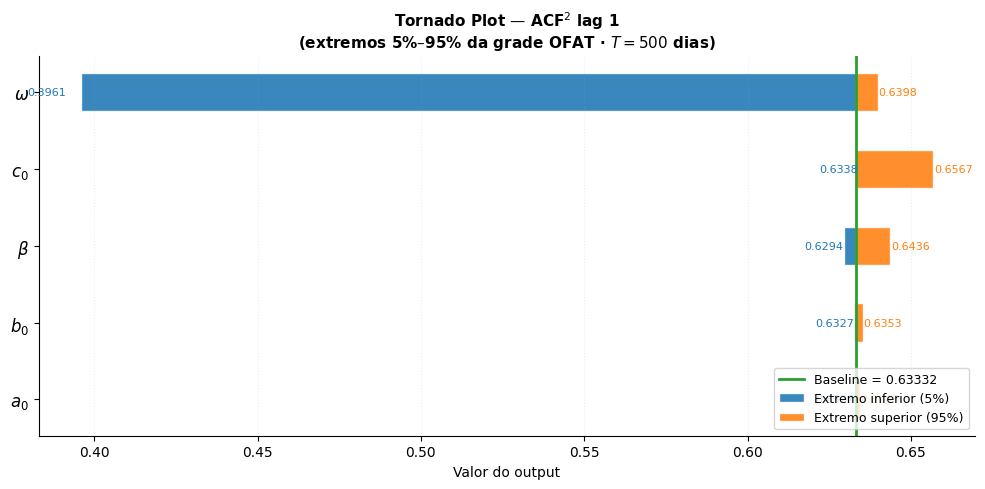

✓ acf2_lag1: /content/drive/MyDrive/tese_fii/ofat_results2/figures/tornado_acf2_lag1.png


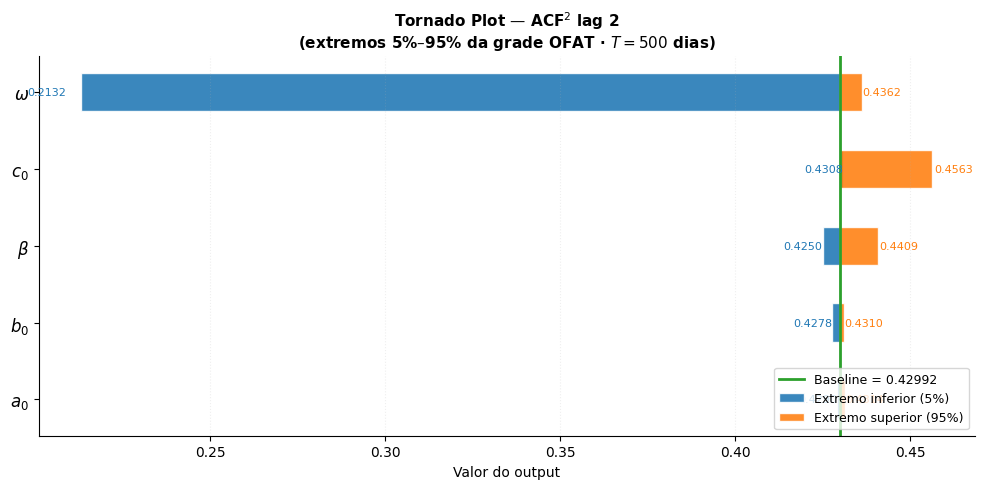

✓ acf2_lag2: /content/drive/MyDrive/tese_fii/ofat_results2/figures/tornado_acf2_lag2.png


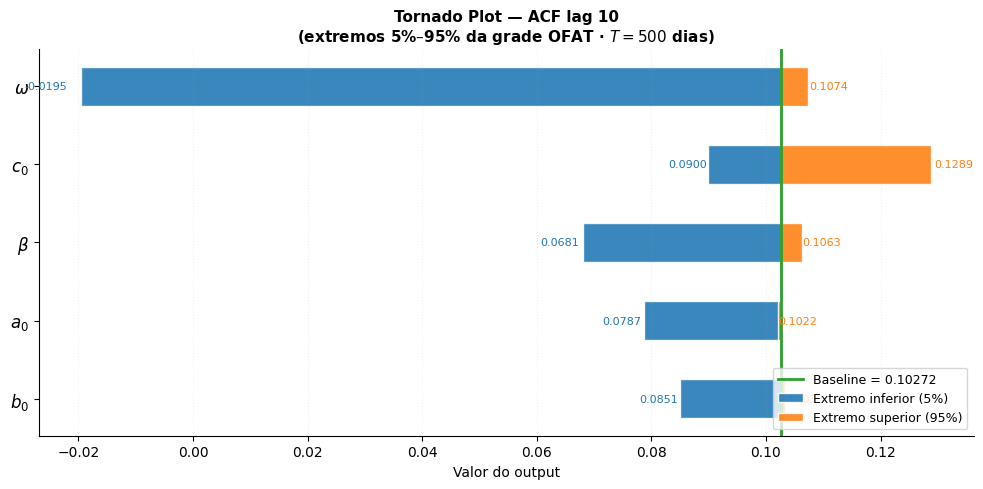

✓ acf_lag10: /content/drive/MyDrive/tese_fii/ofat_results2/figures/tornado_acf_lag10.png


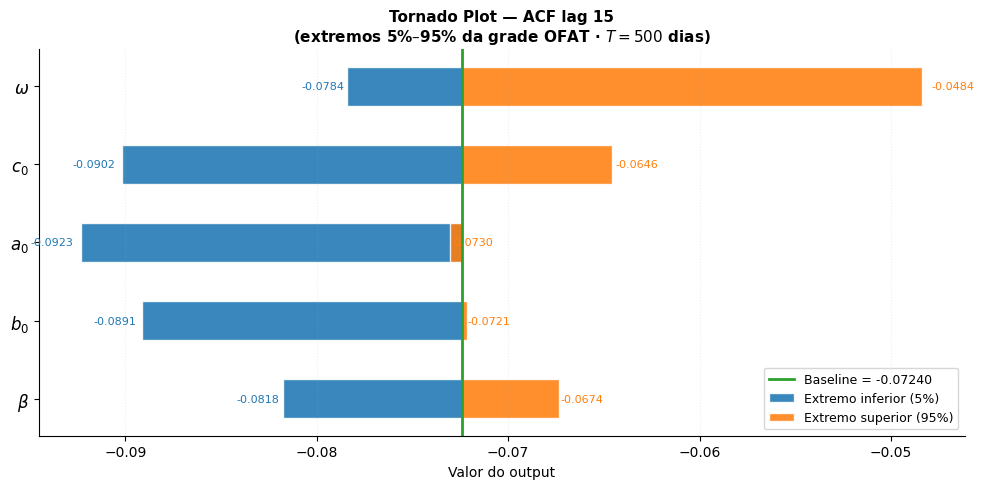

✓ acf_lag15: /content/drive/MyDrive/tese_fii/ofat_results2/figures/tornado_acf_lag15.png


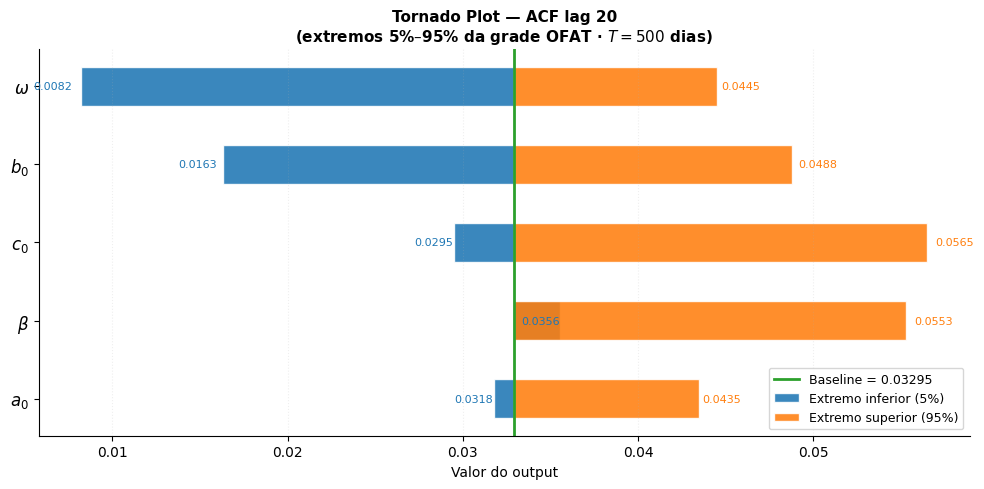

✓ acf_lag20: /content/drive/MyDrive/tese_fii/ofat_results2/figures/tornado_acf_lag20.png


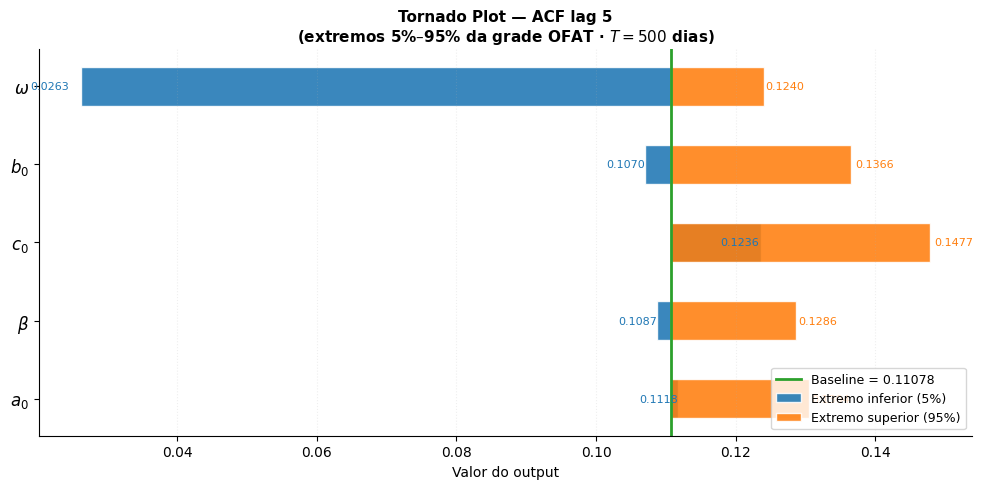

✓ acf_lag5: /content/drive/MyDrive/tese_fii/ofat_results2/figures/tornado_acf_lag5.png


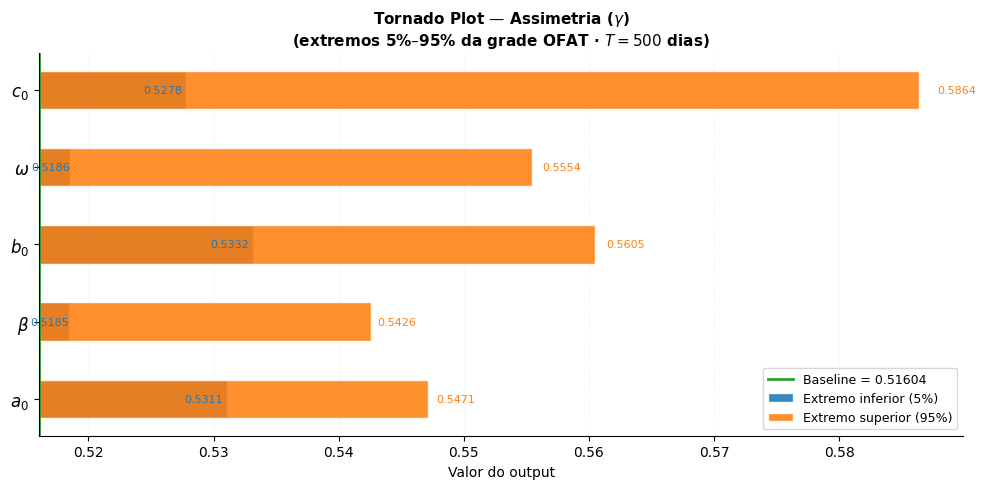

✓ assimetria: /content/drive/MyDrive/tese_fii/ofat_results2/figures/tornado_assimetria.png


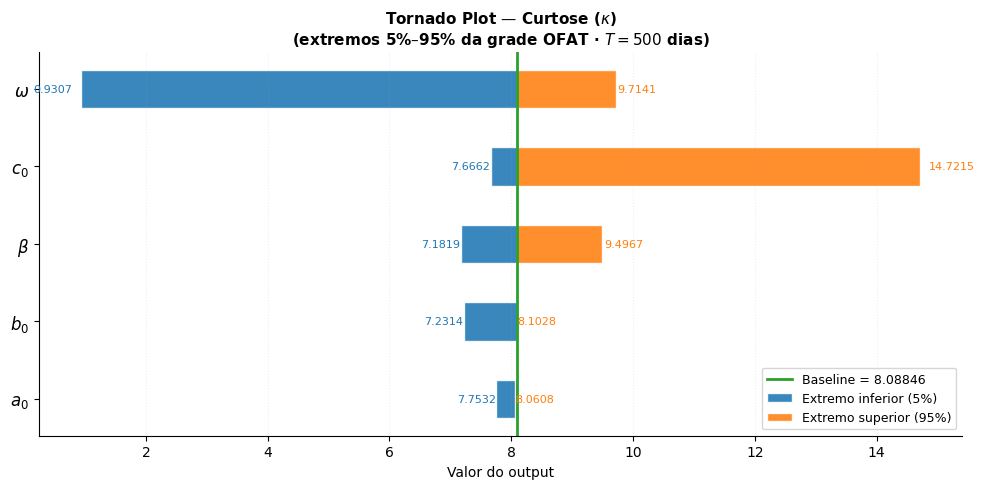

✓ curtose: /content/drive/MyDrive/tese_fii/ofat_results2/figures/tornado_curtose.png


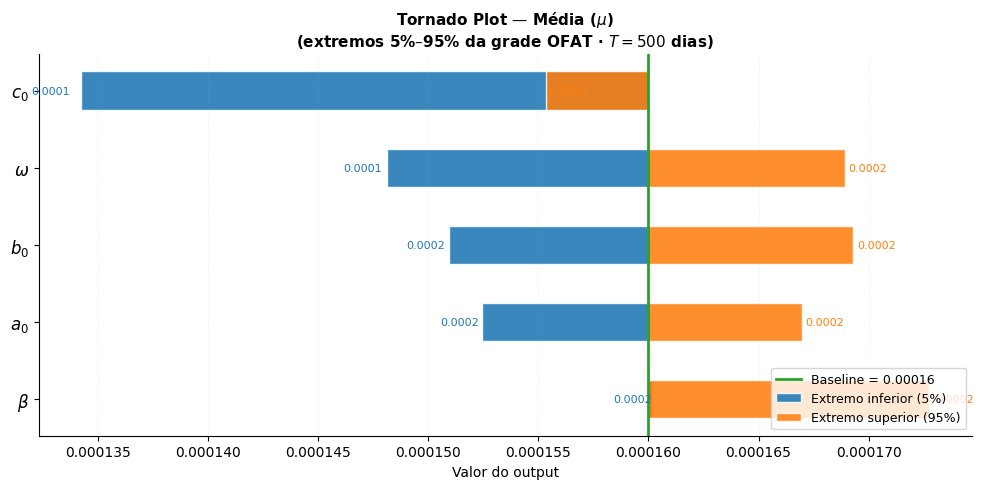

✓ media: /content/drive/MyDrive/tese_fii/ofat_results2/figures/tornado_media.png


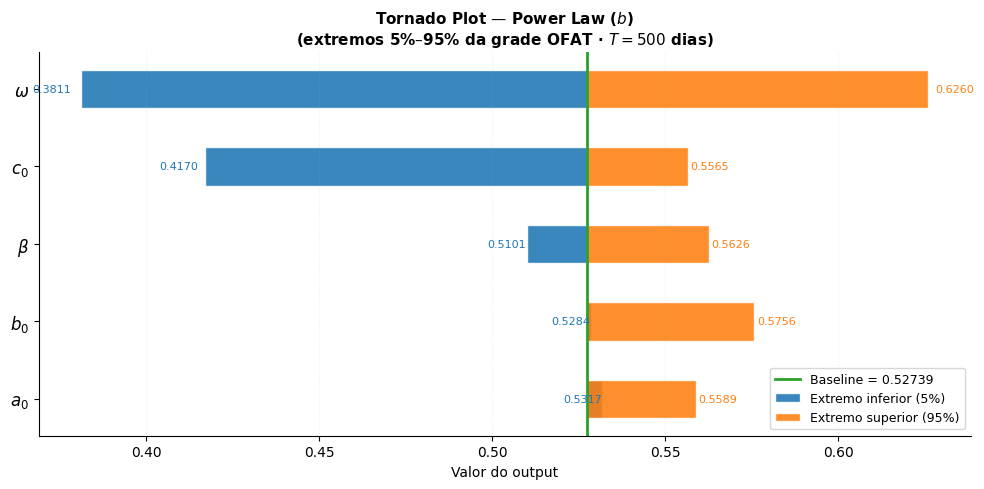

✓ power_law_b: /content/drive/MyDrive/tese_fii/ofat_results2/figures/tornado_power_law_b.png


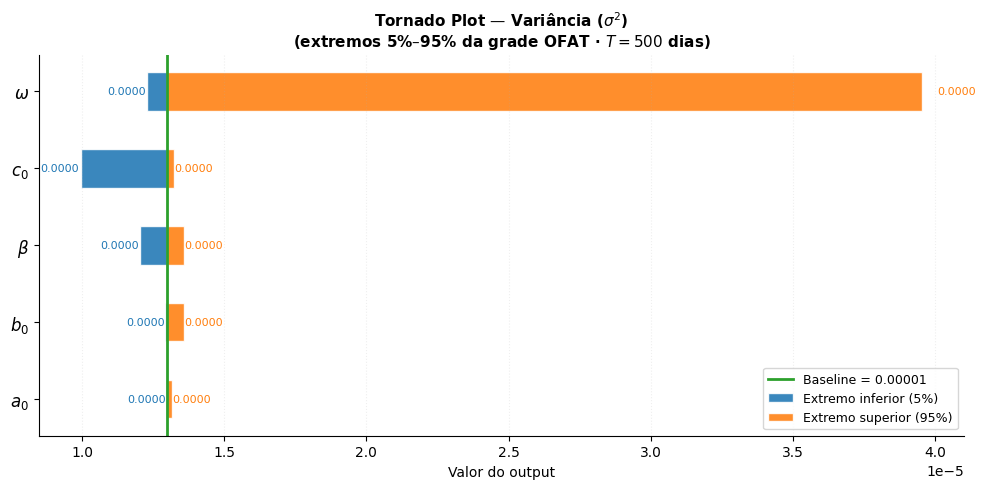

✓ variancia: /content/drive/MyDrive/tese_fii/ofat_results2/figures/tornado_variancia.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

PARAMS_LABELS = {
    'a0':   r'$a_0$',
    'b0':   r'$b_0$',
    'c0':   r'$c_0$',
    'beta': r'$\beta$',
    'peso': r'$\omega$',
}
CORES = {
    'min': '#1f77b4',  # azul — extremo inferior
    'max': '#ff7f0e',  # laranja — extremo superior
}

for out in output_cols:
    fig, ax = plt.subplots(figsize=(10, 5))

    # ── Coletar min, max e baseline por parâmetro ─────────────
    rows = []
    for param in PARAMS:
        df_p     = pivot[pivot['param'] == param].sort_values('value')
        y_vals   = df_p[out].values
        grade    = df_p['value'].values
        base     = float(baseline_vals[out])

        # percentil 5% e 95% da grade
        y_low  = np.percentile(y_vals, 5)
        y_high = np.percentile(y_vals, 95)
        spread = abs(y_high - y_low)

        rows.append({
            'param':  param,
            'label':  PARAMS_LABELS[param],
            'base':   base,
            'y_low':  y_low,
            'y_high': y_high,
            'spread': spread,
        })

    # Ordenar por spread (maior impacto no topo)
    rows = sorted(rows, key=lambda r: r['spread'])
    labels  = [r['label']  for r in rows]
    y_lows  = [r['y_low']  for r in rows]
    y_highs = [r['y_high'] for r in rows]
    base    = rows[0]['base']   # mesmo baseline para todos
    y_pos   = np.arange(len(rows))

    # ── Barras ────────────────────────────────────────────────
    for i, r in enumerate(rows):
        # Barra inferior (5%) — da baseline até y_low
        ax.barh(i,
                r['y_low'] - base,
                left=base,
                color=CORES['min'], alpha=0.88,
                edgecolor='white', height=0.5,
                label='Extremo inferior (5%)' if i == 0 else '')

        # Barra superior (95%) — da baseline até y_high
        ax.barh(i,
                r['y_high'] - base,
                left=base,
                color=CORES['max'], alpha=0.88,
                edgecolor='white', height=0.5,
                label='Extremo superior (95%)' if i == 0 else '')

    # ── Linha do baseline ─────────────────────────────────────
    ax.axvline(base, color='#2ca02c', lw=2, ls='-', label=f'Baseline = {base:.5f}')

    # ── Anotações dos valores ─────────────────────────────────
    for i, r in enumerate(rows):
        ax.text(r['y_low']  - (abs(r['y_low']  - base) * 0.02),
                i, f'{r["y_low"]:.4f}',
                va='center', ha='right', fontsize=8, color='#1f77b4')
        ax.text(r['y_high'] + (abs(r['y_high'] - base) * 0.02),
                i, f'{r["y_high"]:.4f}',
                va='center', ha='left',  fontsize=8, color='#ff7f0e')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=12)
    ax.set_xlabel('Valor do output', fontsize=10)
    ax.set_title(
        f'Tornado Plot — {LABELS_OUTPUTS.get(out, out)}\n'
        r'(extremos 5%–95% da grade OFAT · $T=500$ dias)',
        fontsize=11, fontweight='bold'
    )
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.2, axis='x', ls=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    path = f'{FIG_DIR}/tornado_{out}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'✓ {out}: {path}')

# Tornado Plot - Calibração

In [ ]:
df_dados_calib = pd.read_csv('/content/Mercado-Artificial-Fiis/notebooks/dados/resultados_simulacao_unido.csv')

# Rename columns as requested
df_dados_calib = df_dados_calib.rename(columns={
    'ACF_5': 'acf_5',
    'ACF_10': 'acf_10',
    'ACF_15': 'acf_15',
    'ACF_20': 'acf_20',
    'ACF_Q1': 'autocorr_q_1',
    'ACF_Q2': 'autocorr_q_2'
})
df_dados_calib

,a0,b0,c0,beta,p5,Media,Variancia,Assimetria,Curtose,acf_5,acf_10,acf_15,acf_20,autocorr_q_1,autocorr_q_2
0,0.553630,0.850862,0.573010,0.250316,0.087934,0.000213,0.000009,0.436351,3.135034,-0.014836,-0.025757,-0.011940,-0.105171,0.142293,0.040397
1,0.741465,0.626663,0.668682,0.169346,0.075521,0.000264,0.000010,0.424917,3.128460,-0.040401,-0.083395,-0.032399,-0.109880,0.160329,0.053586
2,0.801711,0.851868,0.622601,0.243649,0.115043,0.000699,0.000020,0.675101,3.678984,0.031251,-0.047076,-0.043555,-0.103337,0.327008,0.159299
3,0.510778,0.713842,0.619009,0.225052,0.142861,0.000501,0.000026,0.407583,3.113216,-0.009870,-0.020643,-0.015189,-0.121130,0.168484,0.003303
4,0.875631,0.835641,0.709651,0.233277,0.088969,0.000317,0.000016,0.560982,3.117600,0.013219,-0.147008,-0.018381,-0.017841,0.322854,0.158140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,0.651545,0.800906,0.563956,0.124970,0.072921,-0.000244,0.000008,-0.616570,6.778698,0.108405,-0.071190,-0.038023,-0.070121,0.164233,0.018881
596,0.773082,0.753727,0.514937,0.210096,0.090057,-0.000573,0.000010,-0.818496,7.763872,0.033525,0.037196,-0.125297,-0.039987,0.228667,0.072588
597,0.721629,0.567164,0.772159,0.208389,0.152422,-0.000619,0.000035,-0.897049,5.506555,0.026663,-0.034960,-0.104781,-0.075503,0.166539,0.007549
598,0.756639,0.828957,0.603335,0.259288,0.124443,-0.001015,0.000023,-1.005953,6.367668,0.012245,-0.053372,-0.035830,0.017717,0.322383,0.068232


In [ ]:
print(df_dados_calib.columns.tolist())
print(df_dados_calib.shape)
df_dados_calib.head(3)

['a0', 'b0', 'c0', 'beta', 'p5', 'Media', 'Variancia', 'Assimetria', 'Curtose', 'acf_5', 'acf_10', 'acf_15', 'acf_20', 'autocorr_q_1', 'autocorr_q_2']
(600, 15)


,a0,b0,c0,beta,p5,Media,Variancia,Assimetria,Curtose,acf_5,acf_10,acf_15,acf_20,autocorr_q_1,autocorr_q_2
0,0.553630,0.850862,0.573010,0.250316,0.087934,0.000213,0.000009,0.436351,3.135034,-0.014836,-0.025757,-0.011940,-0.105171,0.142293,0.040397
1,0.741465,0.626663,0.668682,0.169346,0.075521,0.000264,0.000010,0.424917,3.128460,-0.040401,-0.083395,-0.032399,-0.109880,0.160329,0.053586
2,0.801711,0.851868,0.622601,0.243649,0.115043,0.000699,0.000020,0.675101,3.678984,0.031251,-0.047076,-0.043555,-0.103337,0.327008,0.159299


                  R²        a0        b0        c0      beta        p5
Momento                                                               
Media         0.1021  0.000020  0.000005  0.000092 -0.000056 -0.000065
Variancia     0.8932 -0.000000  0.000001  0.000007 -0.000003  0.000013
Assimetria    0.0974  0.010379 -0.018555  0.054622 -0.029504 -0.110427
Curtose       0.1127 -0.018500 -0.048624 -0.119622  0.012831  0.333540
acf_5         0.1063  0.001117  0.011466 -0.004577 -0.001724 -0.010011
acf_10        0.0169 -0.000375 -0.005836 -0.001580 -0.000143  0.000131
acf_15        0.0232  0.001379 -0.005393 -0.003070  0.000309  0.002923
acf_20        0.0524 -0.001157 -0.004229  0.003560  0.005342  0.005818
autocorr_q_1  0.2145 -0.001196  0.030914  0.012096  0.001320 -0.005868
autocorr_q_2  0.1198  0.002709  0.016626  0.007800 -0.000710 -0.002456


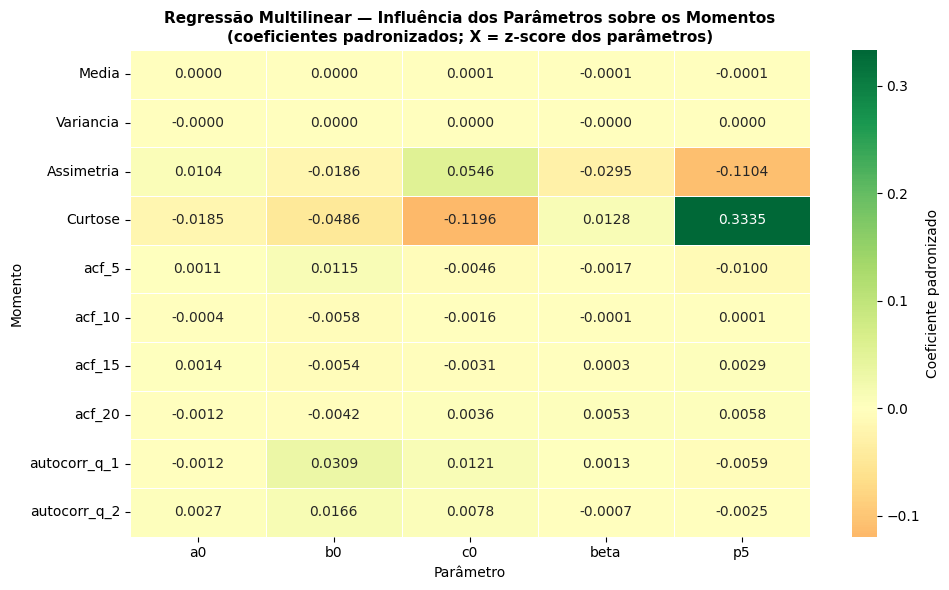

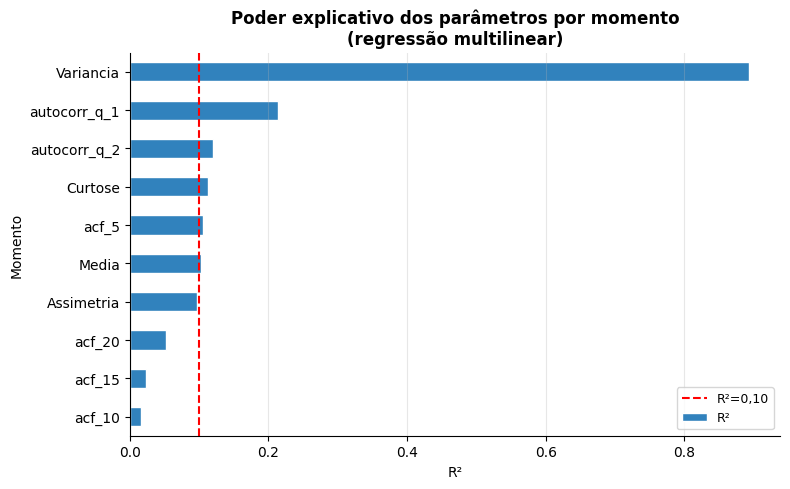

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# ── Variáveis ─────────────────────────────────────────────────
PARAMS   = ['a0', 'b0', 'c0', 'beta', 'p5']
MOMENTOS = ['Media', 'Variancia', 'Assimetria', 'Curtose',
            'acf_5', 'acf_10', 'acf_15', 'acf_20',
            'autocorr_q_1', 'autocorr_q_2']

X = df_dados_calib[PARAMS].values
y_all = df_dados_calib[MOMENTOS]

# ── Padronizar X (z-score) ────────────────────────────────────
scaler = StandardScaler()
X_std  = scaler.fit_transform(X)

# ── 10 regressões ─────────────────────────────────────────────
resultados = []

for momento in MOMENTOS:
    y   = df_dados_calib[momento].values
    reg = LinearRegression().fit(X_std, y)
    r2  = r2_score(y, reg.predict(X_std))

    row = {'Momento': momento, 'R²': round(r2, 4)}
    for param, coef in zip(PARAMS, reg.coef_):
        row[param] = round(coef, 6)
    resultados.append(row)

df_reg = pd.DataFrame(resultados).set_index('Momento')
print(df_reg.to_string())

# ── Heatmap dos coeficientes padronizados ─────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
coefs   = df_reg[PARAMS]

sns.heatmap(coefs, annot=True, fmt='.4f', cmap='RdYlGn',
            center=0, linewidths=0.5,
            cbar_kws={'label': 'Coeficiente padronizado'},
            ax=ax)
ax.set_title('Regressão Multilinear — Influência dos Parâmetros sobre os Momentos\n'
             '(coeficientes padronizados; X = z-score dos parâmetros)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Parâmetro', fontsize=10)
ax.set_ylabel('Momento', fontsize=10)
plt.tight_layout()
plt.show()

# ── R² por momento ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
df_reg['R²'].sort_values().plot.barh(ax=ax, color='#3182bd', edgecolor='white')
ax.axvline(0.1, color='red', lw=1.5, ls='--', label='R²=0,10')
ax.set_xlabel('R²')
ax.set_title('Poder explicativo dos parâmetros por momento\n(regressão multilinear)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

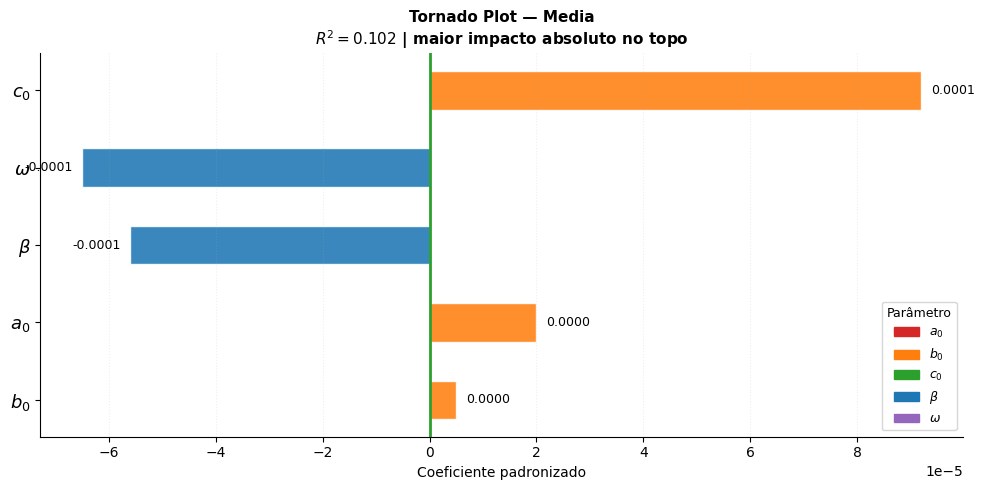

✓ Media


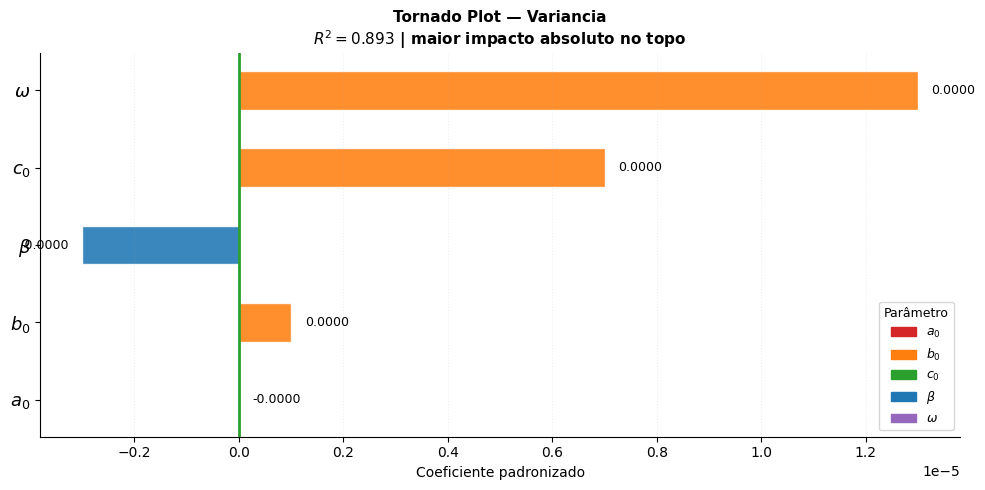

✓ Variancia


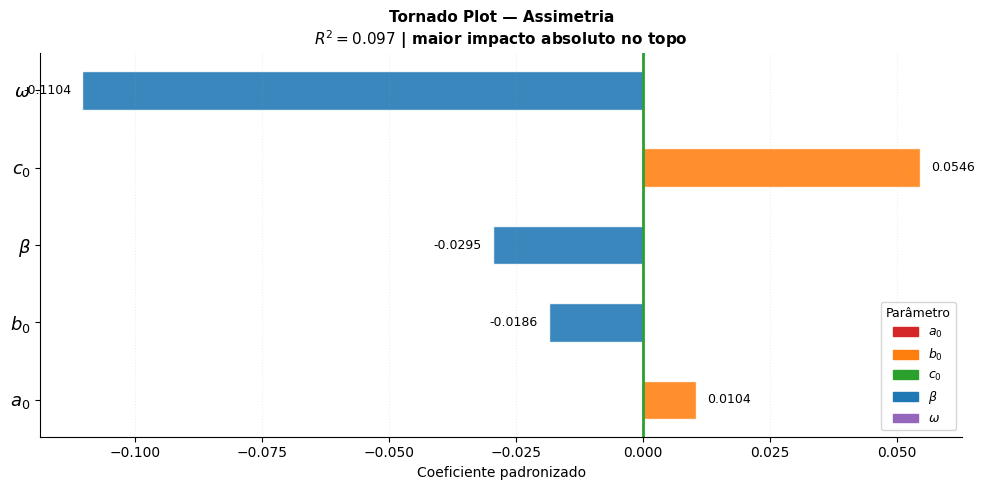

✓ Assimetria


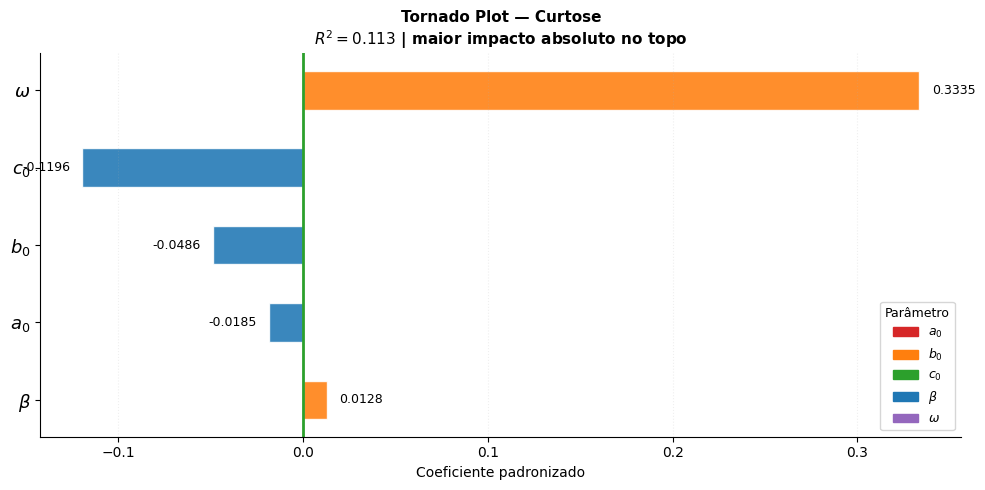

✓ Curtose


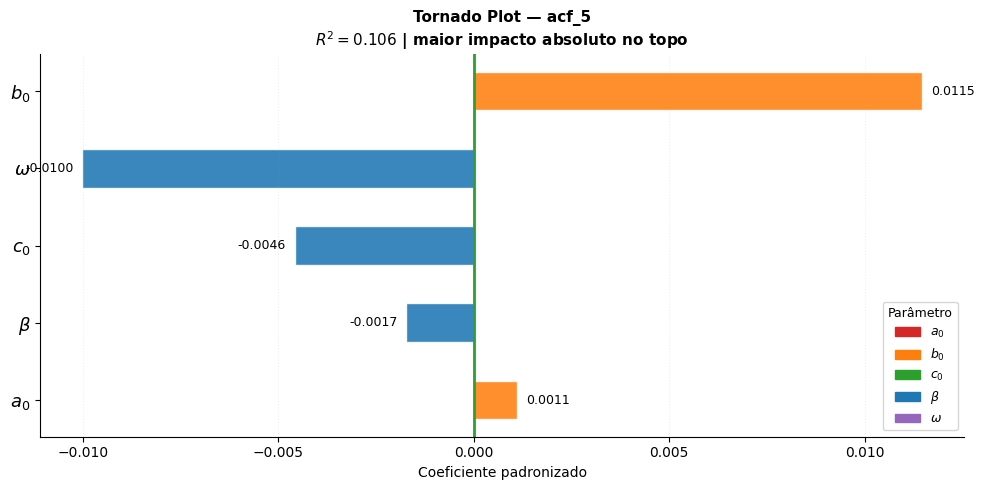

✓ acf_5


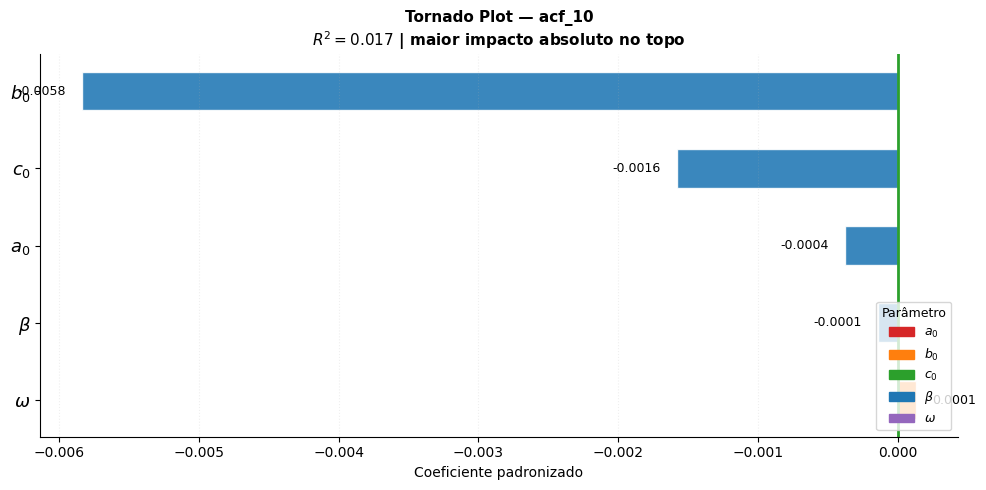

✓ acf_10


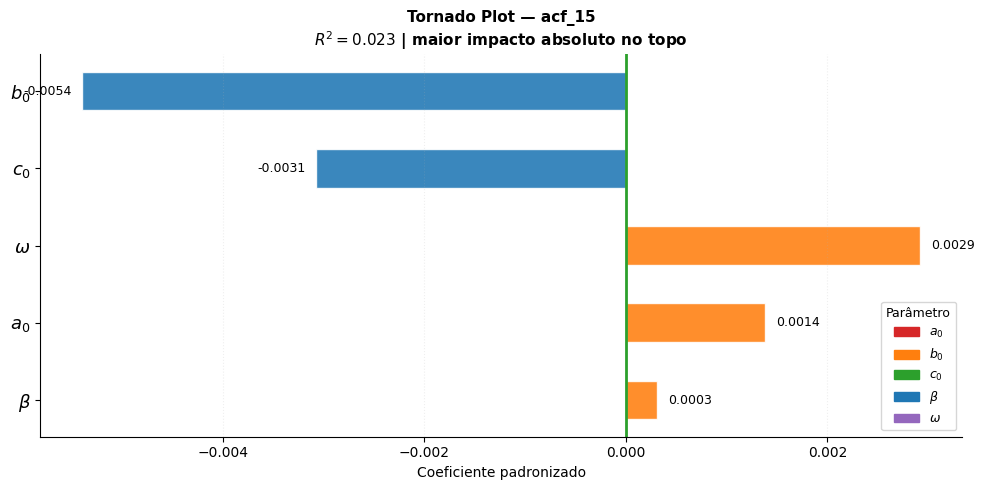

✓ acf_15


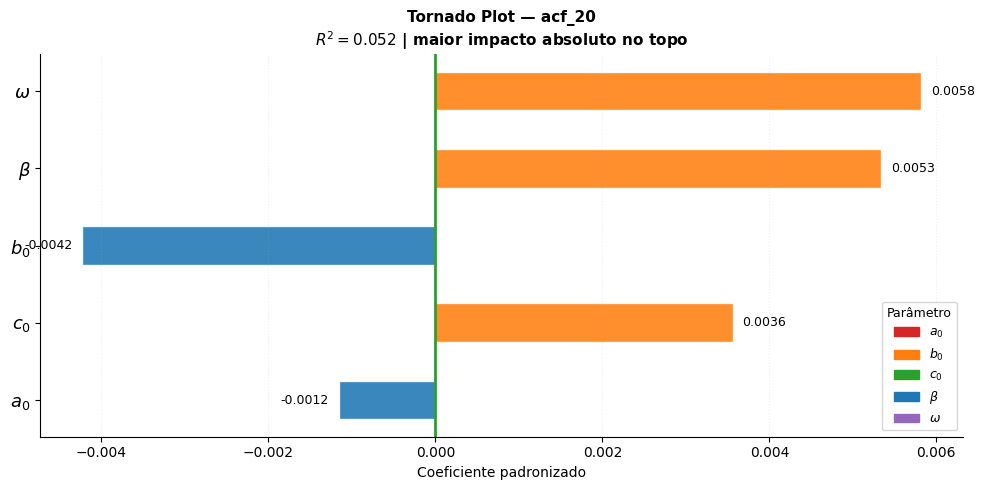

✓ acf_20


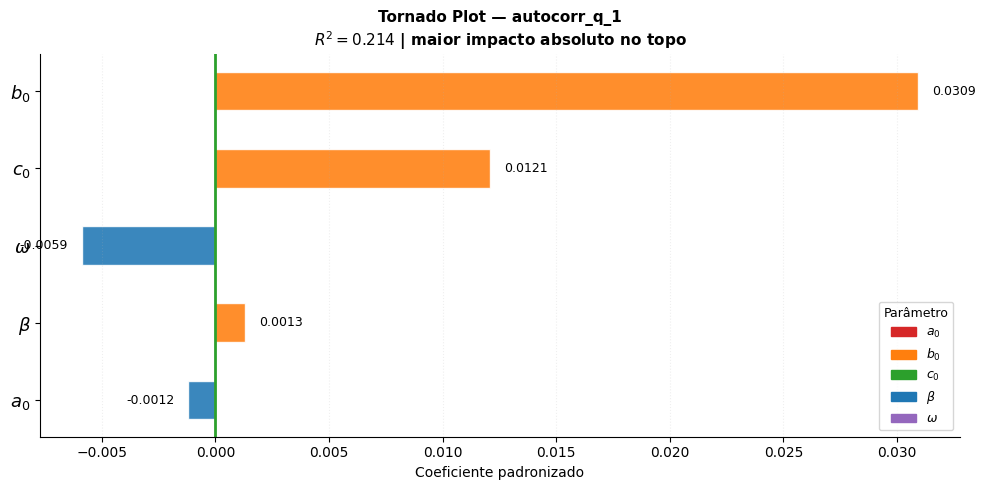

✓ autocorr_q_1


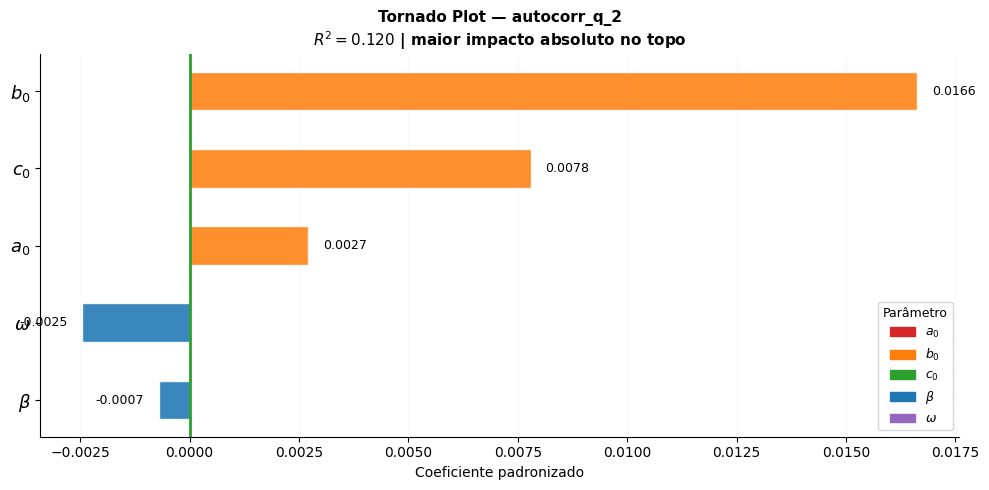

✓ autocorr_q_2


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

CORES = {
    'a0':   '#d62728',
    'b0':   '#ff7f0e',
    'c0':   '#2ca02c',
    'beta': '#1f77b4',
    'p5':   '#9467bd',
}

PARAMS_LABELS_REG = {
    'a0':   r'$a_0$',
    'b0':   r'$b_0$',
    'c0':   r'$c_0$',
    'beta': r'$\beta$',
    'p5':   r'$\omega$',
}

for momento in MOMENTOS:
    fig, ax = plt.subplots(figsize=(10, 5))

    row = df_reg.loc[momento, PARAMS]

    # Ordenar por valor absoluto (maior impacto no topo)
    row_sorted = row.reindex(row.abs().sort_values(ascending=True).index)

    cores  = [CORES[p] for p in row_sorted.index]
    vals   = row_sorted.values
    labels = [PARAMS_LABELS_REG[p] for p in row_sorted.index]
    y_pos  = np.arange(len(labels))

    # Barras — azul para negativo, laranja para positivo
    bar_cores = ['#1f77b4' if v < 0 else '#ff7f0e' for v in vals]
    bars = ax.barh(y_pos, vals, color=bar_cores,
                   edgecolor='white', height=0.5, alpha=0.88)

    # Linha do baseline (zero)
    ax.axvline(0, color='#2ca02c', lw=2, ls='-', label='Baseline = 0')

    # Anotações dos valores
    for bar, val in zip(bars, vals):
        ha  = 'left'  if val >= 0 else 'right'
        off = abs(vals).max() * 0.02
        off = off if val >= 0 else -off
        ax.text(val + off, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', ha=ha, fontsize=9)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=13)
    ax.set_xlabel('Coeficiente padronizado', fontsize=10)
    ax.set_title(
        f'Tornado Plot — {momento}\n'
        f'$R^2={df_reg.loc[momento, "R²"]:.3f}$ | maior impacto absoluto no topo',
        fontsize=11, fontweight='bold'
    )

    # Legenda: cores dos parâmetros
    handles = [plt.Rectangle((0, 0), 1, 1, color=CORES[p]) for p in PARAMS]
    labels_leg = [PARAMS_LABELS_REG[p] for p in PARAMS]
    ax.legend(handles, labels_leg, title='Parâmetro',
              fontsize=9, title_fontsize=9,
              loc='lower right')

    ax.grid(True, alpha=0.2, axis='x', ls=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'tornado_{momento}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'✓ {momento}')